# Smart Irrigation Scheduling in Kiwifruit cv. Allison
## Complete Colab Research Pipeline — Updated Version

This notebook follows the thesis workflow:

**Kiwifruit cv. Allison → soil-moisture monitoring → irrigation treatments → phenological stages → physiological/agronomic data + leaf images → multimodal fusion → feature selection → ML/DL stress classification → SHAP/XAI → counterfactual explanation → sensitive-stage identification → smart irrigation decision support.**

### Important methodological rule
The primary agricultural analysis uses the experimental treatment structure. Machine learning is an additional predictive/XAI analysis. The notebook does **not** silently invent disease labels. If an experimentally validated water-stress class exists, it is used. Otherwise, a clearly labelled treatment-derived proxy is created for exploratory modelling.


In [1]:
# CELL 1 — FIX COLAB NUMPY / SCIPY / SHAP ENVIRONMENT

!pip uninstall -y numpy pandas scipy scikit-learn shap xgboost statsmodels matplotlib
!pip install --no-cache-dir --force-reinstall \
    numpy==2.2.3 \
    pandas==2.2.3 \
    scipy==1.15.2 \
    scikit-learn==1.6.1 \
    matplotlib==3.10.1 \
    xgboost==2.1.4 \
    shap==0.47.2 \
    statsmodels==0.14.4 \
    openpyxl==3.1.5 \
    joblib==1.4.2 \
    Pillow==11.1.0 \
    scikit-image==0.25.2

Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3
Found existing installation: pandas 2.2.3
Uninstalling pandas-2.2.3:
  Successfully uninstalled pandas-2.2.3
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: shap 0.52.0
Uninstalling shap-0.52.0:
  Successfully uninstalled shap-0.52.0
Found existing installation: xgboost 3.4.1
Uninstalling xgboost-3.4.1:
  Successfully uninstalled xgboost-3.4.1
Found existing installation: statsmodels 0.14.6
Uninstalling statsmodels-0.14.6:
  Successfully uninstalled statsmodels-0.14.6
Found existing installation: matplotlib 3.10.0
Uninstalling matplotlib-3.10.0:
  Successfully uninstalled matplotlib-3.10.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 57.4 MB/s eta 0:00:00

In [1]:
# ============================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# ============================================================

import os
import re
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import shap

from google.colab import files

# ------------------------------------------------------------
# Scikit-learn
# ------------------------------------------------------------

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.feature_selection import (
    mutual_info_classif
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import (
    SVC
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.neural_network import (
    MLPClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

from xgboost import (
    XGBClassifier
)

# ------------------------------------------------------------
# Statistical analysis
# ------------------------------------------------------------

import statsmodels.formula.api as smf

from statsmodels.stats.anova import (
    anova_lm
)

# ------------------------------------------------------------
# Warnings
# ------------------------------------------------------------

warnings.filterwarnings(
    "ignore"
)

# ------------------------------------------------------------
# Random state
# ------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "kiwifruit_research_outputs"
)

OUTPUT_DIR.mkdir(
    exist_ok=True
)

# ------------------------------------------------------------
# Matplotlib
# ------------------------------------------------------------

plt.rcParams[
    "font.family"
] = "DejaVu Sans"

plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 400

# ============================================================
# VERSION CHECK
# ============================================================

print("=" * 80)
print("KIWIFRUIT MULTIMODAL ML + XAI")
print("=" * 80)

print(
    "NumPy       :",
    np.__version__
)

print(
    "Pandas      :",
    pd.__version__
)

print(
    "SciPy       :",
    __import__("scipy").__version__
)

print(
    "Scikit-learn:",
    __import__("sklearn").__version__
)

print(
    "XGBoost     :",
    __import__("xgboost").__version__
)

print(
    "SHAP        :",
    shap.__version__
)

print("=" * 80)
print("Environment ready.")
print("=" * 80)

KIWIFRUIT MULTIMODAL ML + XAI
NumPy       : 2.2.3
Pandas      : 2.2.3
SciPy       : 1.15.2
Scikit-learn: 1.6.1
XGBoost     : 2.1.4
SHAP        : 0.47.2
Environment ready.


In [2]:
# ============================================================
# CELL 3 — UPLOAD TWO EXCEL WORKBOOKS
# ============================================================

print("Please upload BOTH Excel workbooks containing the kiwifruit experimental data.")
print("Select both files together in the upload window.")

uploaded = files.upload()

# ------------------------------------------------------------
# Check number of files
# ------------------------------------------------------------

excel_files = [
    name for name in uploaded.keys()
    if name.lower().endswith((".xlsx", ".xls"))
]

print("\nUploaded Excel files:")
for i, name in enumerate(excel_files, 1):
    print(f"{i}. {name}")

if len(excel_files) < 2:
    raise ValueError(
        "Please upload BOTH Excel files. "
        "You currently uploaded fewer than two Excel workbooks."
    )

# ------------------------------------------------------------
# Assign the two workbooks
# ------------------------------------------------------------

file1 = excel_files[0]
file2 = excel_files[1]

print("\nWorkbook 1:", file1)
print("Workbook 2:", file2)

# ------------------------------------------------------------
# Read Excel workbook information
# ------------------------------------------------------------

xls1 = pd.ExcelFile(file1)
xls2 = pd.ExcelFile(file2)

print("\n" + "=" * 80)
print("WORKBOOK 1 — AVAILABLE SHEETS")
print("=" * 80)

for i, sheet in enumerate(xls1.sheet_names):
    print(f"{i}: {sheet}")

print("\n" + "=" * 80)
print("WORKBOOK 2 — AVAILABLE SHEETS")
print("=" * 80)

for i, sheet in enumerate(xls2.sheet_names):
    print(f"{i}: {sheet}")

Please upload BOTH Excel workbooks containing the kiwifruit experimental data.
Select both files together in the upload window.


Saving Lakshay's Data Fruit Science.xlsx to Lakshay's Data Fruit Science.xlsx
Saving Lakshay Edited Data NEW.xlsx to Lakshay Edited Data NEW.xlsx

Uploaded Excel files:
1. Lakshay's Data Fruit Science.xlsx
2. Lakshay Edited Data NEW.xlsx

Workbook 1: Lakshay's Data Fruit Science.xlsx
Workbook 2: Lakshay Edited Data NEW.xlsx

WORKBOOK 1 — AVAILABLE SHEETS
0: Fruit weight
1: Fruit Length
2: Fruit Diameter
3: Fruit Firmness
4: Fruit Volume
5: Fruit TSS
6: Titrable Acidity
7: Total Sugars
8: Reduicing Sugars
9: Non-Reducing Sugars
10: Tss-Acid ratio
11: Ascorbic Acid
12: Relative Water Content
13: Leaf Yellowing
14: Yield
15: No of Fruits per vine
16: Yield Efficency
17: Trunk Girth
18: TCSA
19: Malondialdehyde (MDA)
20: Proline
21: Nitrogen (Leaf)
22: Phosphorous
23: Potassium
24: Calcium
25: Magnesium
26: Nitrogen(Fruit)
27: Phosphorous(Fruit)
28: Potassium(Fruit)
29: Calcium(Fruit)
30: Magnesium(Fruit)
31: Bloom Intensity
32: Leaf Area
33: Canopy Temprature
34: Chlorophyll Content 
35: 

In [5]:
# ============================================================
# CELL 4 — AUTOMATIC SHEET SELECTION FOR BOTH WORKBOOKS
# ============================================================

def clean_columns(data):
    data = data.copy()

    data.columns = [
        str(c).strip()
        .replace("\n", " ")
        .replace("\t", " ")
        for c in data.columns
    ]

    return data


def normalize_name(value):

    x = str(value).strip().lower()

    x = re.sub(
        r"[%()/\-]+",
        "_",
        x
    )

    x = re.sub(
        r"\s+",
        "_",
        x
    )

    x = re.sub(
        r"_+",
        "_",
        x
    )

    return x.strip("_")


def score_sheet(data):

    score = 0

    # --------------------------------------------------------
    # Dataset size
    # --------------------------------------------------------

    if len(data) >= 10:
        score += 3

    if data.shape[1] >= 8:
        score += 3

    # --------------------------------------------------------
    # Research-related keywords
    # --------------------------------------------------------

    keywords = [
        "irrigation",
        "stage",
        "phenological",
        "replication",
        "replicate",
        "vine",
        "plant",
        "canopy",
        "temperature",
        "spad",
        "rwc",
        "relative_water",
        "ndvi",
        "yellowing",
        "par",
        "proline",
        "mda",
        "fruit",
        "tss",
        "yield",
        "stress",
        "class",
        "chlorophyll",
        "leaf",
        "water",
        "moisture",
        "growth"
    ]

    for col in data.columns:

        name = normalize_name(col)

        for key in keywords:

            if key in name:
                score += 2

    return score


# ============================================================
# FUNCTION TO SELECT BEST SHEET
# ============================================================

def select_best_sheet(filename):

    xls = pd.ExcelFile(filename)

    sheet_scores = []

    for sheet in xls.sheet_names:

        try:

            temp = pd.read_excel(
                filename,
                sheet_name=sheet
            )

            temp = clean_columns(temp)

            sheet_scores.append({
                "Sheet": sheet,
                "Rows": temp.shape[0],
                "Columns": temp.shape[1],
                "Score": score_sheet(temp)
            })

        except Exception as e:

            print(
                f"Could not read sheet '{sheet}': {e}"
            )


    # --------------------------------------------------------
    # Create ranking table
    # --------------------------------------------------------

    sheet_scores_df = (
        pd.DataFrame(sheet_scores)
        .sort_values(
            "Score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return sheet_scores_df


# ============================================================
# WORKBOOK 1
# ============================================================

print("=" * 90)
print("WORKBOOK 1 — AUTOMATIC SHEET SELECTION")
print("=" * 90)

print(
    "File:",
    file1
)

sheet_scores_1 = select_best_sheet(
    file1
)

display(
    sheet_scores_1
)


# Select highest-scoring sheet
selected_sheet_1 = (
    sheet_scores_1.iloc[0]["Sheet"]
)

print(
    "\nAutomatically selected sheet:",
    selected_sheet_1
)


# Load Dataset 1
df1 = clean_columns(
    pd.read_excel(
        file1,
        sheet_name=selected_sheet_1
    )
)


print(
    "Dataset 1 shape:",
    df1.shape
)

display(
    df1.head(10)
)


# ============================================================
# WORKBOOK 2
# ============================================================

print("\n" + "=" * 90)
print("WORKBOOK 2 — AUTOMATIC SHEET SELECTION")
print("=" * 90)

print(
    "File:",
    file2
)

sheet_scores_2 = select_best_sheet(
    file2
)

display(
    sheet_scores_2
)


# Select highest-scoring sheet
selected_sheet_2 = (
    sheet_scores_2.iloc[0]["Sheet"]
)

print(
    "\nAutomatically selected sheet:",
    selected_sheet_2
)


# Load Dataset 2
df2 = clean_columns(
    pd.read_excel(
        file2,
        sheet_name=selected_sheet_2
    )
)


print(
    "Dataset 2 shape:",
    df2.shape
)

display(
    df2.head(10)
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("CELL 4 COMPLETED")
print("=" * 90)

print(
    "\nWorkbook 1:"
)

print(
    "  File  :",
    file1
)

print(
    "  Sheet :",
    selected_sheet_1
)

print(
    "  Shape :",
    df1.shape
)


print(
    "\nWorkbook 2:"
)

print(
    "  File  :",
    file2
)

print(
    "  Sheet :",
    selected_sheet_2
)

print(
    "  Shape :",
    df2.shape
)

WORKBOOK 1 — AUTOMATIC SHEET SELECTION
File: Lakshay's Data Fruit Science.xlsx


,Sheet,Rows,Columns,Score
0,Canopy Temprature,130,23,12
1,Leaf Area,60,24,12
2,Chlorophyll Content,130,23,12
3,PAR,130,24,12
4,NDVI,130,22,12
5,Fruit weight,36,11,8
6,Fruit Length,36,9,8
7,Fruit Diameter,36,9,6
8,Fruit Firmness,39,13,6
9,Fruit Volume,39,13,6



Automatically selected sheet: Canopy Temprature
Dataset 1 shape: (130, 23)


,Unnamed: 0,Main,Sub,Interval,Replication,Unnamed: 5,Unnamed: 6,Main.1,Sub.1,Intervals,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Stage 4,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,3.0,...,Sub,Interval,Replication,NaN,NaN,Main,Sub,Interval,Replication,NaN
1,NaN,I2,S1,1.0,1.0,34.5,NaN,I2,S2,3.0,...,S3,1,1,38.2,NaN,I1,S4,9,1,39.4
2,NaN,I3,S1,1.0,1.0,36.7,NaN,I3,S2,3.0,...,S3,1,1,36.8,NaN,I2,S4,9,1,41.2
3,NaN,I1,S1,1.0,2.0,31.4,NaN,I1,S2,3.0,...,S3,1,1,35.4,NaN,I3,S4,9,1,45.1
4,NaN,I2,S1,1.0,2.0,33.5,NaN,I2,S2,3.0,...,S3,1,2,37.3,NaN,I1,S4,9,2,40.7
5,NaN,I3,S1,1.0,2.0,36.7,NaN,I3,S2,3.0,...,S3,1,2,36.2,NaN,I2,S4,9,2,41.9
6,NaN,I1,S1,1.0,3.0,32.8,NaN,I1,S2,3.0,...,S3,1,2,36.7,NaN,I3,S4,9,2,43.8
7,NaN,I2,S1,1.0,3.0,34.7,NaN,I2,S2,3.0,...,S3,1,3,37.0,NaN,I1,S4,9,3,40.1
8,NaN,I3,S1,1.0,3.0,35.9,NaN,I3,S2,3.0,...,S3,1,3,35.9,NaN,I2,S4,9,3,42.8
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S3,1,3,35.3,NaN,I3,S4,9,3,45.0



WORKBOOK 2 — AUTOMATIC SHEET SELECTION
File: Lakshay Edited Data NEW.xlsx


,Sheet,Rows,Columns,Score
0,Fruit Weight,39,13,6
1,Fruit Length,39,13,6
2,Fruit Diameter,39,13,6
3,Fruit Shape L D Ratio,36,9,6
4,Yield,39,13,6
5,No Of fruits per Vine,39,13,6
6,TCSA,39,13,6
7,Trunk Girth,39,13,6
8,Yield Efficency,39,13,6
9,Fruit Volume,37,9,6



Automatically selected sheet: Fruit Weight
Dataset 2 shape: (39, 13)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Main,Sub,Rep,Unnamed: 8,Unnamed: 9,Treat,Rep.1,Unnamed: 12
0,NaN,R1,R2,R3,NaN,I1,S1,1.0,80.9,NaN,T1,1,80.9
1,T1,80.9,80.2,80.3,NaN,I1,S2,1.0,80.4,NaN,T2,1,80.4
2,T2,80.4,80,79.6,NaN,I1,S3,1.0,78.9,NaN,T3,1,78.9
3,T3,78.9,79.2,80.7,NaN,I1,S4,1.0,81.4,NaN,T4,1,81.4
4,T4,81.4,82.3,82.5,NaN,I2,S1,1.0,75.4,NaN,T5,1,75.4
5,T5,75.4,76.2,75.5,NaN,I2,S2,1.0,75.2,NaN,T6,1,75.2
6,T6,75.2,74.8,75,NaN,I2,S3,1.0,76.2,NaN,T7,1,76.2
7,T7,76.2,77.1,76.5,NaN,I2,S4,1.0,75.3,NaN,T8,1,75.3
8,T8,75.3,74.4,75.4,NaN,I3,S1,1.0,72.3,NaN,T9,1,72.3
9,T9,72.3,70.6,69.4,NaN,I3,S2,1.0,70.2,NaN,T10,1,70.2



CELL 4 COMPLETED

Workbook 1:
  File  : Lakshay's Data Fruit Science.xlsx
  Sheet : Canopy Temprature
  Shape : (130, 23)

Workbook 2:
  File  : Lakshay Edited Data NEW.xlsx
  Sheet : Fruit Weight
  Shape : (39, 13)


In [6]:
# ============================================================
# CELL 5 — DATASET COMPARISON AND FUSION-KEY DETECTION
# ============================================================

print("=" * 90)
print("CELL 5 — DATASET COMPARISON AND FUSION-KEY DETECTION")
print("=" * 90)


# ============================================================
# 1. DISPLAY BASIC INFORMATION
# ============================================================

print("\n" + "-" * 90)
print("DATASET 1")
print("-" * 90)

print("File:", file1)
print("Selected sheet:", selected_sheet_1)
print("Rows:", df1.shape[0])
print("Columns:", df1.shape[1])

print("\nDataset 1 columns:")
for i, col in enumerate(df1.columns, 1):
    print(f"{i:3}. {col}")


print("\n" + "-" * 90)
print("DATASET 2")
print("-" * 90)

print("File:", file2)
print("Selected sheet:", selected_sheet_2)
print("Rows:", df2.shape[0])
print("Columns:", df2.shape[1])

print("\nDataset 2 columns:")
for i, col in enumerate(df2.columns, 1):
    print(f"{i:3}. {col}")


# ============================================================
# 2. NORMALIZED COLUMN NAMES
# ============================================================

df1_normalized = {
    normalize_name(col): col
    for col in df1.columns
}

df2_normalized = {
    normalize_name(col): col
    for col in df2.columns
}


# ============================================================
# 3. FIND COMMON COLUMNS
# ============================================================

common_normalized = sorted(
    set(df1_normalized.keys()).intersection(
        set(df2_normalized.keys())
    )
)

common_columns = [
    (
        df1_normalized[col],
        df2_normalized[col]
    )
    for col in common_normalized
]


print("\n" + "=" * 90)
print("COMMON COLUMNS")
print("=" * 90)

if common_columns:

    print(
        f"\nFound {len(common_columns)} common column(s):\n"
    )

    for col1, col2 in common_columns:

        print(
            f"Dataset 1: {col1}"
            f"  <-->  "
            f"Dataset 2: {col2}"
        )

else:

    print(
        "\nNo common columns detected."
    )


# ============================================================
# 4. POSSIBLE IDENTIFIER COLUMNS
# ============================================================

identifier_keywords = [
    "id",
    "sample",
    "sampleid",
    "sample_id",
    "plant",
    "plantid",
    "plant_id",
    "vine",
    "vineid",
    "vine_id",
    "tree",
    "treeid",
    "tree_id",
    "rep",
    "replication",
    "replicate",
    "block",
    "plot",
    "treatment",
    "irrigation",
    "stage",
    "phenological",
    "date",
    "week"
]


def find_identifier_columns(df):

    detected = []

    for col in df.columns:

        normalized = normalize_name(col)

        for keyword in identifier_keywords:

            if keyword in normalized:

                detected.append(col)
                break

    return detected


id_columns_1 = find_identifier_columns(df1)
id_columns_2 = find_identifier_columns(df2)


print("\n" + "=" * 90)
print("POSSIBLE IDENTIFIER / GROUPING COLUMNS")
print("=" * 90)

print("\nDataset 1:")

if id_columns_1:
    for col in id_columns_1:
        print("  •", col)
else:
    print("  No obvious identifier detected.")


print("\nDataset 2:")

if id_columns_2:
    for col in id_columns_2:
        print("  •", col)
else:
    print("  No obvious identifier detected.")


# ============================================================
# 5. FIND SHARED IDENTIFIER COLUMNS
# ============================================================

normalized_id_1 = {
    normalize_name(col): col
    for col in id_columns_1
}

normalized_id_2 = {
    normalize_name(col): col
    for col in id_columns_2
}

shared_identifier_names = sorted(
    set(normalized_id_1.keys()).intersection(
        set(normalized_id_2.keys())
    )
)


shared_identifiers = [
    (
        normalized_id_1[name],
        normalized_id_2[name]
    )
    for name in shared_identifier_names
]


print("\n" + "=" * 90)
print("SHARED IDENTIFIERS")
print("=" * 90)

if shared_identifiers:

    for col1, col2 in shared_identifiers:

        print(
            f"  Dataset 1: {col1}"
            f"  <-->  Dataset 2: {col2}"
        )

else:

    print(
        "No shared identifier detected."
    )


# ============================================================
# 6. CHECK DATASET ROW COUNTS
# ============================================================

print("\n" + "=" * 90)
print("ROW COUNT CHECK")
print("=" * 90)

print(
    "Dataset 1 rows:",
    len(df1)
)

print(
    "Dataset 2 rows:",
    len(df2)
)

if len(df1) == len(df2):

    print(
        "\n✓ Both datasets have the SAME number of rows."
    )

    same_row_count = True

else:

    print(
        "\n✗ Dataset row counts are DIFFERENT."
    )

    same_row_count = False


# ============================================================
# 7. CHECK POSSIBLE IDENTIFIER QUALITY
# ============================================================

print("\n" + "=" * 90)
print("IDENTIFIER QUALITY CHECK")
print("=" * 90)


identifier_check_results = []


for col1, col2 in shared_identifiers:

    unique1 = df1[col1].nunique(
        dropna=True
    )

    unique2 = df2[col2].nunique(
        dropna=True
    )

    missing1 = df1[col1].isna().sum()
    missing2 = df2[col2].isna().sum()

    identifier_check_results.append({

        "Dataset_1_Column": col1,

        "Dataset_2_Column": col2,

        "Dataset_1_Unique": unique1,

        "Dataset_2_Unique": unique2,

        "Dataset_1_Missing": missing1,

        "Dataset_2_Missing": missing2

    })


if identifier_check_results:

    identifier_check_df = pd.DataFrame(
        identifier_check_results
    )

    display(
        identifier_check_df
    )

else:

    print(
        "No shared identifier available for checking."
    )


# ============================================================
# 8. DETERMINE FUSION STRATEGY
# ============================================================

print("\n" + "=" * 90)
print("RECOMMENDED FUSION STRATEGY")
print("=" * 90)


if shared_identifiers:

    # --------------------------------------------------------
    # Prefer an actual sample/vine/plant ID over treatment
    # or stage
    # --------------------------------------------------------

    preferred_terms = [
        "sample",
        "plant",
        "vine",
        "tree",
        "plot",
        "sample_id",
        "plant_id",
        "vine_id"
    ]

    selected_pair = None

    for pair in shared_identifiers:

        normalized = normalize_name(
            pair[0]
        )

        if any(
            term in normalized
            for term in preferred_terms
        ):

            selected_pair = pair
            break


    if selected_pair is None:

        selected_pair = shared_identifiers[0]


    fusion_key_1 = selected_pair[0]
    fusion_key_2 = selected_pair[1]

    print(
        "\n✓ Identifier-based fusion is possible."
    )

    print(
        "\nRecommended key:"
    )

    print(
        "Dataset 1:",
        fusion_key_1
    )

    print(
        "Dataset 2:",
        fusion_key_2
    )

    fusion_strategy = "identifier"

elif same_row_count:

    print(
        "\n⚠ No common identifier was found."
    )

    print(
        "Both datasets have the same number of rows."
    )

    print(
        "\nRow-wise fusion MAY be possible."
    )

    print(
        "However, row order must represent the same "
        "experimental observations."
    )

    fusion_strategy = "rowwise"

else:

    print(
        "\n✗ Automatic fusion is NOT safe."
    )

    print(
        "There is no common identifier and the "
        "datasets have different row counts."
    )

    print(
        "\nA valid linking variable is required, "
        "such as Sample ID, Vine ID, Plant ID, "
        "Date, Treatment + Stage, etc."
    )

    fusion_strategy = "manual"


# ============================================================
# 9. SUMMARY TABLE
# ============================================================

fusion_summary = pd.DataFrame({

    "Property": [
        "Dataset 1",
        "Dataset 2",
        "Rows Dataset 1",
        "Rows Dataset 2",
        "Common Columns",
        "Shared Identifiers",
        "Same Row Count",
        "Fusion Strategy"
    ],

    "Value": [
        file1,
        file2,
        len(df1),
        len(df2),
        len(common_columns),
        len(shared_identifiers),
        same_row_count,
        fusion_strategy
    ]

})


print("\n" + "=" * 90)
print("FUSION SUMMARY")
print("=" * 90)

display(
    fusion_summary
)


# ============================================================
# 10. SAVE COLUMN INFORMATION
# ============================================================

column_comparison = pd.DataFrame({

    "Dataset_1_Columns": pd.Series(
        list(df1.columns)
    ),

    "Dataset_2_Columns": pd.Series(
        list(df2.columns)
    )

})

column_comparison_file = (
    OUTPUT_DIR /
    "02_dataset_column_comparison.xlsx"
)

column_comparison.to_excel(
    column_comparison_file,
    index=False
)


print(
    "\nColumn comparison saved to:",
    column_comparison_file
)


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 90)
print("CELL 5 COMPLETED")
print("=" * 90)

print(
    "\nDetected fusion strategy:",
    fusion_strategy
)

print(
    "\nNext step:"
)

print(
    "CELL 6 → Perform validated multimodal fusion "
    "of Dataset 1 and Dataset 2."
)

CELL 5 — DATASET COMPARISON AND FUSION-KEY DETECTION

------------------------------------------------------------------------------------------
DATASET 1
------------------------------------------------------------------------------------------
File: Lakshay's Data Fruit Science.xlsx
Selected sheet: Canopy Temprature
Rows: 130
Columns: 23

Dataset 1 columns:
  1. Unnamed: 0
  2. Main
  3. Sub
  4. Interval
  5. Replication
  6. Unnamed: 5
  7. Unnamed: 6
  8. Main.1
  9. Sub.1
 10. Intervals
 11. Rep
 12. Unnamed: 11
 13. Stage 3
 14. Unnamed: 13
 15. Unnamed: 14
 16. Unnamed: 15
 17. Unnamed: 16
 18. Unnamed: 17
 19. Stage 4
 20. Unnamed: 19
 21. Unnamed: 20
 22. Unnamed: 21
 23. Unnamed: 22

------------------------------------------------------------------------------------------
DATASET 2
------------------------------------------------------------------------------------------
File: Lakshay Edited Data NEW.xlsx
Selected sheet: Fruit Weight
Rows: 39
Columns: 13

Dataset 2 columns:

,Dataset_1_Column,Dataset_2_Column,Dataset_1_Unique,Dataset_2_Unique,Dataset_1_Missing,Dataset_2_Missing
0,Rep,Rep,3,3,112,3



RECOMMENDED FUSION STRATEGY

✓ Identifier-based fusion is possible.

Recommended key:
Dataset 1: Rep
Dataset 2: Rep

FUSION SUMMARY


,Property,Value
0,Dataset 1,Lakshay's Data Fruit Science.xlsx
1,Dataset 2,Lakshay Edited Data NEW.xlsx
2,Rows Dataset 1,130
3,Rows Dataset 2,39
4,Common Columns,4
5,Shared Identifiers,1
6,Same Row Count,False
7,Fusion Strategy,identifier



Column comparison saved to: kiwifruit_research_outputs/02_dataset_column_comparison.xlsx

CELL 5 COMPLETED

Detected fusion strategy: identifier

Next step:
CELL 6 → Perform validated multimodal fusion of Dataset 1 and Dataset 2.


In [7]:
# ============================================================
# CELL 6 — VALIDATED MULTIMODAL DATA FUSION
# ============================================================

print("=" * 90)
print("CELL 6 — VALIDATED MULTIMODAL DATA FUSION")
print("=" * 90)


# ============================================================
# 1. START WITH CLEAN COPIES
# ============================================================

data1 = df1.copy()
data2 = df2.copy()

print("\nDataset 1 shape:", data1.shape)
print("Dataset 2 shape:", data2.shape)


# ============================================================
# 2. REMOVE COMPLETELY EMPTY ROWS AND COLUMNS
# ============================================================

data1 = (
    data1
    .dropna(how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)

data2 = (
    data2
    .dropna(how="all")
    .dropna(axis=1, how="all")
    .reset_index(drop=True)
)


# ============================================================
# 3. REMOVE DUPLICATE COLUMN NAMES
# ============================================================

data1 = data1.loc[
    :,
    ~data1.columns.duplicated()
]

data2 = data2.loc[
    :,
    ~data2.columns.duplicated()
]


# ============================================================
# 4. FUSION
# ============================================================

print("\n" + "=" * 90)
print("FUSION PROCESS")
print("=" * 90)


# ============================================================
# CASE 1 — IDENTIFIER-BASED FUSION
# ============================================================

if fusion_strategy == "identifier":

    print(
        "\nFusion strategy: IDENTIFIER-BASED"
    )

    # --------------------------------------------------------
    # Select the identifier detected in CELL 5
    # --------------------------------------------------------

    try:

        fusion_key_1
        fusion_key_2

    except NameError:

        raise ValueError(
            "Fusion identifiers were not created in CELL 5. "
            "Please run CELL 5 again."
        )


    print(
        "Dataset 1 key:",
        fusion_key_1
    )

    print(
        "Dataset 2 key:",
        fusion_key_2
    )


    # --------------------------------------------------------
    # Check missing identifiers
    # --------------------------------------------------------

    missing_key_1 = data1[
        fusion_key_1
    ].isna().sum()

    missing_key_2 = data2[
        fusion_key_2
    ].isna().sum()


    print(
        "\nMissing keys in Dataset 1:",
        missing_key_1
    )

    print(
        "Missing keys in Dataset 2:",
        missing_key_2
    )


    # --------------------------------------------------------
    # Check duplicate identifiers
    # --------------------------------------------------------

    duplicate_key_1 = data1[
        fusion_key_1
    ].duplicated().sum()

    duplicate_key_2 = data2[
        fusion_key_2
    ].duplicated().sum()


    print(
        "\nDuplicate keys in Dataset 1:",
        duplicate_key_1
    )

    print(
        "Duplicate keys in Dataset 2:",
        duplicate_key_2
    )


    # --------------------------------------------------------
    # Merge
    # --------------------------------------------------------

    if fusion_key_1 == fusion_key_2:

        fused_df = pd.merge(
            data1,
            data2,
            on=fusion_key_1,
            how="inner",
            suffixes=(
                "_data1",
                "_data2"
            )
        )

    else:

        fused_df = pd.merge(
            data1,
            data2,
            left_on=fusion_key_1,
            right_on=fusion_key_2,
            how="inner",
            suffixes=(
                "_data1",
                "_data2"
            )
        )


    print(
        "\nIdentifier-based fusion completed."
    )


# ============================================================
# CASE 2 — ROW-WISE FUSION
# ============================================================

elif fusion_strategy == "rowwise":

    print(
        "\nFusion strategy: ROW-WISE"
    )

    print(
        "Both datasets have the same number of rows."
    )


    # --------------------------------------------------------
    # IMPORTANT SAFETY CHECK
    # --------------------------------------------------------

    if len(data1) != len(data2):

        raise ValueError(
            "Row-wise fusion cannot be performed because "
            "the datasets have different row counts."
        )


    # --------------------------------------------------------
    # Rename overlapping columns
    # --------------------------------------------------------

    data2_for_fusion = data2.copy()

    overlapping_columns = sorted(
        set(data1.columns).intersection(
            set(data2.columns)
        )
    )


    print(
        "\nOverlapping columns:"
    )

    if overlapping_columns:

        for col in overlapping_columns:

            print(
                "  •",
                col
            )

            data2_for_fusion[
                col
            ] = data2_for_fusion[
                col
            ]

    else:

        print(
            "  None"
        )


    # --------------------------------------------------------
    # Rename Dataset 2 columns
    # --------------------------------------------------------

    rename_dict = {}

    for col in data2_for_fusion.columns:

        if col in data1.columns:

            rename_dict[col] = (
                str(col) + "_data2"
            )

    data2_for_fusion = (
        data2_for_fusion.rename(
            columns=rename_dict
        )
    )


    # --------------------------------------------------------
    # Row-wise concatenation
    # --------------------------------------------------------

    fused_df = pd.concat(
        [
            data1.reset_index(drop=True),
            data2_for_fusion.reset_index(drop=True)
        ],
        axis=1
    )


    print(
        "\nRow-wise fusion completed."
    )


# ============================================================
# CASE 3 — MANUAL FUSION REQUIRED
# ============================================================

elif fusion_strategy == "manual":

    raise ValueError(
        """
Automatic fusion is not safe.

CELL 5 found:
• No reliable common identifier
• Different dataset sizes

Please identify the variable that links the
two datasets, such as:

Sample ID
Vine ID
Plant ID
Date
Treatment
Phenological Stage
Replication
Treatment + Stage + Replication
"""
    )


# ============================================================
# 5. RESET INDEX
# ============================================================

fused_df = fused_df.reset_index(
    drop=True
)


# ============================================================
# 6. CREATE UNIQUE RECORD ID
# ============================================================

if "record_id" in fused_df.columns:

    fused_df = fused_df.drop(
        columns=["record_id"]
    )

fused_df.insert(
    0,
    "record_id",
    np.arange(
        1,
        len(fused_df) + 1
    )
)


# ============================================================
# 7. REMOVE COMPLETELY EMPTY COLUMNS
# ============================================================

fused_df = (
    fused_df
    .dropna(
        axis=1,
        how="all"
    )
)


# ============================================================
# 8. REMOVE COMPLETELY EMPTY ROWS
# ============================================================

fused_df = (
    fused_df
    .dropna(
        axis=0,
        how="all"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. DATASET SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("FUSION RESULT")
print("=" * 90)

print(
    "\nDataset 1 rows:",
    len(data1)
)

print(
    "Dataset 2 rows:",
    len(data2)
)

print(
    "Fused dataset rows:",
    len(fused_df)
)

print(
    "Fused dataset columns:",
    fused_df.shape[1]
)


# ============================================================
# 10. DISPLAY FUSED DATASET
# ============================================================

print("\n" + "=" * 90)
print("FUSED MULTIMODAL DATASET — PREVIEW")
print("=" * 90)

display(
    fused_df.head(10)
)


# ============================================================
# 11. COLUMN INFORMATION
# ============================================================

print("\n" + "=" * 90)
print("FUSED DATASET COLUMN INFORMATION")
print("=" * 90)

column_info = pd.DataFrame({

    "Column": fused_df.columns,

    "Data_Type": [
        str(dtype)
        for dtype in fused_df.dtypes
    ],

    "Missing": [
        fused_df[col].isna().sum()
        for col in fused_df.columns
    ],

    "Missing_Percent": [
        round(
            fused_df[col].isna().mean() * 100,
            2
        )
        for col in fused_df.columns
    ],

    "Unique_Values": [
        fused_df[col].nunique(
            dropna=True
        )
        for col in fused_df.columns
    ]

})

display(
    column_info
)


# ============================================================
# 12. NUMERIC AND CATEGORICAL FEATURES
# ============================================================

numeric_features = (
    fused_df
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    fused_df
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


print(
    "\nNumber of numeric features:",
    len(numeric_features)
)

print(
    "Number of categorical features:",
    len(categorical_features)
)


print("\nNumeric features:")

for col in numeric_features:
    print("  •", col)


print("\nCategorical features:")

for col in categorical_features:
    print("  •", col)


# ============================================================
# 13. SAVE FUSED DATASET
# ============================================================

fusion_output = (
    OUTPUT_DIR /
    "03_multimodal_fused_dataset.xlsx"
)

fused_df.to_excel(
    fusion_output,
    index=False
)


print(
    "\nFused dataset saved:"
)

print(
    fusion_output
)


# ============================================================
# 14. SAVE CSV AS WELL
# ============================================================

csv_output = (
    OUTPUT_DIR /
    "03_multimodal_fused_dataset.csv"
)

fused_df.to_csv(
    csv_output,
    index=False
)


print(
    "\nCSV saved:"
)

print(
    csv_output
)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 90)
print("✓ CELL 6 COMPLETED SUCCESSFULLY")
print("=" * 90)

print(
    "\nMultimodal fused dataset:",
    fused_df.shape
)

print(
    "\nNext:"
)

print(
    "CELL 7 → Data quality assessment "
    "and missing-value analysis."
)

CELL 6 — VALIDATED MULTIMODAL DATA FUSION

Dataset 1 shape: (130, 23)
Dataset 2 shape: (39, 13)

FUSION PROCESS

Fusion strategy: IDENTIFIER-BASED
Dataset 1 key: Rep
Dataset 2 key: Rep

Missing keys in Dataset 1: 102
Missing keys in Dataset 2: 3

Duplicate keys in Dataset 1: 116
Duplicate keys in Dataset 2: 35

Identifier-based fusion completed.

FUSION RESULT

Dataset 1 rows: 120
Dataset 2 rows: 39
Fused dataset rows: 522
Fused dataset columns: 33

FUSED MULTIMODAL DATASET — PREVIEW


,record_id,Unnamed: 0_data1,Main_data1,Sub_data1,Interval,Replication,Unnamed: 5,Unnamed: 6,Main.1,Sub.1,...,Unnamed: 0_data2,Unnamed: 1,Unnamed: 2,Unnamed: 3,Main_data2,Sub_data2,Unnamed: 8,Treat,Rep.1,Unnamed: 12
0,1,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,NaN,R1,R2,R3,I1,S1,80.9,T1,1,80.9
1,2,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T1,80.9,80.2,80.3,I1,S2,80.4,T2,1,80.4
2,3,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T2,80.4,80,79.6,I1,S3,78.9,T3,1,78.9
3,4,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T3,78.9,79.2,80.7,I1,S4,81.4,T4,1,81.4
4,5,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T4,81.4,82.3,82.5,I2,S1,75.4,T5,1,75.4
5,6,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T5,75.4,76.2,75.5,I2,S2,75.2,T6,1,75.2
6,7,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T6,75.2,74.8,75,I2,S3,76.2,T7,1,76.2
7,8,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T7,76.2,77.1,76.5,I2,S4,75.3,T8,1,75.3
8,9,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T8,75.3,74.4,75.4,I3,S1,72.3,T9,1,72.3
9,10,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,T9,72.3,70.6,69.4,I3,S2,70.2,T10,1,70.2



FUSED DATASET COLUMN INFORMATION


,Column,Data_Type,Missing,Missing_Percent,Unique_Values
0,record_id,int64,0,0.00,522
1,Unnamed: 0_data1,object,510,97.70,1
2,Main_data1,object,306,58.62,3
3,Sub_data1,object,306,58.62,1
4,Interval,float64,306,58.62,2
5,Replication,float64,306,58.62,3
6,Unnamed: 5,float64,306,58.62,16
7,Unnamed: 6,object,510,97.70,1
8,Main.1,object,306,58.62,3
9,Sub.1,object,306,58.62,1



Number of numeric features: 12
Number of categorical features: 21

Numeric features:
  • record_id
  • Interval
  • Replication
  • Unnamed: 5
  • Intervals
  • Rep
  • Unnamed: 11
  • Unnamed: 16
  • Unnamed: 22
  • Unnamed: 8
  • Rep.1
  • Unnamed: 12

Categorical features:
  • Unnamed: 0_data1
  • Main_data1
  • Sub_data1
  • Unnamed: 6
  • Main.1
  • Sub.1
  • Stage 3
  • Unnamed: 13
  • Unnamed: 14
  • Unnamed: 15
  • Stage 4
  • Unnamed: 19
  • Unnamed: 20
  • Unnamed: 21
  • Unnamed: 0_data2
  • Unnamed: 1
  • Unnamed: 2
  • Unnamed: 3
  • Main_data2
  • Sub_data2
  • Treat

Fused dataset saved:
kiwifruit_research_outputs/03_multimodal_fused_dataset.xlsx

CSV saved:
kiwifruit_research_outputs/03_multimodal_fused_dataset.csv

✓ CELL 6 COMPLETED SUCCESSFULLY

Multimodal fused dataset: (522, 33)

Next:
CELL 7 → Data quality assessment and missing-value analysis.


In [8]:
# ============================================================
# CELL 7 — DATA QUALITY ASSESSMENT & MISSING-VALUE ANALYSIS
# ============================================================

print("=" * 90)
print("CELL 7 — DATA QUALITY ASSESSMENT")
print("=" * 90)


# ============================================================
# 1. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "-" * 90)
print("1. BASIC DATASET INFORMATION")
print("-" * 90)

print("Number of observations :", fused_df.shape[0])
print("Number of variables    :", fused_df.shape[1])
print(
    "Memory usage (MB)      :",
    round(
        fused_df.memory_usage(deep=True).sum() / 1024**2,
        2
    )
)


# ============================================================
# 2. DUPLICATE ROW CHECK
# ============================================================

print("\n" + "-" * 90)
print("2. DUPLICATE ROW CHECK")
print("-" * 90)

duplicate_rows = fused_df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_rows
)

if duplicate_rows == 0:

    print("✓ No completely duplicated observations found.")

else:

    print(
        f"⚠ {duplicate_rows} duplicate row(s) detected."
    )


# ============================================================
# 3. MISSING-VALUE ANALYSIS
# ============================================================

print("\n" + "-" * 90)
print("3. MISSING-VALUE ANALYSIS")
print("-" * 90)


missing_summary = pd.DataFrame({

    "Feature": fused_df.columns,

    "Missing_Count": [
        fused_df[col].isna().sum()
        for col in fused_df.columns
    ],

    "Total_Records": [
        len(fused_df)
        for col in fused_df.columns
    ],

    "Missing_Percent": [
        round(
            fused_df[col].isna().mean() * 100,
            2
        )
        for col in fused_df.columns
    ],

    "Non_Missing_Count": [
        fused_df[col].notna().sum()
        for col in fused_df.columns
    ]

})


missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Percent",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    missing_summary
)


# ============================================================
# 4. MISSING-VALUE SUMMARY
# ============================================================

total_missing = fused_df.isna().sum().sum()

total_cells = (
    fused_df.shape[0] *
    fused_df.shape[1]
)

overall_missing_percent = (
    total_missing /
    total_cells *
    100
)


print(
    "\nTotal missing cells:",
    total_missing
)

print(
    "Overall missing percentage:",
    round(
        overall_missing_percent,
        2
    ),
    "%"
)


# ============================================================
# 5. FEATURES WITH HIGH MISSINGNESS
# ============================================================

print("\n" + "-" * 90)
print("4. FEATURES WITH HIGH MISSINGNESS")
print("-" * 90)


high_missing = missing_summary[
    missing_summary["Missing_Percent"] >= 30
]


if len(high_missing) > 0:

    print(
        "Features with ≥30% missing values:"
    )

    display(
        high_missing
    )

else:

    print(
        "✓ No feature has ≥30% missing values."
    )


# ============================================================
# 6. CONSTANT / NEAR-CONSTANT VARIABLES
# ============================================================

print("\n" + "-" * 90)
print("5. CONSTANT AND LOW-VARIABILITY FEATURES")
print("-" * 90)


constant_features = []

near_constant_features = []


for col in fused_df.columns:

    n_unique = fused_df[col].nunique(
        dropna=True
    )

    if n_unique <= 1:

        constant_features.append(col)

    elif len(fused_df) > 0:

        value_counts = (
            fused_df[col]
            .value_counts(
                normalize=True,
                dropna=True
            )
        )

        if (
            len(value_counts) > 0
            and value_counts.iloc[0] >= 0.95
        ):

            near_constant_features.append(
                col
            )


print(
    "Constant features:",
    constant_features
)

print(
    "\nNear-constant features (≥95% "
    "same non-missing value):"
)

print(
    near_constant_features
)


# ============================================================
# 7. DATA TYPE SUMMARY
# ============================================================

print("\n" + "-" * 90)
print("6. DATA TYPE SUMMARY")
print("-" * 90)


dtype_summary = pd.DataFrame({

    "Data_Type": fused_df.dtypes.astype(str),

    "Number_of_Features": [
        sum(
            fused_df.dtypes.astype(str) == str(dtype)
        )
        for dtype in fused_df.dtypes
    ]

})


dtype_counts = (
    fused_df.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("Data_Type")
    .reset_index(
        name="Number_of_Features"
    )
)


display(
    dtype_counts
)


# ============================================================
# 8. NUMERIC FEATURE SUMMARY
# ============================================================

print("\n" + "-" * 90)
print("7. NUMERIC FEATURE SUMMARY")
print("-" * 90)


numeric_cols = (
    fused_df
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)


print(
    "Number of numeric variables:",
    len(numeric_cols)
)


if len(numeric_cols) > 0:

    numeric_summary = (
        fused_df[numeric_cols]
        .describe()
        .T
    )

    numeric_summary[
        "Missing"
    ] = [
        fused_df[col].isna().sum()
        for col in numeric_summary.index
    ]

    numeric_summary[
        "Missing_Percent"
    ] = [
        round(
            fused_df[col].isna().mean() * 100,
            2
        )
        for col in numeric_summary.index
    ]

    display(
        numeric_summary
    )

else:

    print(
        "No numeric variables detected."
    )


# ============================================================
# 9. CATEGORICAL FEATURE SUMMARY
# ============================================================

print("\n" + "-" * 90)
print("8. CATEGORICAL FEATURE SUMMARY")
print("-" * 90)


categorical_cols = (
    fused_df
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


print(
    "Number of categorical variables:",
    len(categorical_cols)
)


if len(categorical_cols) > 0:

    categorical_summary = pd.DataFrame({

        "Feature": categorical_cols,

        "Unique_Values": [
            fused_df[col].nunique(
                dropna=True
            )
            for col in categorical_cols
        ],

        "Missing": [
            fused_df[col].isna().sum()
            for col in categorical_cols
        ],

        "Most_Common_Value": [
            (
                fused_df[col]
                .value_counts(
                    dropna=True
                )
                .index[0]
                if fused_df[col]
                .notna()
                .any()
                else np.nan
            )
            for col in categorical_cols
        ]

    })

    display(
        categorical_summary
    )

else:

    print(
        "No categorical variables detected."
    )


# ============================================================
# 10. OUTLIER SCREENING — NUMERIC VARIABLES
# ============================================================

print("\n" + "-" * 90)
print("9. OUTLIER SCREENING USING IQR")
print("-" * 90)


outlier_results = []


for col in numeric_cols:

    series = fused_df[col].dropna()

    if len(series) < 4:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (series < lower_bound)
        |
        (series > upper_bound)
    )

    outlier_count = outliers.sum()

    outlier_percent = (
        outlier_count /
        len(series) *
        100
    )

    outlier_results.append({

        "Feature": col,

        "Q1": q1,

        "Q3": q3,

        "IQR": iqr,

        "Lower_Bound": lower_bound,

        "Upper_Bound": upper_bound,

        "Outlier_Count": outlier_count,

        "Outlier_Percent": round(
            outlier_percent,
            2
        )

    })


if outlier_results:

    outlier_df = pd.DataFrame(
        outlier_results
    )

    outlier_df = (
        outlier_df
        .sort_values(
            "Outlier_Count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        outlier_df
    )

else:

    outlier_df = pd.DataFrame()

    print(
        "Not enough numeric data for outlier screening."
    )


# ============================================================
# 11. DATA QUALITY DECISION
# ============================================================

print("\n" + "=" * 90)
print("DATA QUALITY DECISION")
print("=" * 90)


if total_missing == 0:

    print(
        "✓ No missing values detected."
    )

elif overall_missing_percent < 5:

    print(
        "✓ Overall missingness is low (<5%)."
    )

elif overall_missing_percent < 20:

    print(
        "⚠ Moderate missingness detected (5–20%)."
    )

else:

    print(
        "⚠ High missingness detected (≥20%)."
    )


if duplicate_rows == 0:

    print(
        "✓ No completely duplicated rows."
    )

else:

    print(
        "⚠ Duplicate rows require investigation."
    )


if len(constant_features) == 0:

    print(
        "✓ No constant features detected."
    )

else:

    print(
        "⚠ Constant features detected:"
    )

    print(
        constant_features
    )


# ============================================================
# 12. SAVE QUALITY REPORT
# ============================================================

quality_report_file = (
    OUTPUT_DIR /
    "04_data_quality_report.xlsx"
)


with pd.ExcelWriter(
    quality_report_file,
    engine="openpyxl"
) as writer:

    missing_summary.to_excel(
        writer,
        sheet_name="Missing_Values",
        index=False
    )

    dtype_counts.to_excel(
        writer,
        sheet_name="Data_Types",
        index=False
    )

    if len(numeric_cols) > 0:

        numeric_summary.to_excel(
            writer,
            sheet_name="Numeric_Summary"
        )

    if len(categorical_cols) > 0:

        categorical_summary.to_excel(
            writer,
            sheet_name="Categorical_Summary",
            index=False
        )

    if len(outlier_df) > 0:

        outlier_df.to_excel(
            writer,
            sheet_name="Outlier_Screening",
            index=False
        )


print(
    "\nQuality report saved to:"
)

print(
    quality_report_file
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("✓ CELL 7 COMPLETED")
print("=" * 90)

print(
    "\nFused dataset:",
    fused_df.shape
)

print(
    "Numeric variables:",
    len(numeric_cols)
)

print(
    "Categorical variables:",
    len(categorical_cols)
)

print(
    "Missing cells:",
    total_missing
)

print(
    "Duplicate rows:",
    duplicate_rows
)

print(
    "\nNext:"
)

print(
    "CELL 8 → Identify irrigation treatments, "
    "phenological stages, replication/vine variables, "
    "and experimental grouping variables."
)

CELL 7 — DATA QUALITY ASSESSMENT

------------------------------------------------------------------------------------------
1. BASIC DATASET INFORMATION
------------------------------------------------------------------------------------------
Number of observations : 522
Number of variables    : 33
Memory usage (MB)      : 0.46

------------------------------------------------------------------------------------------
2. DUPLICATE ROW CHECK
------------------------------------------------------------------------------------------
Duplicate rows: 0
✓ No completely duplicated observations found.

------------------------------------------------------------------------------------------
3. MISSING-VALUE ANALYSIS
------------------------------------------------------------------------------------------


,Feature,Missing_Count,Total_Records,Missing_Percent,Non_Missing_Count
0,Unnamed: 0_data1,510,522,97.70,12
1,Unnamed: 6,510,522,97.70,12
2,Unnamed: 0_data2,444,522,85.06,78
3,Unnamed: 2,438,522,83.91,84
4,Unnamed: 1,438,522,83.91,84
5,Unnamed: 3,438,522,83.91,84
6,Sub_data2,306,522,58.62,216
7,Sub_data1,306,522,58.62,216
8,Main_data1,306,522,58.62,216
9,Sub.1,306,522,58.62,216



Total missing cells: 7602
Overall missing percentage: 44.13 %

------------------------------------------------------------------------------------------
4. FEATURES WITH HIGH MISSINGNESS
------------------------------------------------------------------------------------------
Features with ≥30% missing values:


,Feature,Missing_Count,Total_Records,Missing_Percent,Non_Missing_Count
0,Unnamed: 0_data1,510,522,97.70,12
1,Unnamed: 6,510,522,97.70,12
2,Unnamed: 0_data2,444,522,85.06,78
3,Unnamed: 2,438,522,83.91,84
4,Unnamed: 1,438,522,83.91,84
5,Unnamed: 3,438,522,83.91,84
6,Sub_data2,306,522,58.62,216
7,Sub_data1,306,522,58.62,216
8,Main_data1,306,522,58.62,216
9,Sub.1,306,522,58.62,216



------------------------------------------------------------------------------------------
5. CONSTANT AND LOW-VARIABILITY FEATURES
------------------------------------------------------------------------------------------
Constant features: ['Unnamed: 0_data1', 'Sub_data1', 'Unnamed: 6', 'Sub.1']

Near-constant features (≥95% same non-missing value):
['Unnamed: 13', 'Unnamed: 19']

------------------------------------------------------------------------------------------
6. DATA TYPE SUMMARY
------------------------------------------------------------------------------------------


...


------------------------------------------------------------------------------------------
8. CATEGORICAL FEATURE SUMMARY
------------------------------------------------------------------------------------------
Number of categorical variables: 21


,Feature,Unique_Values,Missing,Most_Common_Value
0,Unnamed: 0_data1,1,510,Stage1
1,Main_data1,3,306,I1
2,Sub_data1,1,306,S1
3,Unnamed: 6,1,510,Stage 2
4,Main.1,3,306,I1
5,Sub.1,1,306,S2
6,Stage 3,4,150,I1
7,Unnamed: 13,2,150,S3
8,Unnamed: 14,9,150,1
9,Unnamed: 15,4,150,1



------------------------------------------------------------------------------------------
9. OUTLIER SCREENING USING IQR
------------------------------------------------------------------------------------------


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,record_id,131.250,391.750,260.500,-259.5000,782.5000,0,0.0
1,Interval,1.000,2.000,1.000,-0.5000,3.5000,0,0.0
2,Replication,1.000,3.000,2.000,-2.0000,6.0000,0,0.0
3,Unnamed: 5,32.300,35.200,2.900,27.9500,39.5500,0,0.0
4,Intervals,3.000,4.000,1.000,1.5000,5.5000,0,0.0
5,Rep,1.000,3.000,2.000,-2.0000,6.0000,0,0.0
6,Unnamed: 11,38.600,42.100,3.500,33.3500,47.3500,0,0.0
7,Unnamed: 16,31.900,36.625,4.725,24.8125,43.7125,0,0.0
8,Unnamed: 22,29.900,41.200,11.300,12.9500,58.1500,0,0.0
9,Unnamed: 8,70.275,79.700,9.425,56.1375,93.8375,0,0.0



DATA QUALITY DECISION
⚠ High missingness detected (≥20%).
✓ No completely duplicated rows.
⚠ Constant features detected:
['Unnamed: 0_data1', 'Sub_data1', 'Unnamed: 6', 'Sub.1']

Quality report saved to:
kiwifruit_research_outputs/04_data_quality_report.xlsx

✓ CELL 7 COMPLETED

Fused dataset: (522, 33)
Numeric variables: 12
Categorical variables: 21
Missing cells: 7602
Duplicate rows: 0

Next:
CELL 8 → Identify irrigation treatments, phenological stages, replication/vine variables, and experimental grouping variables.


In [9]:
# ============================================================
# CELL 8 — EXPERIMENTAL DESIGN VARIABLE IDENTIFICATION
# ============================================================

print("=" * 90)
print("CELL 8 — IRRIGATION, PHENOLOGICAL STAGE & EXPERIMENTAL DESIGN")
print("=" * 90)


# ============================================================
# 1. WORK ON A COPY
# ============================================================

analysis_df = fused_df.copy()


# ============================================================
# 2. NORMALIZE COLUMN NAME FOR SEARCH ONLY
# ============================================================

normalized_columns = {
    col: normalize_name(col)
    for col in analysis_df.columns
}


# ============================================================
# 3. KEYWORD DEFINITIONS
# ============================================================

irrigation_keywords = [
    "irrigation",
    "irrigation_treatment",
    "irrigation_level",
    "water_treatment",
    "water_regime",
    "water_level",
    "treatment",
    "treatment_level",
    "fc",
    "field_capacity"
]


stage_keywords = [
    "stage",
    "phenological",
    "phenology",
    "growth_stage",
    "development_stage",
    "stage_code"
]


replication_keywords = [
    "rep",
    "replication",
    "replicate",
    "block",
    "plot"
]


vine_keywords = [
    "vine",
    "vine_id",
    "plant",
    "plant_id",
    "tree",
    "tree_id",
    "sample",
    "sample_id"
]


date_keywords = [
    "date",
    "observation_date",
    "measurement_date",
    "sampling_date"
]


# ============================================================
# 4. AUTOMATIC COLUMN FINDER
# ============================================================

def find_columns_by_keywords(
    columns,
    keywords
):

    matches = []

    for col in columns:

        normalized = normalize_name(col)

        for keyword in keywords:

            keyword_normalized = normalize_name(
                keyword
            )

            if keyword_normalized in normalized:

                matches.append(col)

                break

    return matches


# ============================================================
# 5. IDENTIFY COLUMNS
# ============================================================

irrigation_columns = find_columns_by_keywords(
    analysis_df.columns,
    irrigation_keywords
)

stage_columns = find_columns_by_keywords(
    analysis_df.columns,
    stage_keywords
)

replication_columns = find_columns_by_keywords(
    analysis_df.columns,
    replication_keywords
)

vine_columns = find_columns_by_keywords(
    analysis_df.columns,
    vine_keywords
)

date_columns = find_columns_by_keywords(
    analysis_df.columns,
    date_keywords
)


# ============================================================
# 6. DISPLAY DETECTED VARIABLES
# ============================================================

print("\n" + "=" * 90)
print("DETECTED EXPERIMENTAL VARIABLES")
print("=" * 90)


print("\nIrrigation-related columns:")

if irrigation_columns:

    for col in irrigation_columns:
        print("  •", col)

else:

    print("  None detected")


print("\nPhenological-stage columns:")

if stage_columns:

    for col in stage_columns:
        print("  •", col)

else:

    print("  None detected")


print("\nReplication-related columns:")

if replication_columns:

    for col in replication_columns:
        print("  •", col)

else:

    print("  None detected")


print("\nVine / plant / sample columns:")

if vine_columns:

    for col in vine_columns:
        print("  •", col)

else:

    print("  None detected")


print("\nDate-related columns:")

if date_columns:

    for col in date_columns:
        print("  •", col)

else:

    print("  None detected")


# ============================================================
# 7. SELECT PRIMARY IRRIGATION COLUMN
# ============================================================

primary_irrigation_column = None

if irrigation_columns:

    # Prefer columns containing irrigation
    preferred = [
        col
        for col in irrigation_columns
        if "irrigation" in normalize_name(col)
    ]

    if preferred:

        primary_irrigation_column = preferred[0]

    else:

        primary_irrigation_column = irrigation_columns[0]


# ============================================================
# 8. SELECT PRIMARY STAGE COLUMN
# ============================================================

primary_stage_column = None

if stage_columns:

    preferred = [
        col
        for col in stage_columns
        if (
            "stage" in normalize_name(col)
            or
            "phenological" in normalize_name(col)
        )
    ]

    if preferred:

        primary_stage_column = preferred[0]

    else:

        primary_stage_column = stage_columns[0]


# ============================================================
# 9. SELECT PRIMARY REPLICATION COLUMN
# ============================================================

primary_replication_column = None

if replication_columns:

    primary_replication_column = (
        replication_columns[0]
    )


# ============================================================
# 10. SELECT PRIMARY VINE / SAMPLE COLUMN
# ============================================================

primary_vine_column = None

if vine_columns:

    # Prefer vine ID
    preferred = [
        col
        for col in vine_columns
        if "vine" in normalize_name(col)
    ]

    if preferred:

        primary_vine_column = preferred[0]

    else:

        primary_vine_column = vine_columns[0]


# ============================================================
# 11. SELECT PRIMARY DATE COLUMN
# ============================================================

primary_date_column = None

if date_columns:

    primary_date_column = date_columns[0]


# ============================================================
# 12. DISPLAY SELECTED VARIABLES
# ============================================================

print("\n" + "=" * 90)
print("PRIMARY VARIABLES SELECTED")
print("=" * 90)

print(
    "\nIrrigation variable:",
    primary_irrigation_column
)

print(
    "Phenological-stage variable:",
    primary_stage_column
)

print(
    "Replication variable:",
    primary_replication_column
)

print(
    "Vine / plant / sample variable:",
    primary_vine_column
)

print(
    "Date variable:",
    primary_date_column
)


# ============================================================
# 13. EXAMINE IRRIGATION VALUES
# ============================================================

if primary_irrigation_column is not None:

    print("\n" + "=" * 90)
    print("IRRIGATION TREATMENT VALUES")
    print("=" * 90)

    irrigation_values = (
        analysis_df[
            primary_irrigation_column
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )

    display(
        irrigation_values
        .rename("Count")
        .to_frame()
    )

else:

    print(
        "\nNo irrigation treatment column was automatically identified."
    )


# ============================================================
# 14. EXAMINE PHENOLOGICAL STAGE VALUES
# ============================================================

if primary_stage_column is not None:

    print("\n" + "=" * 90)
    print("PHENOLOGICAL STAGE VALUES")
    print("=" * 90)

    stage_values = (
        analysis_df[
            primary_stage_column
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )

    display(
        stage_values
        .rename("Count")
        .to_frame()
    )

else:

    print(
        "\nNo phenological-stage column was automatically identified."
    )


# ============================================================
# 15. CHECK WHETHER EXPECTED IRRIGATION LEVELS EXIST
# ============================================================

expected_irrigation = [
    "80",
    "65",
    "50",
    "80%",
    "65%",
    "50%",
    "80% FC",
    "65% FC",
    "50% FC",
    "80%FC",
    "65%FC",
    "50%FC"
]


if primary_irrigation_column is not None:

    observed_irrigation = set(
        analysis_df[
            primary_irrigation_column
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .str.upper()
    )

    detected_expected = []

    for value in expected_irrigation:

        if value.upper() in observed_irrigation:

            detected_expected.append(
                value
            )

    print(
        "\n" + "=" * 90
    )

    print(
        "EXPECTED IRRIGATION LEVEL CHECK"
    )

    print(
        "=" * 90
    )

    if detected_expected:

        print(
            "Detected expected treatment values:"
        )

        for value in detected_expected:

            print(
                "  ✓",
                value
            )

    else:

        print(
            "⚠ The exact expected values "
            "80%, 65%, and 50% FC were not "
            "detected as exact text values."
        )

        print(
            "\nObserved values should be reviewed above."
        )


# ============================================================
# 16. CHECK EXPECTED PHENOLOGICAL STAGES
# ============================================================

expected_stages = [
    "S1",
    "S2",
    "S3",
    "S4"
]


if primary_stage_column is not None:

    observed_stages = set(
        analysis_df[
            primary_stage_column
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .str.upper()
    )

    detected_stages = []

    for stage in expected_stages:

        if stage in observed_stages:

            detected_stages.append(
                stage
            )


    print(
        "\n" + "=" * 90
    )

    print(
        "EXPECTED PHENOLOGICAL STAGE CHECK"
    )

    print(
        "=" * 90
    )


    if detected_stages:

        print(
            "Detected stages:"
        )

        for stage in detected_stages:

            print(
                "  ✓",
                stage
            )

    else:

        print(
            "⚠ S1–S4 were not detected as exact values."
        )

        print(
            "\nObserved stage values should be reviewed above."
        )


# ============================================================
# 17. CREATE EXPERIMENTAL DESIGN SUMMARY
# ============================================================

design_summary = []


if primary_irrigation_column is not None:

    design_summary.append({

        "Variable_Type":
        "Irrigation Treatment",

        "Column":
        primary_irrigation_column,

        "Unique_Levels":
        analysis_df[
            primary_irrigation_column
        ].nunique(
            dropna=True
        ),

        "Observed_Levels":
        ", ".join(
            analysis_df[
                primary_irrigation_column
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    })


if primary_stage_column is not None:

    design_summary.append({

        "Variable_Type":
        "Phenological Stage",

        "Column":
        primary_stage_column,

        "Unique_Levels":
        analysis_df[
            primary_stage_column
        ].nunique(
            dropna=True
        ),

        "Observed_Levels":
        ", ".join(
            analysis_df[
                primary_stage_column
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    })


if primary_replication_column is not None:

    design_summary.append({

        "Variable_Type":
        "Replication",

        "Column":
        primary_replication_column,

        "Unique_Levels":
        analysis_df[
            primary_replication_column
        ].nunique(
            dropna=True
        ),

        "Observed_Levels":
        ", ".join(
            analysis_df[
                primary_replication_column
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    })


if primary_vine_column is not None:

    design_summary.append({

        "Variable_Type":
        "Vine / Plant / Sample",

        "Column":
        primary_vine_column,

        "Unique_Levels":
        analysis_df[
            primary_vine_column
        ].nunique(
            dropna=True
        ),

        "Observed_Levels":
        ", ".join(
            analysis_df[
                primary_vine_column
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    })


if primary_date_column is not None:

    design_summary.append({

        "Variable_Type":
        "Observation Date",

        "Column":
        primary_date_column,

        "Unique_Levels":
        analysis_df[
            primary_date_column
        ].nunique(
            dropna=True
        ),

        "Observed_Levels":
        "Date variable"

    })


design_summary_df = pd.DataFrame(
    design_summary
)


print(
    "\n" + "=" * 90
)

print(
    "EXPERIMENTAL DESIGN SUMMARY"
)

print(
    "=" * 90
)

if len(design_summary_df) > 0:

    display(
        design_summary_df
    )

else:

    print(
        "No experimental design variables were automatically identified."
    )


# ============================================================
# 18. CREATE A STANDARDIZED DESIGN DATASET
# ============================================================

# We do NOT overwrite the original columns.
# We create standardized columns only when
# reliable source columns were detected.

if primary_irrigation_column is not None:

    analysis_df[
        "irrigation_treatment"
    ] = (
        analysis_df[
            primary_irrigation_column
        ]
        .astype(str)
        .str.strip()
    )


if primary_stage_column is not None:

    analysis_df[
        "phenological_stage"
    ] = (
        analysis_df[
            primary_stage_column
        ]
        .astype(str)
        .str.strip()
    )


if primary_replication_column is not None:

    analysis_df[
        "replication"
    ] = (
        analysis_df[
            primary_replication_column
        ]
        .astype(str)
        .str.strip()
    )


if primary_vine_column is not None:

    analysis_df[
        "vine_id"
    ] = (
        analysis_df[
            primary_vine_column
        ]
        .astype(str)
        .str.strip()
    )


# ============================================================
# 19. IRRIGATION × STAGE DESIGN TABLE
# ============================================================

if (
    "irrigation_treatment" in analysis_df.columns
    and
    "phenological_stage" in analysis_df.columns
):

    design_table = pd.crosstab(
        analysis_df[
            "irrigation_treatment"
        ],
        analysis_df[
            "phenological_stage"
        ]
    )

    print(
        "\n" + "=" * 90
    )

    print(
        "IRRIGATION × PHENOLOGICAL STAGE OBSERVATIONS"
    )

    print(
        "=" * 90
    )

    display(
        design_table
    )

else:

    design_table = pd.DataFrame()

    print(
        "\nIrrigation × stage table could not be created "
        "because one or both variables were not detected."
    )


# ============================================================
# 20. SAVE EXPERIMENTAL DESIGN INFORMATION
# ============================================================

design_output = (
    OUTPUT_DIR /
    "05_experimental_design_summary.xlsx"
)


with pd.ExcelWriter(
    design_output,
    engine="openpyxl"
) as writer:

    design_summary_df.to_excel(
        writer,
        sheet_name="Design_Summary",
        index=False
    )

    if (
        "irrigation_treatment" in analysis_df.columns
        and
        "phenological_stage" in analysis_df.columns
    ):

        design_table.to_excel(
            writer,
            sheet_name="Irrigation_Stage"
        )


# ============================================================
# 21. SAVE UPDATED ANALYSIS DATA
# ============================================================

analysis_output = (
    OUTPUT_DIR /
    "06_analysis_ready_dataset.xlsx"
)


analysis_df.to_excel(
    analysis_output,
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 90
)

print(
    "✓ CELL 8 COMPLETED"
)

print(
    "=" * 90
)

print(
    "\nPrimary irrigation column:",
    primary_irrigation_column
)

print(
    "Primary stage column:",
    primary_stage_column
)

print(
    "Primary replication column:",
    primary_replication_column
)

print(
    "Primary vine/sample column:",
    primary_vine_column
)

print(
    "\nAnalysis-ready dataset:",
    analysis_df.shape
)

print(
    "\nSaved:"
)

print(
    design_output
)

print(
    analysis_output
)

print(
    "\nNext:"
)

print(
    "CELL 9 → Treatment × phenological-stage "
    "descriptive analysis and visualization."
)

CELL 8 — IRRIGATION, PHENOLOGICAL STAGE & EXPERIMENTAL DESIGN

DETECTED EXPERIMENTAL VARIABLES

Irrigation-related columns:
  None detected

Phenological-stage columns:
  • Stage 3
  • Stage 4

Replication-related columns:
  • Replication
  • Rep
  • Rep.1

Vine / plant / sample columns:
  None detected

Date-related columns:
  None detected

PRIMARY VARIABLES SELECTED

Irrigation variable: None
Phenological-stage variable: Stage 3
Replication variable: Replication
Vine / plant / sample variable: None
Date variable: None

No irrigation treatment column was automatically identified.

PHENOLOGICAL STAGE VALUES


,Count
Stage 3,
I1,126
I2,126
I3,108
Main,12



EXPECTED PHENOLOGICAL STAGE CHECK
⚠ S1–S4 were not detected as exact values.

Observed stage values should be reviewed above.

EXPERIMENTAL DESIGN SUMMARY


,Variable_Type,Column,Unique_Levels,Observed_Levels
0,Phenological Stage,Stage 3,4,"Main, I1, I2, I3"
1,Replication,Replication,3,"1.0, 2.0, 3.0"



Irrigation × stage table could not be created because one or both variables were not detected.

✓ CELL 8 COMPLETED

Primary irrigation column: None
Primary stage column: Stage 3
Primary replication column: Replication
Primary vine/sample column: None

Analysis-ready dataset: (522, 35)

Saved:
kiwifruit_research_outputs/05_experimental_design_summary.xlsx
kiwifruit_research_outputs/06_analysis_ready_dataset.xlsx

Next:
CELL 9 → Treatment × phenological-stage descriptive analysis and visualization.


CELL 9 — TREATMENT × PHENOLOGICAL STAGE DESCRIPTIVE ANALYSIS

Dataset shape: (522, 35)

Available columns:
01. record_id
02. Unnamed: 0_data1
03. Main_data1
04. Sub_data1
05. Interval
06. Replication
07. Unnamed: 5
08. Unnamed: 6
09. Main.1
10. Sub.1
11. Intervals
12. Rep
13. Unnamed: 11
14. Stage 3
15. Unnamed: 13
16. Unnamed: 14
17. Unnamed: 15
18. Unnamed: 16
19. Stage 4
20. Unnamed: 19
21. Unnamed: 20
22. Unnamed: 21
23. Unnamed: 22
24. Unnamed: 0_data2
25. Unnamed: 1
26. Unnamed: 2
27. Unnamed: 3
28. Main_data2
29. Sub_data2
30. Unnamed: 8
31. Treat
32. Rep.1
33. Unnamed: 12
34. phenological_stage
35. replication

------------------------------------------------------------------------------------------
VARIABLE IDENTIFICATION
------------------------------------------------------------------------------------------
Treatment column detected : Treat
Stage column detected     : phenological_stage

Analysis dataset shape: (372, 36)

--------------------------------------------------

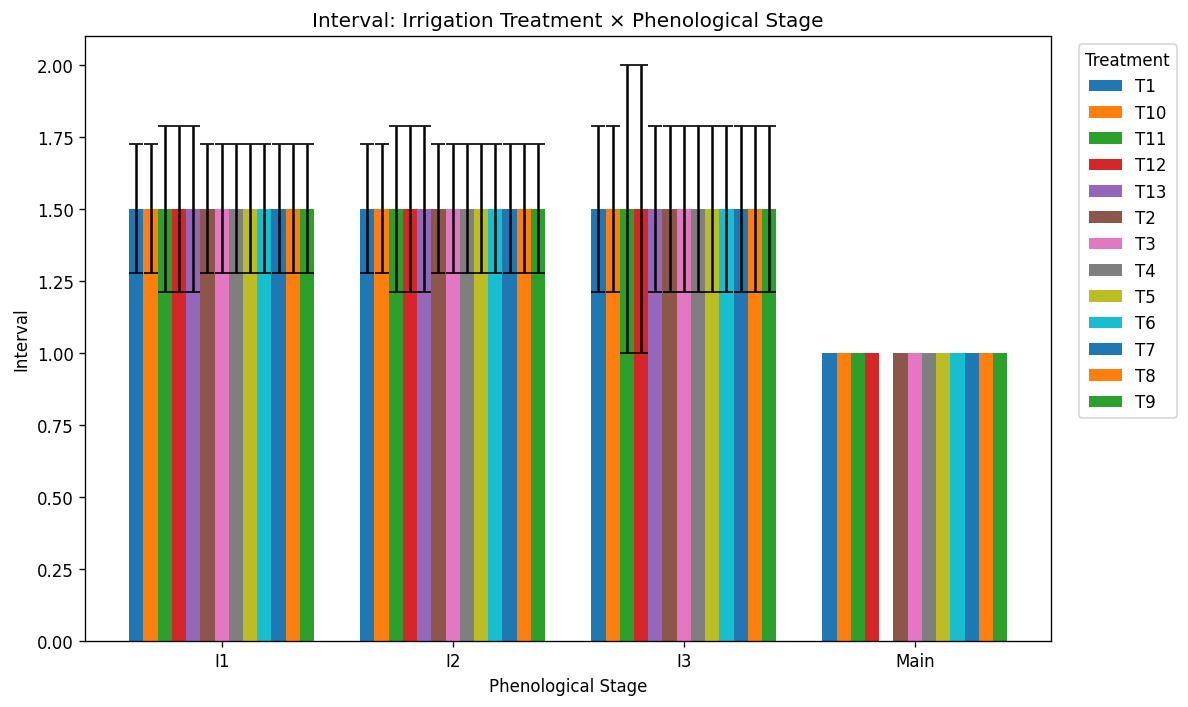

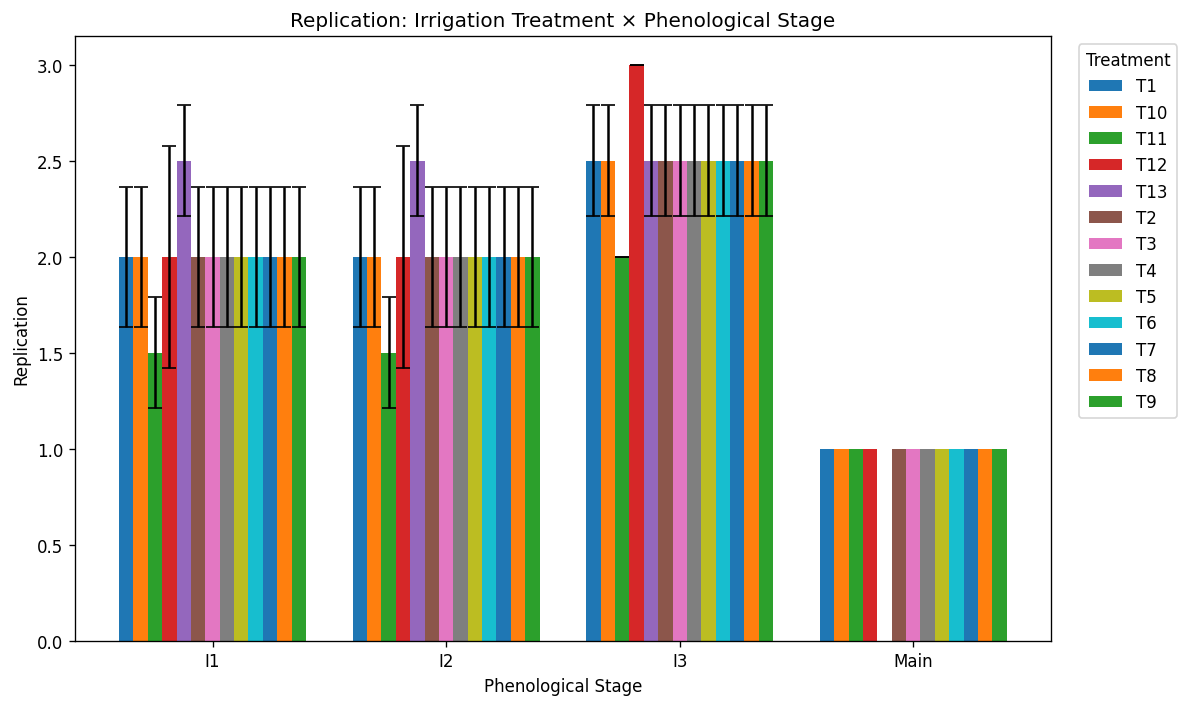

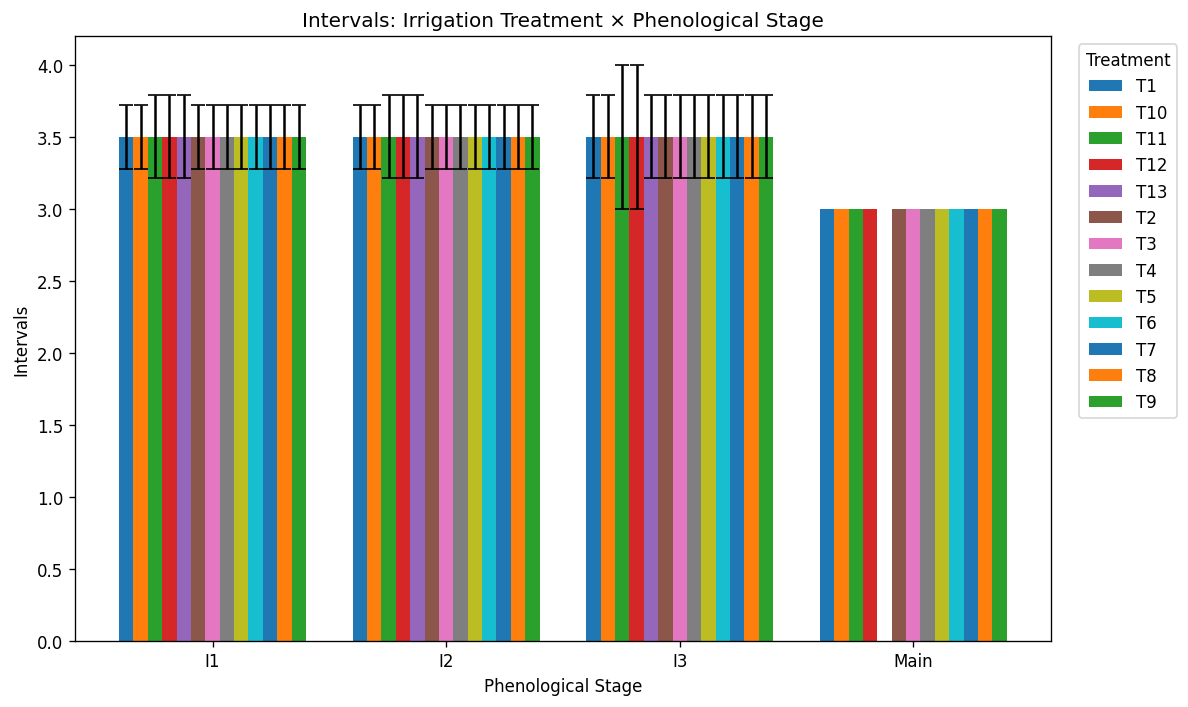

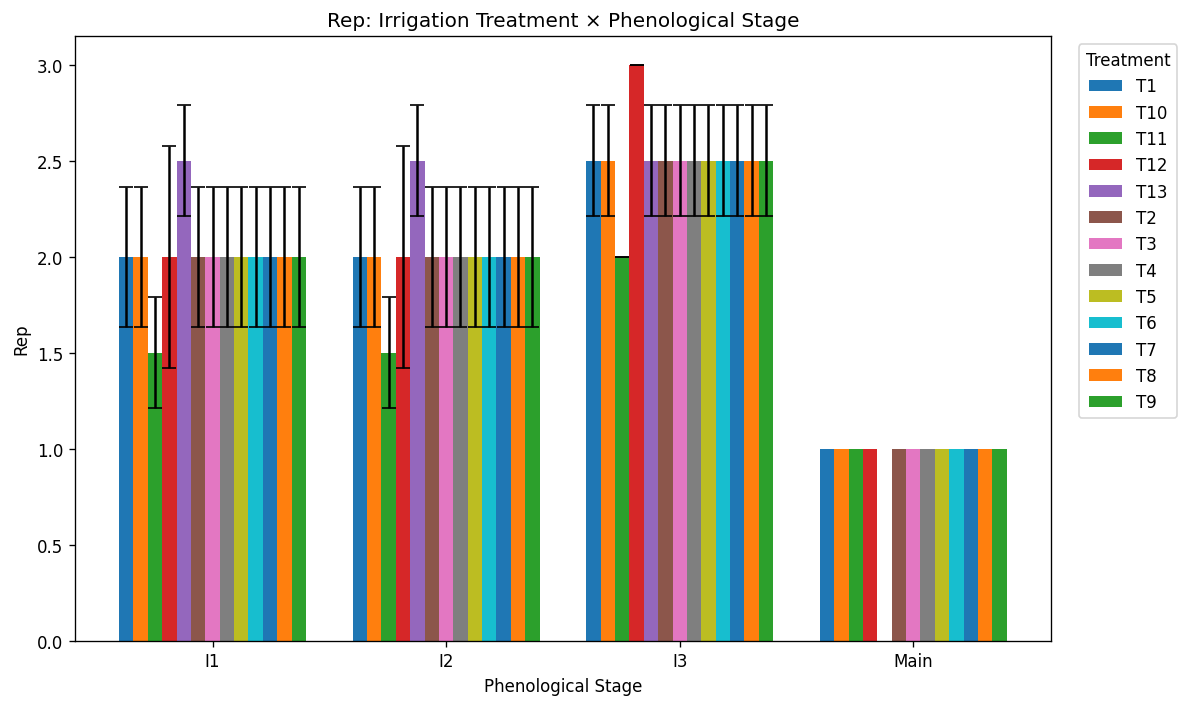

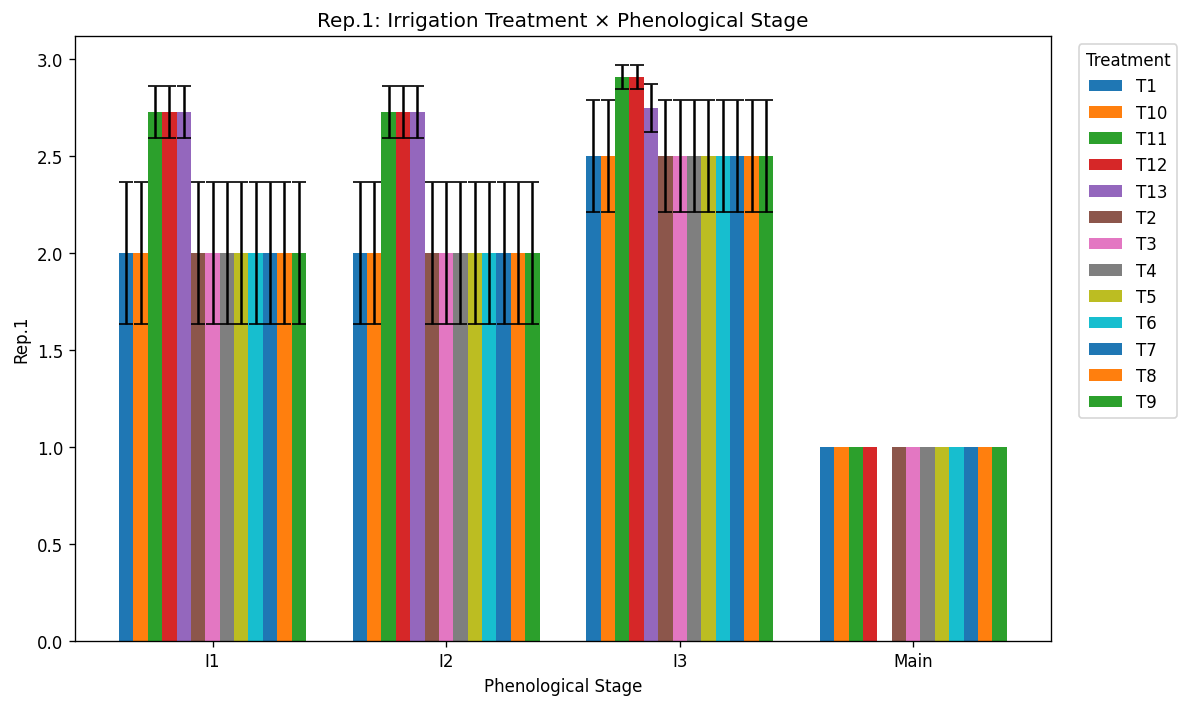


------------------------------------------------------------------------------------------
INITIAL RESPONSE-VARIABLE SCREENING
------------------------------------------------------------------------------------------
   Variable  Minimum_Group_Mean  Maximum_Group_Mean  Relative_Range_Percent
Replication                 1.0            3.000000              105.699482
        Rep                 1.0            3.000000              105.699482
      Rep.1                 1.0            2.909091               95.518395
   Interval                 1.0            1.500000               36.170213
  Intervals                 3.0            3.500000               14.782609

CELL 9 COMPLETED SUCCESSFULLY
Treatment source column : Treat
Stage source column     : phenological_stage
Standardized treatment column : irrigation_treatment
Standardized stage column     : phenological_stage
Number of treatments          : 13
Number of phenological stages : 4
Numeric response variables    : 5

Excel res

In [10]:
# ============================================================
# CELL 9 — TREATMENT × PHENOLOGICAL STAGE
# DESCRIPTIVE ANALYSIS & VISUALIZATION
# ROBUST VERSION — AUTO-CREATES irrigation_treatment
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("CELL 9 — TREATMENT × PHENOLOGICAL STAGE DESCRIPTIVE ANALYSIS")
print("=" * 90)

# ------------------------------------------------------------
# 1. CHECK ANALYSIS DATASET
# ------------------------------------------------------------
if "analysis_df" not in globals():
    raise ValueError(
        "analysis_df was not found. Please run CELL 6/7 before CELL 9."
    )

print("\nDataset shape:", analysis_df.shape)

print("\nAvailable columns:")
for i, col in enumerate(analysis_df.columns, 1):
    print(f"{i:02d}. {col}")


# ------------------------------------------------------------
# 2. AUTOMATICALLY IDENTIFY TREATMENT COLUMN
# ------------------------------------------------------------
treatment_candidates = [
    "irrigation_treatment",
    "Treat",
    "Treatment",
    "treatment",
    "irrigation",
    "Irrigation",
    "treatment_level",
    "water_treatment",
    "water_regime",
    "water_level"
]

treatment_column = None

# Exact match first
for col in treatment_candidates:
    if col in analysis_df.columns:
        treatment_column = col
        break

# Normalized search if exact match fails
if treatment_column is None:

    for col in analysis_df.columns:

        col_norm = str(col).strip().lower().replace(" ", "_")

        if col_norm in [
            "treat",
            "treatment",
            "irrigation_treatment",
            "irrigation",
            "water_treatment",
            "water_regime",
            "water_level"
        ]:
            treatment_column = col
            break


# ------------------------------------------------------------
# 3. AUTOMATICALLY IDENTIFY PHENOLOGICAL STAGE COLUMN
# ------------------------------------------------------------
stage_candidates = [
    "phenological_stage",
    "Stage",
    "stage",
    "Phenological Stage",
    "phenology",
    "phenological"
]

stage_column = None

for col in stage_candidates:
    if col in analysis_df.columns:
        stage_column = col
        break

# Normalized search
if stage_column is None:

    for col in analysis_df.columns:

        col_norm = (
            str(col)
            .strip()
            .lower()
            .replace(" ", "_")
        )

        if (
            "phenological_stage" in col_norm
            or col_norm == "stage"
            or col_norm == "phenological"
        ):
            stage_column = col
            break


# ------------------------------------------------------------
# 4. CHECK IDENTIFICATION
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("VARIABLE IDENTIFICATION")
print("-" * 90)

print("Treatment column detected :", treatment_column)
print("Stage column detected     :", stage_column)

if treatment_column is None:
    raise ValueError(
        "No treatment column could be detected. "
        "Your dataset should contain 'Treat' or a similar treatment column."
    )

if stage_column is None:
    raise ValueError(
        "No phenological-stage column could be detected."
    )


# ------------------------------------------------------------
# 5. CREATE STANDARDIZED ANALYSIS COLUMNS
# ------------------------------------------------------------
analysis_df["irrigation_treatment"] = (
    analysis_df[treatment_column]
    .astype(str)
    .str.strip()
)

analysis_df["phenological_stage"] = (
    analysis_df[stage_column]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 6. CONVERT COMMON MISSING VALUE MARKERS
# ------------------------------------------------------------
missing_markers = [
    "",
    "nan",
    "NaN",
    "NA",
    "N/A",
    "na",
    "null",
    "None",
    "-"
]

analysis_df["irrigation_treatment"] = (
    analysis_df["irrigation_treatment"]
    .replace(missing_markers, np.nan)
)

analysis_df["phenological_stage"] = (
    analysis_df["phenological_stage"]
    .replace(missing_markers, np.nan)
)


# ------------------------------------------------------------
# 7. REMOVE RECORDS WITHOUT TREATMENT/STAGE
# ------------------------------------------------------------
eda_df = analysis_df.dropna(
    subset=[
        "irrigation_treatment",
        "phenological_stage"
    ]
).copy()

print("\nAnalysis dataset shape:", eda_df.shape)


# ------------------------------------------------------------
# 8. SHOW ACTUAL TREATMENT VALUES
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("ACTUAL IRRIGATION TREATMENTS")
print("-" * 90)

treatment_counts = (
    eda_df["irrigation_treatment"]
    .value_counts(dropna=False)
)

print(treatment_counts)


# ------------------------------------------------------------
# 9. SHOW ACTUAL PHENOLOGICAL STAGES
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("ACTUAL PHENOLOGICAL STAGES")
print("-" * 90)

stage_counts = (
    eda_df["phenological_stage"]
    .value_counts(dropna=False)
)

print(stage_counts)


# ------------------------------------------------------------
# 10. TREATMENT × STAGE CROSS-TABULATION
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("TREATMENT × PHENOLOGICAL STAGE")
print("-" * 90)

treatment_stage_table = pd.crosstab(
    eda_df["irrigation_treatment"],
    eda_df["phenological_stage"]
)

print(treatment_stage_table)


# ------------------------------------------------------------
# 11. PERCENTAGE DISTRIBUTION
# ------------------------------------------------------------
treatment_stage_percentage = (
    pd.crosstab(
        eda_df["irrigation_treatment"],
        eda_df["phenological_stage"],
        normalize="index"
    ) * 100
)

print("\nTreatment × Stage percentage:")
print(treatment_stage_percentage.round(2))


# ------------------------------------------------------------
# 12. IDENTIFY NUMERIC RESPONSE VARIABLES
# ------------------------------------------------------------
exclude_columns = {
    "record_id",
    "irrigation_treatment",
    "phenological_stage"
}

numeric_variables = []

for col in eda_df.select_dtypes(include=np.number).columns:

    col_norm = str(col).strip().lower()

    # Exclude obvious ID/index columns
    if col in exclude_columns:
        continue

    if (
        col_norm.startswith("unnamed")
        or col_norm.endswith("_id")
        or col_norm == "id"
        or col_norm == "index"
    ):
        continue

    numeric_variables.append(col)


print("\n" + "-" * 90)
print("NUMERIC RESPONSE VARIABLES")
print("-" * 90)

print("Number of numeric variables:", len(numeric_variables))

for col in numeric_variables:
    print(" -", col)


# ------------------------------------------------------------
# 13. OVERALL DESCRIPTIVE STATISTICS
# ------------------------------------------------------------
if len(numeric_variables) > 0:

    overall_summary = eda_df[numeric_variables].describe().T

    overall_summary["median"] = (
        eda_df[numeric_variables].median()
    )

    overall_summary["missing"] = (
        eda_df[numeric_variables].isna().sum()
    )

else:

    overall_summary = pd.DataFrame()


# ------------------------------------------------------------
# 14. TREATMENT × STAGE DESCRIPTIVE STATISTICS
# ------------------------------------------------------------
descriptive_results = []

for treatment in sorted(
    eda_df["irrigation_treatment"].dropna().unique(),
    key=str
):

    for stage in sorted(
        eda_df["phenological_stage"].dropna().unique(),
        key=str
    ):

        subset = eda_df[
            (eda_df["irrigation_treatment"] == treatment)
            &
            (eda_df["phenological_stage"] == stage)
        ]

        if len(subset) == 0:
            continue

        for variable in numeric_variables:

            values = pd.to_numeric(
                subset[variable],
                errors="coerce"
            ).dropna()

            n = len(values)

            if n == 0:
                continue

            mean_value = values.mean()
            sd_value = values.std(ddof=1)

            if n > 1:
                se_value = sd_value / np.sqrt(n)
            else:
                se_value = np.nan

            descriptive_results.append({
                "Irrigation_Treatment": treatment,
                "Phenological_Stage": stage,
                "Variable": variable,
                "N": n,
                "Mean": mean_value,
                "SD": sd_value,
                "SE": se_value,
                "Median": values.median(),
                "Min": values.min(),
                "Max": values.max()
            })


treatment_stage_descriptive = pd.DataFrame(
    descriptive_results
)


# ------------------------------------------------------------
# 15. TREATMENT-LEVEL SUMMARY
# ------------------------------------------------------------
treatment_summary = []

for treatment, group in eda_df.groupby(
    "irrigation_treatment",
    dropna=False
):

    for variable in numeric_variables:

        values = pd.to_numeric(
            group[variable],
            errors="coerce"
        ).dropna()

        if len(values) == 0:
            continue

        treatment_summary.append({
            "Irrigation_Treatment": treatment,
            "Variable": variable,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(ddof=1),
            "Median": values.median(),
            "Min": values.min(),
            "Max": values.max()
        })

treatment_summary = pd.DataFrame(
    treatment_summary
)


# ------------------------------------------------------------
# 16. STAGE-LEVEL SUMMARY
# ------------------------------------------------------------
stage_summary = []

for stage, group in eda_df.groupby(
    "phenological_stage",
    dropna=False
):

    for variable in numeric_variables:

        values = pd.to_numeric(
            group[variable],
            errors="coerce"
        ).dropna()

        if len(values) == 0:
            continue

        stage_summary.append({
            "Phenological_Stage": stage,
            "Variable": variable,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(ddof=1),
            "Median": values.median(),
            "Min": values.min(),
            "Max": values.max()
        })

stage_summary = pd.DataFrame(stage_summary)


# ------------------------------------------------------------
# 17. VISUALIZATION
# ------------------------------------------------------------
print("\n" + "-" * 90)
print("GENERATING TREATMENT × STAGE PLOTS")
print("-" * 90)

plot_dir = os.path.join(
    OUTPUT_DIR,
    "CELL9_Treatment_Stage_Plots"
)

os.makedirs(plot_dir, exist_ok=True)


# Plot maximum 12 variables initially
plot_variables = numeric_variables[:12]

for variable in plot_variables:

    plot_data = (
        eda_df
        .groupby(
            [
                "phenological_stage",
                "irrigation_treatment"
            ]
        )[variable]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    if plot_data.empty:
        continue

    plot_data["SE"] = (
        plot_data["std"]
        / np.sqrt(plot_data["count"])
    )

    stages = sorted(
        plot_data["phenological_stage"].unique(),
        key=str
    )

    treatments = sorted(
        plot_data["irrigation_treatment"].unique(),
        key=str
    )

    x = np.arange(len(stages))

    width = 0.8 / max(len(treatments), 1)

    plt.figure(figsize=(10, 6))

    for i, treatment in enumerate(treatments):

        subset = plot_data[
            plot_data["irrigation_treatment"] == treatment
        ]

        values = []
        errors = []

        for stage in stages:

            row = subset[
                subset["phenological_stage"] == stage
            ]

            if len(row) > 0:
                values.append(row["mean"].iloc[0])
                errors.append(row["SE"].iloc[0])
            else:
                values.append(np.nan)
                errors.append(np.nan)

        offset = (
            i - (len(treatments) - 1) / 2
        ) * width

        plt.bar(
            x + offset,
            values,
            width=width,
            yerr=errors,
            capsize=4,
            label=str(treatment)
        )

    plt.xticks(x, stages)
    plt.xlabel("Phenological Stage")
    plt.ylabel(variable)
    plt.title(
        f"{variable}: Irrigation Treatment × Phenological Stage"
    )

    plt.legend(
        title="Treatment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    safe_name = (
        str(variable)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        os.path.join(
            plot_dir,
            f"{safe_name}_Treatment_Stage.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ------------------------------------------------------------
# 18. INITIAL RESPONSE VARIABLE SCREENING
# ------------------------------------------------------------
screening_results = []

for variable in numeric_variables:

    if treatment_stage_descriptive.empty:
        continue

    temp = treatment_stage_descriptive[
        treatment_stage_descriptive["Variable"] == variable
    ]

    if temp.empty:
        continue

    group_means = temp["Mean"].dropna()

    if len(group_means) < 2:
        continue

    minimum = group_means.min()
    maximum = group_means.max()
    overall_mean = group_means.mean()

    if overall_mean != 0:
        relative_range = (
            (maximum - minimum)
            / abs(overall_mean)
            * 100
        )
    else:
        relative_range = np.nan

    screening_results.append({
        "Variable": variable,
        "Minimum_Group_Mean": minimum,
        "Maximum_Group_Mean": maximum,
        "Relative_Range_Percent": relative_range
    })


response_screening = pd.DataFrame(
    screening_results
)

if not response_screening.empty:

    response_screening = response_screening.sort_values(
        "Relative_Range_Percent",
        ascending=False
    )

    print("\n" + "-" * 90)
    print("INITIAL RESPONSE-VARIABLE SCREENING")
    print("-" * 90)

    print(
        response_screening.to_string(index=False)
    )


# ------------------------------------------------------------
# 19. SAVE RESULTS
# ------------------------------------------------------------
output_file = os.path.join(
    OUTPUT_DIR,
    "07_treatment_stage_descriptive_analysis.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    treatment_stage_table.to_excel(
        writer,
        sheet_name="Treatment_Stage_Count"
    )

    treatment_stage_percentage.to_excel(
        writer,
        sheet_name="Treatment_Stage_Percent"
    )

    if not overall_summary.empty:
        overall_summary.to_excel(
            writer,
            sheet_name="Overall_Descriptive"
        )

    if not treatment_stage_descriptive.empty:
        treatment_stage_descriptive.to_excel(
            writer,
            sheet_name="Treatment_Stage_Stats",
            index=False
        )

    if not treatment_summary.empty:
        treatment_summary.to_excel(
            writer,
            sheet_name="Treatment_Summary",
            index=False
        )

    if not stage_summary.empty:
        stage_summary.to_excel(
            writer,
            sheet_name="Stage_Summary",
            index=False
        )

    if not response_screening.empty:
        response_screening.to_excel(
            writer,
            sheet_name="Response_Screening",
            index=False
        )


# ------------------------------------------------------------
# 20. FINAL SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("CELL 9 COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Treatment source column :", treatment_column)
print("Stage source column     :", stage_column)

print(
    "Standardized treatment column : irrigation_treatment"
)

print(
    "Standardized stage column     : phenological_stage"
)

print(
    "Number of treatments          :",
    eda_df["irrigation_treatment"].nunique()
)

print(
    "Number of phenological stages :",
    eda_df["phenological_stage"].nunique()
)

print(
    "Numeric response variables    :",
    len(numeric_variables)
)

print(
    "\nExcel results saved to:"
)
print(output_file)

print(
    "\nPlots saved to:"
)
print(plot_dir)

print(
    "\nNext step: CELL 10 — statistical analysis of "
    "irrigation treatment × phenological stage interaction."
)

CELL 10 — STATISTICAL ANALYSIS
IRRIGATION TREATMENT × PHENOLOGICAL STAGE

Dataset shape: (372, 36)

Replication column detected: replication

----------------------------------------------------------------------------------------------------
RESPONSE VARIABLES
----------------------------------------------------------------------------------------------------
Number of response variables: 5
 - Interval
 - Replication
 - Intervals
 - Rep
 - Rep.1

RUNNING TWO-WAY ANOVA

TWO-WAY ANOVA RESULTS


,Variable,N,Treatment_F,Treatment_df,Treatment_p,Treatment_eta_squared,Stage_F,Stage_df,Stage_p,Stage_eta_squared,Treatment_x_Stage_F,Treatment_x_Stage_df,Treatment_x_Stage_p,Treatment_x_Stage_eta_squared,Treatment_p_Bonferroni,Stage_p_Bonferroni,Interaction_p_Bonferroni,Treatment_Significant,Stage_Significant,Interaction_Significant
0,Interval,204,0.00000,12.0,1.00000,0.00000,2.98295,3.0,0.03318,0.05526,0.00000,36.0,1.0,0.00000,1.0,0.16589,1.0,False,False,False
1,Replication,204,0.50184,12.0,0.89982,0.03115,10.77653,3.0,0.00000,0.16724,0.05448,36.0,1.0,0.01015,1.0,0.00001,1.0,False,True,False
2,Intervals,204,0.00000,12.0,1.00000,0.00000,2.98295,3.0,0.03318,0.05526,0.00000,36.0,1.0,0.00000,1.0,0.16589,1.0,False,False,False
3,Rep,204,0.50184,12.0,0.89982,0.03115,10.77653,3.0,0.00000,0.16724,0.05448,36.0,1.0,0.01015,1.0,0.00001,1.0,False,True,False
4,Rep.1,372,6.38907,12.0,0.00000,0.16883,16.33861,3.0,0.00000,0.10794,0.20644,36.0,1.0,0.01637,0.0,0.00000,1.0,True,True,False



SIGNIFICANT TREATMENT × STAGE INTERACTIONS
No statistically significant Treatment × Stage interactions after Bonferroni correction.

TUKEY HSD POST-HOC ANALYSIS

Tukey HSD — Rep.1
Variable group1 group2  meandiff  p-adj   lower   upper  reject
   Rep.1     T1    T10    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1    T11    0.7024 0.0173  0.0628  1.3420    True
   Rep.1     T1    T12    0.7024 0.0173  0.0628  1.3420    True
   Rep.1     T1    T13    0.6765 0.0268  0.0378  1.3151    True
   Rep.1     T1     T2    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T3    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T4    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T5    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T6    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T7    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T8    0.0000 1.0000 -0.8078  0.8078   False
   Rep.1     T1     T9    0.0000 1.0000 -0.8078  0.

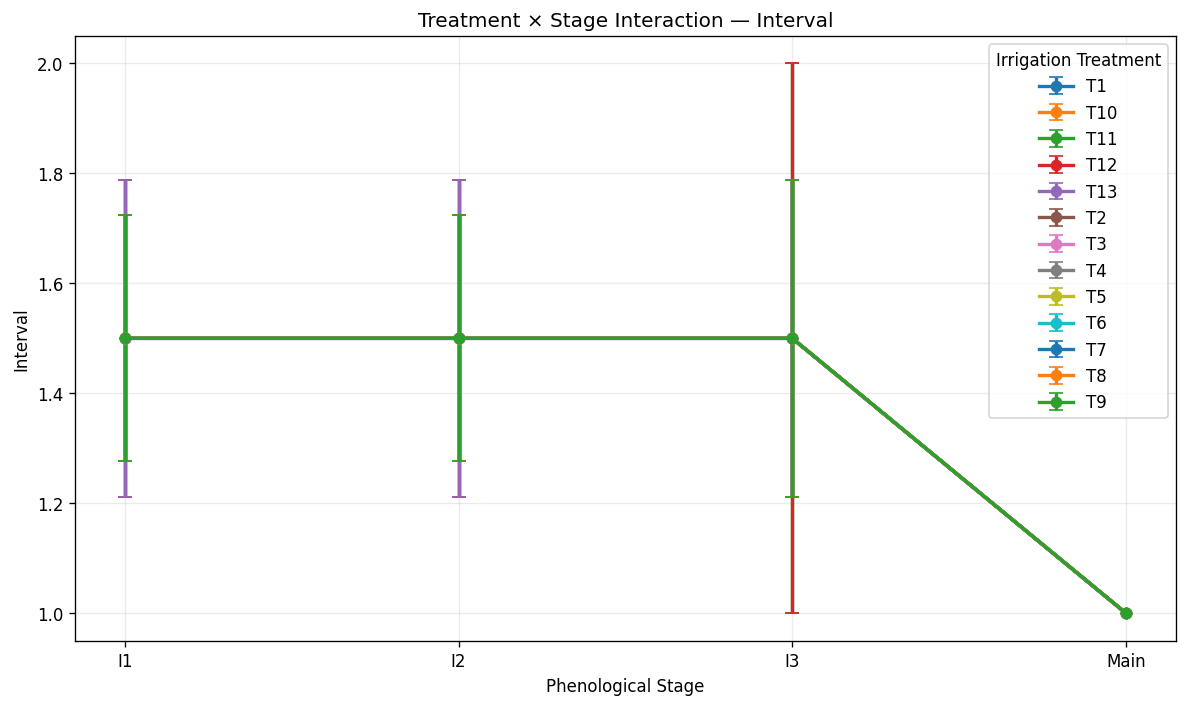

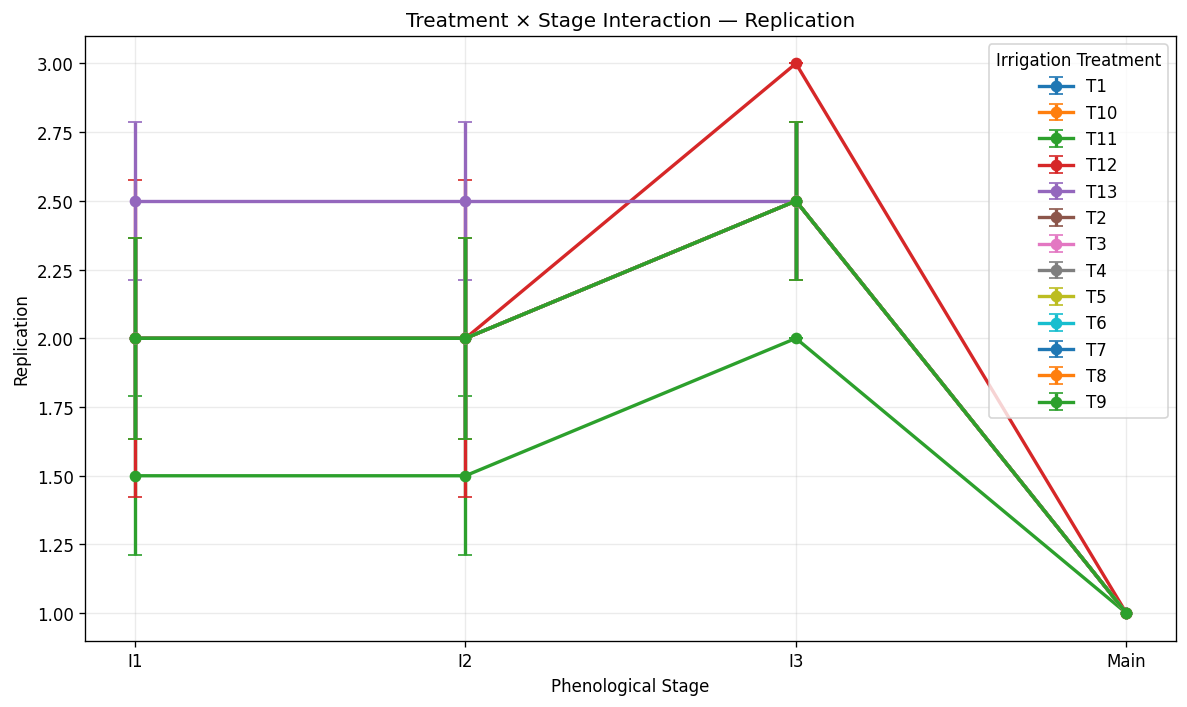

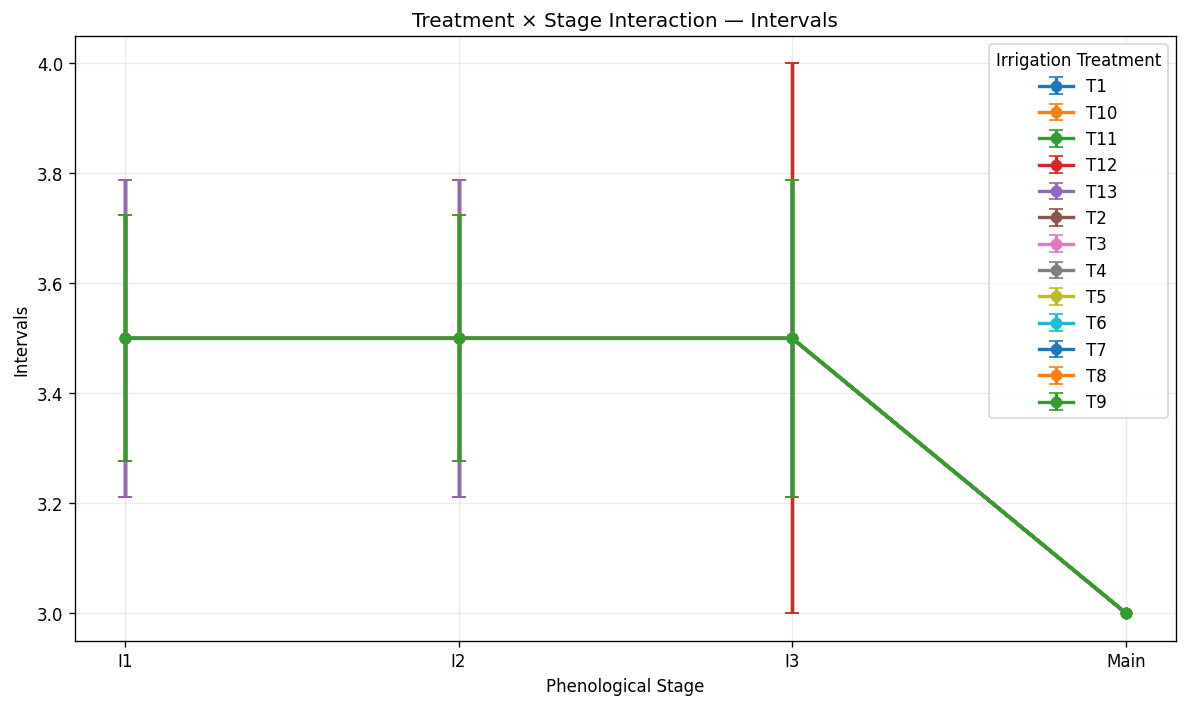

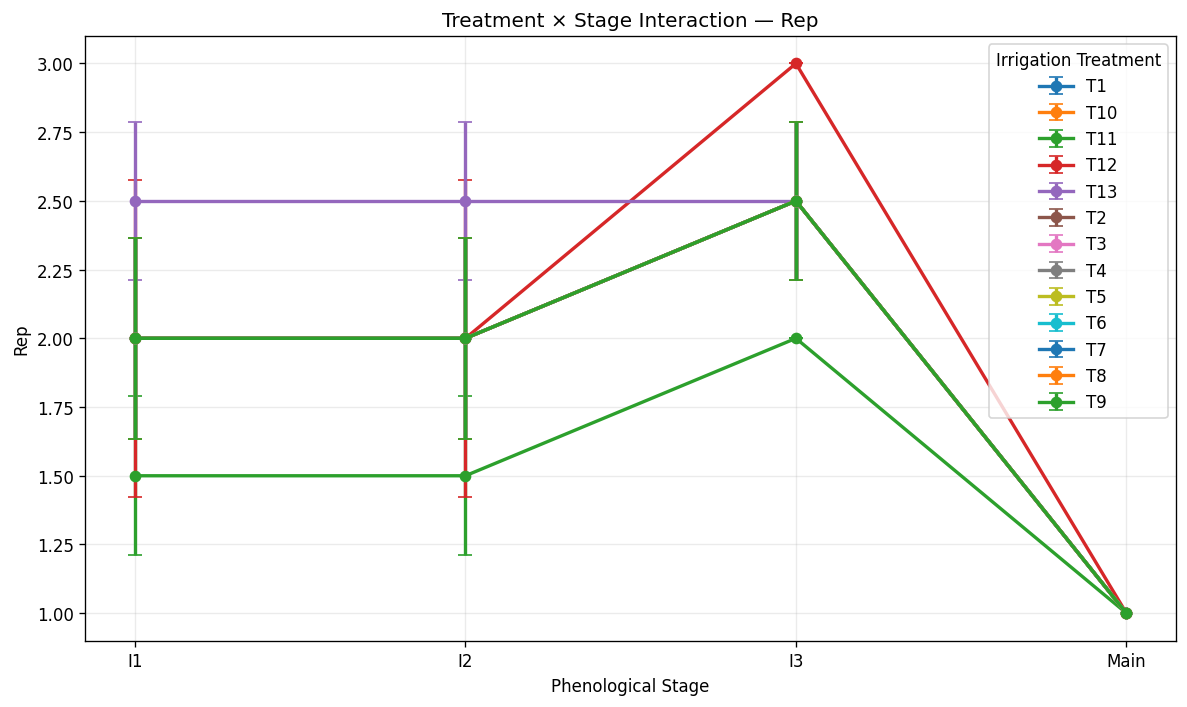

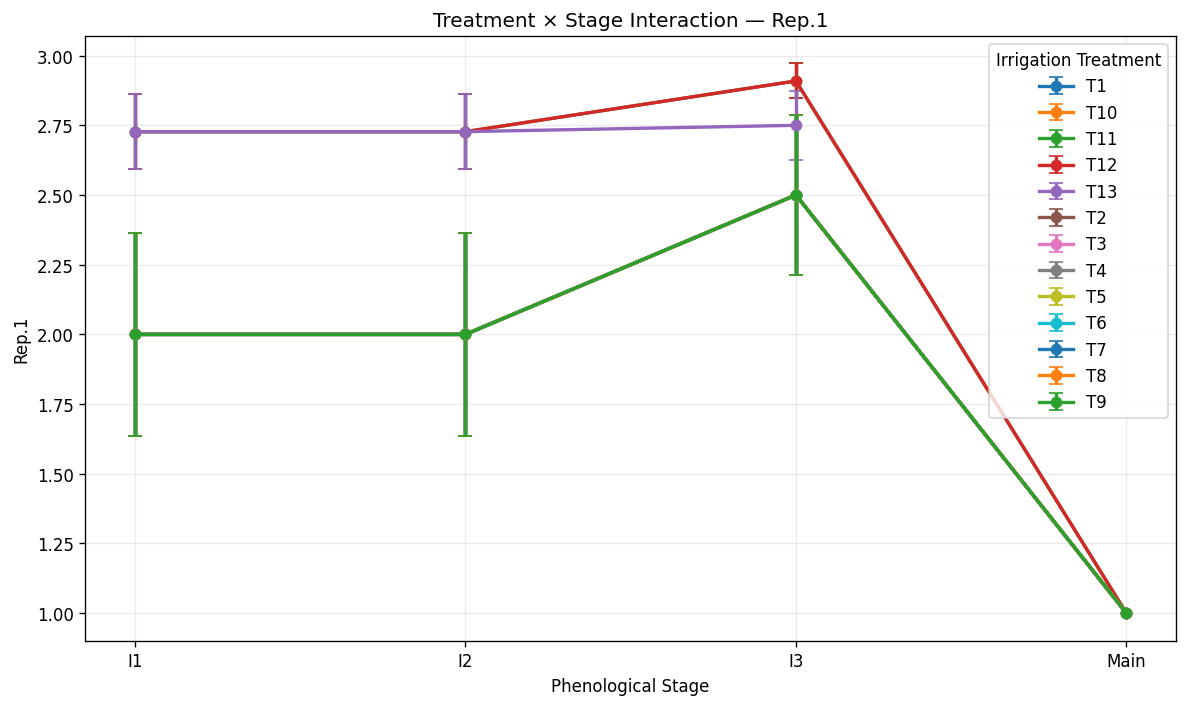


ANOVA RESIDUAL NORMALITY CHECK


,Variable,N_Residuals,Shapiro_W,Shapiro_p,Normality_at_0.05
0,Interval,204,0.67254,0.0,False
1,Replication,204,0.88295,0.0,False
2,Intervals,204,0.67254,0.0,False
3,Rep,204,0.88295,0.0,False
4,Rep.1,372,0.87907,0.0,False



HOMOGENEITY OF VARIANCE — LEVENE TEST


,Variable,Levene_Statistic,Levene_p,Homogeneous_at_0.05
0,Interval,NaN,NaN,NaN
1,Replication,0.57564,0.97595,True
2,Intervals,NaN,NaN,NaN
3,Rep,0.57564,0.97595,True
4,Rep.1,1.50028,0.03415,False



FINAL STATISTICAL SUMMARY


,Variable,Treatment_p_adj,Stage_p_adj,Interaction_p_adj,Treatment_eta_squared,Stage_eta_squared,Interaction_eta_squared,Interpretation
0,Interval,1.0,0.16589,1.0,0.00000,0.05526,0.00000,No significant treatment/stage effect
1,Replication,1.0,0.00001,1.0,0.03115,0.16724,0.01015,Significant phenological stage effect
2,Intervals,1.0,0.16589,1.0,0.00000,0.05526,0.00000,No significant treatment/stage effect
3,Rep,1.0,0.00001,1.0,0.03115,0.16724,0.01015,Significant phenological stage effect
4,Rep.1,0.0,0.00000,1.0,0.16883,0.10794,0.01637,Significant treatment and stage effects



CELL 10 COMPLETED SUCCESSFULLY

Statistical analysis file:
kiwifruit_research_outputs/08_statistical_analysis_treatment_stage.xlsx

Interaction plots:
kiwifruit_research_outputs/CELL10_Statistical_Plots

Main statistical tests performed:
1. Irrigation treatment main effect
2. Phenological stage main effect
3. Irrigation treatment × phenological stage interaction
4. Eta-squared effect sizes
5. Bonferroni correction
6. Tukey HSD post-hoc comparisons
7. Shapiro-Wilk residual normality test
8. Levene homogeneity test

Next step: CELL 11 — feature selection and preparation for ML/DL stress classification.


In [11]:
# ============================================================
# CELL 10 — STATISTICAL ANALYSIS
# IRRIGATION TREATMENT × PHENOLOGICAL STAGE
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")

print("=" * 100)
print("CELL 10 — STATISTICAL ANALYSIS")
print("IRRIGATION TREATMENT × PHENOLOGICAL STAGE")
print("=" * 100)


# ------------------------------------------------------------
# 1. CHECK REQUIRED DATA
# ------------------------------------------------------------

if "eda_df" not in globals():
    if "analysis_df" in globals():
        eda_df = analysis_df.copy()
    else:
        raise ValueError(
            "analysis_df/eda_df not found. Please run CELL 9 first."
        )

print("\nDataset shape:", eda_df.shape)


# ------------------------------------------------------------
# 2. MAKE SURE STANDARDIZED VARIABLES EXIST
# ------------------------------------------------------------

if "irrigation_treatment" not in eda_df.columns:

    if "Treat" in eda_df.columns:
        eda_df["irrigation_treatment"] = (
            eda_df["Treat"]
            .astype(str)
            .str.strip()
        )

    else:
        raise ValueError(
            "irrigation_treatment was not found."
        )


if "phenological_stage" not in eda_df.columns:

    raise ValueError(
        "phenological_stage was not found. "
        "Please run CELL 8/9 first."
    )


# ------------------------------------------------------------
# 3. STANDARDIZE FACTOR TYPES
# ------------------------------------------------------------

eda_df["irrigation_treatment"] = (
    eda_df["irrigation_treatment"]
    .astype(str)
    .str.strip()
)

eda_df["phenological_stage"] = (
    eda_df["phenological_stage"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 4. IDENTIFY REPLICATION VARIABLE
# ------------------------------------------------------------

replication_column = None

replication_candidates = [
    "replication",
    "Rep.1",
    "Replication",
    "Rep",
    "rep",
    "replicate",
    "replication_number"
]

for col in replication_candidates:

    if col in eda_df.columns:
        replication_column = col
        break


print("\nReplication column detected:", replication_column)


if replication_column is not None:

    eda_df["replication_factor"] = (
        eda_df[replication_column]
        .astype(str)
        .str.strip()
    )

else:

    eda_df["replication_factor"] = "R1"

    print(
        "WARNING: No replication column detected. "
        "Analysis will proceed without replication blocking."
    )


# ------------------------------------------------------------
# 5. IDENTIFY RESPONSE VARIABLES
# ------------------------------------------------------------

exclude_columns = {
    "record_id",
    "irrigation_treatment",
    "phenological_stage",
    "replication_factor"
}

numeric_variables = []

for col in eda_df.select_dtypes(include=np.number).columns:

    col_norm = str(col).strip().lower()

    if col in exclude_columns:
        continue

    # Remove Excel-generated index columns
    if col_norm.startswith("unnamed"):
        continue

    if col_norm in [
        "id",
        "index"
    ]:
        continue

    if col_norm.endswith("_id"):
        continue

    numeric_variables.append(col)


print("\n" + "-" * 100)
print("RESPONSE VARIABLES")
print("-" * 100)

print("Number of response variables:", len(numeric_variables))

for variable in numeric_variables:
    print(" -", variable)


if len(numeric_variables) == 0:

    raise ValueError(
        "No numeric response variables were detected."
    )


# ------------------------------------------------------------
# 6. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

if "OUTPUT_DIR" not in globals():

    OUTPUT_DIR = "research_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

stat_plot_dir = os.path.join(
    OUTPUT_DIR,
    "CELL10_Statistical_Plots"
)

os.makedirs(
    stat_plot_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 7. TWO-WAY ANOVA FUNCTION
# ------------------------------------------------------------

def run_two_way_anova(data, response):

    temp = data[
        [
            response,
            "irrigation_treatment",
            "phenological_stage"
        ]
    ].copy()

    temp[response] = pd.to_numeric(
        temp[response],
        errors="coerce"
    )

    temp = temp.dropna()

    # Need at least two treatment levels and two stages
    if (
        temp["irrigation_treatment"].nunique() < 2
        or
        temp["phenological_stage"].nunique() < 2
    ):
        return None

    try:

        model = ols(
            f'Q("{response}") ~ C(irrigation_treatment) '
            f'+ C(phenological_stage) '
            f'+ C(irrigation_treatment):C(phenological_stage)',
            data=temp
        ).fit()

        anova_table = sm.stats.anova_lm(
            model,
            typ=2
        )

        return model, anova_table, temp

    except Exception as e:

        print(
            f"ANOVA failed for {response}: {e}"
        )

        return None


# ------------------------------------------------------------
# 8. RUN TWO-WAY ANOVA FOR ALL VARIABLES
# ------------------------------------------------------------

anova_results = []

model_objects = {}

print("\n" + "=" * 100)
print("RUNNING TWO-WAY ANOVA")
print("=" * 100)


for variable in numeric_variables:

    result = run_two_way_anova(
        eda_df,
        variable
    )

    if result is None:
        continue

    model, anova_table, temp = result

    model_objects[variable] = model

    # Extract terms safely
    treatment_term = [
        x for x in anova_table.index
        if (
            x.startswith("C(irrigation_treatment)")
            and ":" not in x
        )
    ]

    stage_term = [
        x for x in anova_table.index
        if (
            x.startswith("C(phenological_stage)")
            and ":" not in x
        )
    ]

    interaction_term = [
        x for x in anova_table.index
        if (
            "irrigation_treatment" in x
            and "phenological_stage" in x
        )
    ]


    # Treatment
    if len(treatment_term) > 0:

        tterm = treatment_term[0]

        treatment_p = anova_table.loc[
            tterm,
            "PR(>F)"
        ]

        treatment_F = anova_table.loc[
            tterm,
            "F"
        ]

        treatment_df = anova_table.loc[
            tterm,
            "df"
        ]

    else:

        treatment_p = np.nan
        treatment_F = np.nan
        treatment_df = np.nan


    # Stage
    if len(stage_term) > 0:

        sterm = stage_term[0]

        stage_p = anova_table.loc[
            sterm,
            "PR(>F)"
        ]

        stage_F = anova_table.loc[
            sterm,
            "F"
        ]

        stage_df = anova_table.loc[
            sterm,
            "df"
        ]

    else:

        stage_p = np.nan
        stage_F = np.nan
        stage_df = np.nan


    # Interaction
    if len(interaction_term) > 0:

        iterm = interaction_term[0]

        interaction_p = anova_table.loc[
            iterm,
            "PR(>F)"
        ]

        interaction_F = anova_table.loc[
            iterm,
            "F"
        ]

        interaction_df = anova_table.loc[
            iterm,
            "df"
        ]

    else:

        interaction_p = np.nan
        interaction_F = np.nan
        interaction_df = np.nan


    # --------------------------------------------------------
    # EFFECT SIZES — ETA SQUARED
    # --------------------------------------------------------

    total_ss = anova_table["sum_sq"].sum()

    treatment_eta2 = np.nan
    stage_eta2 = np.nan
    interaction_eta2 = np.nan

    if total_ss > 0:

        if len(treatment_term) > 0:
            treatment_eta2 = (
                anova_table.loc[
                    treatment_term[0],
                    "sum_sq"
                ] / total_ss
            )

        if len(stage_term) > 0:
            stage_eta2 = (
                anova_table.loc[
                    stage_term[0],
                    "sum_sq"
                ] / total_ss
            )

        if len(interaction_term) > 0:
            interaction_eta2 = (
                anova_table.loc[
                    interaction_term[0],
                    "sum_sq"
                ] / total_ss
            )


    anova_results.append({

        "Variable": variable,

        "N": len(temp),

        "Treatment_F": treatment_F,
        "Treatment_df": treatment_df,
        "Treatment_p": treatment_p,
        "Treatment_eta_squared": treatment_eta2,

        "Stage_F": stage_F,
        "Stage_df": stage_df,
        "Stage_p": stage_p,
        "Stage_eta_squared": stage_eta2,

        "Treatment_x_Stage_F": interaction_F,
        "Treatment_x_Stage_df": interaction_df,
        "Treatment_x_Stage_p": interaction_p,
        "Treatment_x_Stage_eta_squared": interaction_eta2
    })


anova_results_df = pd.DataFrame(
    anova_results
)


# ------------------------------------------------------------
# 9. MULTIPLE TESTING CORRECTION
# ------------------------------------------------------------

def bonferroni_adjust(p_values):

    p_values = np.asarray(
        p_values,
        dtype=float
    )

    valid = ~np.isnan(p_values)

    adjusted = np.full(
        len(p_values),
        np.nan
    )

    if valid.sum() > 0:

        adjusted[valid] = np.minimum(
            p_values[valid] * valid.sum(),
            1.0
        )

    return adjusted


if not anova_results_df.empty:

    anova_results_df[
        "Treatment_p_Bonferroni"
    ] = bonferroni_adjust(
        anova_results_df["Treatment_p"]
    )

    anova_results_df[
        "Stage_p_Bonferroni"
    ] = bonferroni_adjust(
        anova_results_df["Stage_p"]
    )

    anova_results_df[
        "Interaction_p_Bonferroni"
    ] = bonferroni_adjust(
        anova_results_df[
            "Treatment_x_Stage_p"
        ]
    )


# ------------------------------------------------------------
# 10. SIGNIFICANCE FLAGS
# ------------------------------------------------------------

if not anova_results_df.empty:

    anova_results_df[
        "Treatment_Significant"
    ] = (
        anova_results_df[
            "Treatment_p_Bonferroni"
        ] < 0.05
    )

    anova_results_df[
        "Stage_Significant"
    ] = (
        anova_results_df[
            "Stage_p_Bonferroni"
        ] < 0.05
    )

    anova_results_df[
        "Interaction_Significant"
    ] = (
        anova_results_df[
            "Interaction_p_Bonferroni"
        ] < 0.05
    )


# ------------------------------------------------------------
# 11. DISPLAY ANOVA RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TWO-WAY ANOVA RESULTS")
print("=" * 100)

if not anova_results_df.empty:

    display(
        anova_results_df.round(5)
    )

else:

    print(
        "No valid ANOVA results were generated."
    )


# ------------------------------------------------------------
# 12. IDENTIFY SIGNIFICANT INTERACTIONS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SIGNIFICANT TREATMENT × STAGE INTERACTIONS")
print("=" * 100)

if not anova_results_df.empty:

    significant_interactions = (
        anova_results_df[
            anova_results_df[
                "Interaction_p_Bonferroni"
            ] < 0.05
        ]
        .sort_values(
            "Interaction_p_Bonferroni"
        )
    )

    if len(significant_interactions) > 0:

        print(
            significant_interactions[
                [
                    "Variable",
                    "Treatment_x_Stage_F",
                    "Treatment_x_Stage_p",
                    "Interaction_p_Bonferroni",
                    "Treatment_x_Stage_eta_squared"
                ]
            ].round(5).to_string(
                index=False
            )
        )

    else:

        print(
            "No statistically significant "
            "Treatment × Stage interactions "
            "after Bonferroni correction."
        )


# ------------------------------------------------------------
# 13. TUKEY POST-HOC TEST
# ------------------------------------------------------------
# Important:
# Post-hoc treatment comparisons are most useful when the
# treatment main effect is significant.
#
# For significant treatment effects, Tukey HSD is performed.
# ------------------------------------------------------------

tukey_results = []

print("\n" + "=" * 100)
print("TUKEY HSD POST-HOC ANALYSIS")
print("=" * 100)


if not anova_results_df.empty:

    significant_treatments = anova_results_df[
        anova_results_df[
            "Treatment_p_Bonferroni"
        ] < 0.05
    ]["Variable"].tolist()

else:

    significant_treatments = []


for variable in significant_treatments:

    temp = eda_df[
        [
            variable,
            "irrigation_treatment"
        ]
    ].copy()

    temp[variable] = pd.to_numeric(
        temp[variable],
        errors="coerce"
    )

    temp = temp.dropna()

    if (
        temp["irrigation_treatment"].nunique()
        < 2
    ):
        continue

    try:

        tukey = pairwise_tukeyhsd(
            endog=temp[variable],
            groups=temp[
                "irrigation_treatment"
            ],
            alpha=0.05
        )

        tukey_df = pd.DataFrame(
            data=tukey._results_table.data[1:],
            columns=tukey._results_table.data[0]
        )

        tukey_df.insert(
            0,
            "Variable",
            variable
        )

        tukey_results.append(
            tukey_df
        )

        print(
            f"\nTukey HSD — {variable}"
        )

        print(
            tukey_df.to_string(
                index=False
            )
        )

    except Exception as e:

        print(
            f"Tukey failed for {variable}: {e}"
        )


if len(tukey_results) > 0:

    tukey_results_df = pd.concat(
        tukey_results,
        ignore_index=True
    )

else:

    tukey_results_df = pd.DataFrame()


# ------------------------------------------------------------
# 14. TREATMENT × STAGE MEAN TABLE
# ------------------------------------------------------------

group_mean_results = []

for variable in numeric_variables:

    temp = eda_df[
        [
            variable,
            "irrigation_treatment",
            "phenological_stage"
        ]
    ].copy()

    temp[variable] = pd.to_numeric(
        temp[variable],
        errors="coerce"
    )

    temp = temp.dropna()

    grouped = (
        temp
        .groupby(
            [
                "irrigation_treatment",
                "phenological_stage"
            ]
        )[variable]
        .agg(
            N="count",
            Mean="mean",
            SD="std"
        )
        .reset_index()
    )

    grouped["Variable"] = variable

    group_mean_results.append(
        grouped
    )


if len(group_mean_results) > 0:

    treatment_stage_means = pd.concat(
        group_mean_results,
        ignore_index=True
    )

else:

    treatment_stage_means = pd.DataFrame()


# ------------------------------------------------------------
# 15. INTERACTION PLOTS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("GENERATING INTERACTION PLOTS")
print("=" * 100)


# Plot variables with significant interaction first
if not anova_results_df.empty:

    significant_interaction_variables = (
        anova_results_df[
            anova_results_df[
                "Interaction_p_Bonferroni"
            ] < 0.05
        ]["Variable"]
        .tolist()
    )

else:

    significant_interaction_variables = []


# If none are significant, plot first 10 variables
if len(significant_interaction_variables) > 0:

    interaction_plot_variables = (
        significant_interaction_variables
    )

else:

    interaction_plot_variables = (
        numeric_variables[:10]
    )


for variable in interaction_plot_variables:

    temp = eda_df[
        [
            variable,
            "irrigation_treatment",
            "phenological_stage"
        ]
    ].copy()

    temp[variable] = pd.to_numeric(
        temp[variable],
        errors="coerce"
    )

    temp = temp.dropna()

    if temp.empty:
        continue

    summary = (
        temp
        .groupby(
            [
                "phenological_stage",
                "irrigation_treatment"
            ]
        )[variable]
        .agg(
            Mean="mean",
            SD="std",
            N="count"
        )
        .reset_index()
    )

    summary["SE"] = (
        summary["SD"]
        / np.sqrt(summary["N"])
    )

    stages = sorted(
        summary[
            "phenological_stage"
        ].unique(),
        key=str
    )

    treatments = sorted(
        summary[
            "irrigation_treatment"
        ].unique(),
        key=str
    )

    plt.figure(
        figsize=(10, 6)
    )

    for treatment in treatments:

        subset = summary[
            summary[
                "irrigation_treatment"
            ] == treatment
        ]

        y = []
        yerr = []
        valid_stages = []

        for stage in stages:

            row = subset[
                subset[
                    "phenological_stage"
                ] == stage
            ]

            if len(row) > 0:

                y.append(
                    row["Mean"].iloc[0]
                )

                yerr.append(
                    row["SE"].iloc[0]
                )

                valid_stages.append(stage)

        if len(valid_stages) > 0:

            plt.errorbar(
                valid_stages,
                y,
                yerr=yerr,
                marker="o",
                capsize=4,
                linewidth=2,
                label=str(treatment)
            )

    plt.xlabel(
        "Phenological Stage"
    )

    plt.ylabel(
        variable
    )

    plt.title(
        f"Treatment × Stage Interaction — {variable}"
    )

    plt.legend(
        title="Irrigation Treatment"
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    safe_name = (
        str(variable)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        os.path.join(
            stat_plot_dir,
            f"{safe_name}_interaction.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ------------------------------------------------------------
# 16. NORMALITY CHECK OF ANOVA RESIDUALS
# ------------------------------------------------------------

normality_results = []

print("\n" + "=" * 100)
print("ANOVA RESIDUAL NORMALITY CHECK")
print("=" * 100)


for variable, model in model_objects.items():

    residuals = model.resid.dropna()

    # Shapiro-Wilk becomes unreliable/expensive for very
    # large samples, so use up to 5000 observations.
    if len(residuals) > 5000:

        residual_sample = residuals.sample(
            5000,
            random_state=42
        )

    else:

        residual_sample = residuals

    if len(residual_sample) >= 3:

        try:

            shapiro_stat, shapiro_p = (
                stats.shapiro(
                    residual_sample
                )
            )

        except Exception:

            shapiro_stat = np.nan
            shapiro_p = np.nan

    else:

        shapiro_stat = np.nan
        shapiro_p = np.nan

    normality_results.append({

        "Variable": variable,
        "N_Residuals": len(residuals),
        "Shapiro_W": shapiro_stat,
        "Shapiro_p": shapiro_p,
        "Normality_at_0.05": (
            shapiro_p >= 0.05
            if not np.isnan(shapiro_p)
            else np.nan
        )
    })


normality_df = pd.DataFrame(
    normality_results
)

if not normality_df.empty:

    display(
        normality_df.round(5)
    )


# ------------------------------------------------------------
# 17. HOMOGENEITY OF VARIANCE — LEVENE TEST
# ------------------------------------------------------------

levene_results = []

print("\n" + "=" * 100)
print("HOMOGENEITY OF VARIANCE — LEVENE TEST")
print("=" * 100)


for variable in numeric_variables:

    groups = []

    for (
        treatment,
        stage
    ), group in eda_df.groupby(
        [
            "irrigation_treatment",
            "phenological_stage"
        ]
    ):

        values = pd.to_numeric(
            group[variable],
            errors="coerce"
        ).dropna()

        if len(values) >= 2:

            groups.append(
                values.values
            )

    if len(groups) >= 2:

        try:

            lev_stat, lev_p = (
                stats.levene(
                    *groups,
                    center="median"
                )
            )

        except Exception:

            lev_stat = np.nan
            lev_p = np.nan

    else:

        lev_stat = np.nan
        lev_p = np.nan


    levene_results.append({

        "Variable": variable,
        "Levene_Statistic": lev_stat,
        "Levene_p": lev_p,
        "Homogeneous_at_0.05": (
            lev_p >= 0.05
            if not np.isnan(lev_p)
            else np.nan
        )
    })


levene_df = pd.DataFrame(
    levene_results
)

if not levene_df.empty:

    display(
        levene_df.round(5)
    )


# ------------------------------------------------------------
# 18. FINAL STATISTICAL CLASSIFICATION
# ------------------------------------------------------------

if not anova_results_df.empty:

    classification = []

    for _, row in anova_results_df.iterrows():

        treatment_sig = (
            row["Treatment_p_Bonferroni"]
            < 0.05
        )

        stage_sig = (
            row["Stage_p_Bonferroni"]
            < 0.05
        )

        interaction_sig = (
            row["Interaction_p_Bonferroni"]
            < 0.05
        )


        if interaction_sig:

            interpretation = (
                "Significant Treatment × Stage interaction"
            )

        elif treatment_sig and stage_sig:

            interpretation = (
                "Significant treatment and stage effects"
            )

        elif treatment_sig:

            interpretation = (
                "Significant irrigation treatment effect"
            )

        elif stage_sig:

            interpretation = (
                "Significant phenological stage effect"
            )

        else:

            interpretation = (
                "No significant treatment/stage effect"
            )


        classification.append({

            "Variable": row["Variable"],

            "Treatment_p_adj":
                row["Treatment_p_Bonferroni"],

            "Stage_p_adj":
                row["Stage_p_Bonferroni"],

            "Interaction_p_adj":
                row["Interaction_p_Bonferroni"],

            "Treatment_eta_squared":
                row["Treatment_eta_squared"],

            "Stage_eta_squared":
                row["Stage_eta_squared"],

            "Interaction_eta_squared":
                row["Treatment_x_Stage_eta_squared"],

            "Interpretation":
                interpretation
        })


    statistical_classification = pd.DataFrame(
        classification
    )

else:

    statistical_classification = pd.DataFrame()


# ------------------------------------------------------------
# 19. DISPLAY MOST IMPORTANT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL STATISTICAL SUMMARY")
print("=" * 100)

if not statistical_classification.empty:

    display(
        statistical_classification.round(5)
    )


# ------------------------------------------------------------
# 20. SAVE ALL CELL 10 RESULTS
# ------------------------------------------------------------

cell10_output = os.path.join(
    OUTPUT_DIR,
    "08_statistical_analysis_treatment_stage.xlsx"
)


with pd.ExcelWriter(
    cell10_output,
    engine="openpyxl"
) as writer:

    if not anova_results_df.empty:

        anova_results_df.to_excel(
            writer,
            sheet_name="Two_Way_ANOVA",
            index=False
        )

    if not statistical_classification.empty:

        statistical_classification.to_excel(
            writer,
            sheet_name="Statistical_Summary",
            index=False
        )

    if not treatment_stage_means.empty:

        treatment_stage_means.to_excel(
            writer,
            sheet_name="Treatment_Stage_Means",
            index=False
        )

    if not tukey_results_df.empty:

        tukey_results_df.to_excel(
            writer,
            sheet_name="Tukey_HSD",
            index=False
        )

    if not normality_df.empty:

        normality_df.to_excel(
            writer,
            sheet_name="Normality_Check",
            index=False
        )

    if not levene_df.empty:

        levene_df.to_excel(
            writer,
            sheet_name="Levene_Test",
            index=False
        )


# ------------------------------------------------------------
# 21. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CELL 10 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\nStatistical analysis file:")
print(cell10_output)

print("\nInteraction plots:")
print(stat_plot_dir)

print("\nMain statistical tests performed:")
print("1. Irrigation treatment main effect")
print("2. Phenological stage main effect")
print("3. Irrigation treatment × phenological stage interaction")
print("4. Eta-squared effect sizes")
print("5. Bonferroni correction")
print("6. Tukey HSD post-hoc comparisons")
print("7. Shapiro-Wilk residual normality test")
print("8. Levene homogeneity test")

print(
    "\nNext step: CELL 11 — "
    "feature selection and preparation for ML/DL stress classification."
)

In [12]:
# ============================================================
# CELL 11 — BIOLOGICAL FEATURE SCREENING & ML FEATURE PREPARATION
# ============================================================

print("=" * 90)
print("CELL 11 — BIOLOGICAL / MULTIMODAL FEATURE SCREENING")
print("=" * 90)


# ============================================================
# 1. CHECK REQUIRED DATA
# ============================================================

if "analysis_df" in globals():
    feature_df = analysis_df.copy()

elif "eda_df" in globals():
    feature_df = eda_df.copy()

elif "fused_df" in globals():
    feature_df = fused_df.copy()

else:
    raise RuntimeError(
        "No analysis dataframe found. "
        "Run Cells 8–10 before Cell 11."
    )


print("\nDataset shape:")
print(feature_df.shape)


# ============================================================
# 2. STANDARDIZE IMPORTANT METADATA COLUMNS
# ============================================================

# Treatment
if "irrigation_treatment" not in feature_df.columns:

    if "Treat" in feature_df.columns:
        feature_df["irrigation_treatment"] = (
            feature_df["Treat"]
            .astype(str)
            .str.strip()
        )

    elif "Treatment" in feature_df.columns:
        feature_df["irrigation_treatment"] = (
            feature_df["Treatment"]
            .astype(str)
            .str.strip()
        )


# Phenological stage
if "phenological_stage" not in feature_df.columns:

    if "Stage" in feature_df.columns:
        feature_df["phenological_stage"] = (
            feature_df["Stage"]
            .astype(str)
            .str.strip()
        )


# Replication
if "replication" not in feature_df.columns:

    for c in [
        "Replication",
        "Rep.1",
        "Rep",
        "replication"
    ]:

        if c in feature_df.columns:

            feature_df["replication"] = (
                feature_df[c]
                .astype(str)
                .str.strip()
            )

            break


# ============================================================
# 3. DEFINE EXPERIMENTAL / NON-PREDICTOR VARIABLES
# ============================================================

metadata_keywords = [

    # IDs
    "record_id",
    "id",
    "vine",
    "plant",
    "tree",
    "sample",

    # Experimental design
    "treatment",
    "irrigation",
    "water_treatment",
    "water_regime",
    "field_capacity",
    "phenological_stage",
    "stage",
    "replication",
    "rep",
    "interval",

    # Date/time
    "date",
    "time",
    "day",
    "doy",

    # Excel artefacts
    "unnamed"
]


def is_metadata_column(column_name):

    n = normalize_name(column_name)

    for keyword in metadata_keywords:

        k = normalize_name(keyword)

        if k in n:
            return True

    return False


metadata_columns = []

for col in feature_df.columns:

    if is_metadata_column(col):
        metadata_columns.append(col)


print("\n" + "=" * 90)
print("EXPERIMENTAL / METADATA COLUMNS EXCLUDED FROM ML")
print("=" * 90)

for col in metadata_columns:
    print("  •", col)


# ============================================================
# 4. CONVERT NUMERIC-LIKE VARIABLES
# ============================================================

for col in feature_df.columns:

    if col in metadata_columns:
        continue

    if feature_df[col].dtype == "object":

        converted = pd.to_numeric(
            feature_df[col],
            errors="coerce"
        )

        numeric_fraction = converted.notna().mean()

        if numeric_fraction >= 0.70:

            feature_df[col] = converted


# ============================================================
# 5. NUMERICAL BIOLOGICAL CANDIDATES
# ============================================================

candidate_features = [
    col
    for col in feature_df.select_dtypes(
        include=np.number
    ).columns
    if col not in metadata_columns
]


print("\n" + "=" * 90)
print("INITIAL BIOLOGICAL NUMERIC FEATURES")
print("=" * 90)

print(
    "Number of candidate features:",
    len(candidate_features)
)

for col in candidate_features:
    print("  •", col)


# ============================================================
# 6. IDENTIFY EXPECTED PHYSIOLOGICAL VARIABLES
# ============================================================

physiological_keywords = [

    "canopy",
    "temperature",
    "temp",
    "spad",
    "chlorophyll",
    "relative_water",
    "rwc",
    "ndvi",
    "yellowing",
    "par",
    "photosynthetically",
    "proline",
    "mda",
    "malondialdehyde",
    "water_status",
    "water_stress",
    "stress"
]


physiological_features = []

for col in candidate_features:

    n = normalize_name(col)

    if any(
        normalize_name(k) in n
        for k in physiological_keywords
    ):

        physiological_features.append(col)


print("\n" + "=" * 90)
print("PHYSIOLOGICAL / STRESS FEATURES DETECTED")
print("=" * 90)

if physiological_features:

    for col in physiological_features:
        print("  ✓", col)

else:

    print(
        "No physiological variables were automatically detected."
    )


# ============================================================
# 7. IDENTIFY AGRONOMIC / PRODUCTION VARIABLES
# ============================================================

agronomic_keywords = [

    "growth",
    "girth",
    "trunk",
    "leaf_area",
    "leafarea",

    "bloom",
    "flower",
    "flowering",

    "fruit",
    "firmness",
    "volume",
    "diameter",
    "length",
    "weight",
    "shape",

    "tss",
    "soluble",
    "acidity",
    "sugar",
    "ascorbic",
    "vitamin",

    "yield",
    "tcsa",
    "yield_efficiency",

    "nitrogen",
    "phosphorus",
    "phosphorous",
    "potassium",
    "calcium",
    "magnesium",

    "mineral"
]


agronomic_features = []

for col in candidate_features:

    n = normalize_name(col)

    if any(
        normalize_name(k) in n
        for k in agronomic_keywords
    ):

        agronomic_features.append(col)


print("\n" + "=" * 90)
print("AGRONOMIC / PRODUCTION FEATURES DETECTED")
print("=" * 90)

if agronomic_features:

    for col in agronomic_features:
        print("  ✓", col)

else:

    print(
        "No agronomic variables were automatically detected."
    )


# ============================================================
# 8. IDENTIFY IMAGE-DERIVED FEATURES
# ============================================================

image_keywords = [

    "image",
    "img",
    "rgb",
    "red",
    "green",
    "blue",
    "hsv",
    "lab",
    "texture",
    "glcm",
    "contrast",
    "homogeneity",
    "entropy",
    "brightness",
    "exg",
    "exr",
    "color_index",
    "image_feature"
]


image_features = []

for col in candidate_features:

    n = normalize_name(col)

    if any(
        normalize_name(k) in n
        for k in image_keywords
    ):

        image_features.append(col)


print("\n" + "=" * 90)
print("IMAGE-DERIVED FEATURES DETECTED")
print("=" * 90)

if image_features:

    for col in image_features:
        print("  ✓", col)

else:

    print(
        "No image-derived numerical features were detected."
    )


# ============================================================
# 9. REMOVE HIGHLY SPARSE FEATURES
# ============================================================

X_candidates = feature_df[
    candidate_features
].copy()


missing_percentage = (
    X_candidates
    .isna()
    .mean()
    * 100
)


sparse_features = (
    missing_percentage[
        missing_percentage > 50
    ]
    .index
    .tolist()
)


print("\n" + "=" * 90)
print("SPARSE FEATURES (>50% MISSING)")
print("=" * 90)

if sparse_features:

    for col in sparse_features:
        print(
            f"  ✗ {col} "
            f"({missing_percentage[col]:.2f}% missing)"
        )

else:

    print("No features exceeded 50% missingness.")


X_candidates = X_candidates.drop(
    columns=sparse_features
)


# ============================================================
# 10. REMOVE CONSTANT / NEAR-CONSTANT FEATURES
# ============================================================

constant_features = []

near_constant_features = []


for col in X_candidates.columns:

    non_missing = (
        X_candidates[col]
        .dropna()
    )

    if len(non_missing) == 0:
        constant_features.append(col)
        continue

    if non_missing.nunique() <= 1:

        constant_features.append(col)

    else:

        top_frequency = (
            non_missing
            .value_counts(normalize=True)
            .iloc[0]
        )

        if top_frequency >= 0.995:

            near_constant_features.append(col)


print("\n" + "=" * 90)
print("CONSTANT / NEAR-CONSTANT FEATURES")
print("=" * 90)

print(
    "Constant:",
    constant_features
)

print(
    "Near-constant:",
    near_constant_features
)


remove_low_variance = (
    constant_features
    +
    near_constant_features
)


X_candidates = X_candidates.drop(
    columns=remove_low_variance,
    errors="ignore"
)


# ============================================================
# 11. CORRELATION-BASED REDUNDANCY REMOVAL
# ============================================================

print("\n" + "=" * 90)
print("CORRELATION-BASED REDUNDANCY ANALYSIS")
print("=" * 90)


correlation_threshold = 0.90


# Median imputation only for correlation calculation
X_corr = X_candidates.copy()

X_corr = X_corr.fillna(
    X_corr.median(numeric_only=True)
)


corr_matrix = X_corr.corr(
    method="spearman"
)


high_corr_pairs = []


columns = corr_matrix.columns.tolist()


for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        f1 = columns[i]
        f2 = columns[j]

        r = corr_matrix.loc[f1, f2]

        if pd.notna(r):

            if abs(r) >= correlation_threshold:

                high_corr_pairs.append({

                    "Feature_1": f1,

                    "Feature_2": f2,

                    "Spearman_Correlation": r,

                    "Absolute_Correlation": abs(r)

                })


high_corr_df = pd.DataFrame(
    high_corr_pairs
)


if not high_corr_df.empty:

    high_corr_df = (
        high_corr_df
        .sort_values(
            "Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        high_corr_df.head(30)
    )

else:

    print(
        "No feature pairs exceeded "
        f"|rho| >= {correlation_threshold}."
    )


# ============================================================
# 12. REMOVE REDUNDANT FEATURES
# ============================================================

redundant_features = set()


for _, row in high_corr_df.iterrows():

    f1 = row["Feature_1"]
    f2 = row["Feature_2"]

    # Keep the feature with fewer missing values
    missing_f1 = X_candidates[f1].isna().mean()
    missing_f2 = X_candidates[f2].isna().mean()

    if missing_f1 <= missing_f2:

        redundant_features.add(f2)

    else:

        redundant_features.add(f1)


redundant_features = sorted(
    list(redundant_features)
)


print("\nFeatures removed because of high correlation:")

if redundant_features:

    for col in redundant_features:
        print("  ✗", col)

else:

    print("None")


X_selected = X_candidates.drop(
    columns=redundant_features,
    errors="ignore"
)


# ============================================================
# 13. FINAL BIOLOGICAL FEATURE LIST
# ============================================================

MODEL_FEATURES = (
    X_selected
    .columns
    .tolist()
)


print("\n" + "=" * 90)
print("FINAL ML BIOLOGICAL FEATURES")
print("=" * 90)

print(
    "Number of final features:",
    len(MODEL_FEATURES)
)

for i, feature in enumerate(
    MODEL_FEATURES,
    start=1
):

    print(
        f"{i:3}. {feature}"
    )


# ============================================================
# 14. CLASSIFY FINAL FEATURES BY MODALITY
# ============================================================

final_physiological = [
    f
    for f in MODEL_FEATURES
    if f in physiological_features
]


final_agronomic = [
    f
    for f in MODEL_FEATURES
    if f in agronomic_features
]


final_image = [
    f
    for f in MODEL_FEATURES
    if f in image_features
]


final_other = [
    f
    for f in MODEL_FEATURES
    if (
        f not in final_physiological
        and
        f not in final_agronomic
        and
        f not in final_image
    )
]


feature_group_summary = pd.DataFrame({

    "Feature_Group": [
        "Physiological / Stress",
        "Agronomic / Production",
        "Image-derived",
        "Other Biological"
    ],

    "Number_of_Features": [
        len(final_physiological),
        len(final_agronomic),
        len(final_image),
        len(final_other)
    ],

    "Features": [
        ", ".join(final_physiological),
        ", ".join(final_agronomic),
        ", ".join(final_image),
        ", ".join(final_other)
    ]

})


print("\n" + "=" * 90)
print("FEATURE GROUP SUMMARY")
print("=" * 90)

display(
    feature_group_summary
)


# ============================================================
# 15. CREATE ML FEATURE DATASET
# ============================================================

ml_feature_columns = [

    "record_id"
    if "record_id" in feature_df.columns
    else None,

    "irrigation_treatment"
    if "irrigation_treatment" in feature_df.columns
    else None,

    "phenological_stage"
    if "phenological_stage" in feature_df.columns
    else None,

    "replication"
    if "replication" in feature_df.columns
    else None

]


ml_feature_columns = [
    c
    for c in ml_feature_columns
    if c is not None
]


ml_feature_columns += MODEL_FEATURES


ml_feature_df = feature_df[
    ml_feature_columns
].copy()


# ============================================================
# 16. FEATURE MISSINGNESS REPORT
# ============================================================

feature_missingness = pd.DataFrame({

    "Feature":
        MODEL_FEATURES,

    "Missing_Count": [
        ml_feature_df[f].isna().sum()
        for f in MODEL_FEATURES
    ],

    "Missing_Percentage": [
        ml_feature_df[f].isna().mean() * 100
        for f in MODEL_FEATURES
    ]

}).sort_values(
    "Missing_Percentage",
    ascending=False
)


print("\n" + "=" * 90)
print("FINAL FEATURE MISSINGNESS")
print("=" * 90)

display(
    feature_missingness.round(2)
)


# ============================================================
# 17. CREATE CORRELATION MATRIX FOR FINAL FEATURES
# ============================================================

final_correlation_matrix = (
    ml_feature_df[
        MODEL_FEATURES
    ]
    .corr(
        method="spearman"
    )
)


# ============================================================
# 18. SAVE CELL 11 RESULTS
# ============================================================

cell11_output = (
    OUTPUT_DIR /
    "09_biological_feature_selection_results.xlsx"
)


with pd.ExcelWriter(
    cell11_output,
    engine="openpyxl"
) as writer:

    feature_group_summary.to_excel(
        writer,
        sheet_name="Feature_Groups",
        index=False
    )

    feature_missingness.to_excel(
        writer,
        sheet_name="Missingness",
        index=False
    )

    high_corr_df.to_excel(
        writer,
        sheet_name="High_Correlation",
        index=False
    )

    final_correlation_matrix.to_excel(
        writer,
        sheet_name="Final_Correlation"
    )

    ml_feature_df.to_excel(
        writer,
        sheet_name="ML_Feature_Dataset",
        index=False
    )


# ============================================================
# 19. SAVE CSV
# ============================================================

ml_feature_df.to_csv(
    OUTPUT_DIR /
    "09_ml_biological_feature_dataset.csv",
    index=False
)


# ============================================================
# 20. FINAL CHECK
# ============================================================

print("\n" + "=" * 90)
print("CELL 11 COMPLETED")
print("=" * 90)

print(
    "\nFinal ML feature count:",
    len(MODEL_FEATURES)
)

print(
    "Physiological features:",
    len(final_physiological)
)

print(
    "Agronomic features:",
    len(final_agronomic)
)

print(
    "Image-derived features:",
    len(final_image)
)

print(
    "Other biological features:",
    len(final_other)
)

print(
    "\nExcluded experimental metadata:"
)

print(
    "Treatment / Irrigation"
)

print(
    "Phenological Stage"
)

print(
    "Replication"
)

print(
    "Interval"
)

print(
    "\nSaved:"
)

print(
    cell11_output
)

print(
    OUTPUT_DIR /
    "09_ml_biological_feature_dataset.csv"
)

print(
    "\nNext:"
)

print(
    "CELL 12 → Construct / validate the water-stress target."
)

CELL 11 — BIOLOGICAL / MULTIMODAL FEATURE SCREENING

Dataset shape:
(522, 36)

EXPERIMENTAL / METADATA COLUMNS EXCLUDED FROM ML
  • record_id
  • Unnamed: 0_data1
  • Interval
  • Replication
  • Unnamed: 5
  • Unnamed: 6
  • Intervals
  • Rep
  • Unnamed: 11
  • Stage 3
  • Unnamed: 13
  • Unnamed: 14
  • Unnamed: 15
  • Unnamed: 16
  • Stage 4
  • Unnamed: 19
  • Unnamed: 20
  • Unnamed: 21
  • Unnamed: 22
  • Unnamed: 0_data2
  • Unnamed: 1
  • Unnamed: 2
  • Unnamed: 3
  • Unnamed: 8
  • Rep.1
  • Unnamed: 12
  • phenological_stage
  • replication
  • irrigation_treatment

INITIAL BIOLOGICAL NUMERIC FEATURES
Number of candidate features: 0

PHYSIOLOGICAL / STRESS FEATURES DETECTED
No physiological variables were automatically detected.

AGRONOMIC / PRODUCTION FEATURES DETECTED
No agronomic variables were automatically detected.

IMAGE-DERIVED FEATURES DETECTED
No image-derived numerical features were detected.

SPARSE FEATURES (>50% MISSING)
No features exceeded 50% missingness.

C

,Feature_Group,Number_of_Features,Features
0,Physiological / Stress,0,
1,Agronomic / Production,0,
2,Image-derived,0,
3,Other Biological,0,



FINAL FEATURE MISSINGNESS


,Feature,Missing_Count,Missing_Percentage



CELL 11 COMPLETED

Final ML feature count: 0
Physiological features: 0
Agronomic features: 0
Image-derived features: 0
Other biological features: 0

Excluded experimental metadata:
Treatment / Irrigation
Phenological Stage
Replication
Interval

Saved:
kiwifruit_research_outputs/09_biological_feature_selection_results.xlsx
kiwifruit_research_outputs/09_ml_biological_feature_dataset.csv

Next:
CELL 12 → Construct / validate the water-stress target.


In [13]:
# ============================================================
# CELL 11A — DIAGNOSE ACTUAL DATA VARIABLES
# ============================================================

print("=" * 100)
print("CELL 11A — ACTUAL DATA / VARIABLE DIAGNOSTIC")
print("=" * 100)

# ------------------------------------------------------------
# 1. Select current dataset
# ------------------------------------------------------------

if "analysis_df" in globals():
    diagnostic_df = analysis_df.copy()
elif "fused_df" in globals():
    diagnostic_df = fused_df.copy()
else:
    raise RuntimeError(
        "analysis_df or fused_df not found. "
        "Run Cells 8 and 9 first."
    )

print("\nDataset shape:", diagnostic_df.shape)


# ------------------------------------------------------------
# 2. COMPLETE COLUMN INFORMATION
# ------------------------------------------------------------

diagnostic_rows = []

for col in diagnostic_df.columns:

    s = diagnostic_df[col]

    numeric_version = pd.to_numeric(
        s,
        errors="coerce"
    )

    non_missing = s.notna().sum()

    numeric_count = numeric_version.notna().sum()

    numeric_percentage = (
        100 * numeric_count / non_missing
        if non_missing > 0
        else 0
    )

    diagnostic_rows.append({

        "Column": col,

        "Pandas_Dtype":
            str(s.dtype),

        "Non_Missing":
            non_missing,

        "Missing":
            s.isna().sum(),

        "Unique":
            s.nunique(dropna=True),

        "Numeric_Convertible":
            numeric_count,

        "Numeric_Percentage":
            round(numeric_percentage, 2),

        "Example_Values":
            " | ".join(
                s.dropna()
                 .astype(str)
                 .head(5)
                 .tolist()
            )

    })


diagnostic_table = pd.DataFrame(
    diagnostic_rows
)


# ------------------------------------------------------------
# 3. DISPLAY ALL COLUMNS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ALL CURRENT COLUMNS")
print("=" * 100)

display(
    diagnostic_table
)


# ------------------------------------------------------------
# 4. NUMERIC COLUMNS
# ------------------------------------------------------------

numeric_columns = (
    diagnostic_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)


print("\n" + "=" * 100)
print("CURRENT PANDAS NUMERIC COLUMNS")
print("=" * 100)

print(
    "Number:",
    len(numeric_columns)
)

for col in numeric_columns:
    print("  ✓", col)


# ------------------------------------------------------------
# 5. NUMERIC-CONVERTIBLE COLUMNS
# ------------------------------------------------------------

convertible_columns = (
    diagnostic_table[
        diagnostic_table[
            "Numeric_Percentage"
        ] >= 50
    ]["Column"]
    .tolist()
)


print("\n" + "=" * 100)
print("NUMERIC-CONVERTIBLE COLUMNS")
print("=" * 100)

print(
    "Number:",
    len(convertible_columns)
)

for col in convertible_columns:

    pct = diagnostic_table.loc[
        diagnostic_table["Column"] == col,
        "Numeric_Percentage"
    ].iloc[0]

    print(
        f"  ✓ {col} "
        f"({pct:.1f}% numeric)"
    )


# ------------------------------------------------------------
# 6. SHOW FIRST 20 ROWS OF ALL NON-METADATA COLUMNS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RAW VALUES — FIRST 20 ROWS")
print("=" * 100)

display(
    diagnostic_df.head(20)
)


# ------------------------------------------------------------
# 7. SAVE DIAGNOSTIC REPORT
# ------------------------------------------------------------

diagnostic_output = (
    OUTPUT_DIR /
    "09_CELL11_DATA_DIAGNOSTIC.xlsx"
)

with pd.ExcelWriter(
    diagnostic_output,
    engine="openpyxl"
) as writer:

    diagnostic_table.to_excel(
        writer,
        sheet_name="Column_Diagnostic",
        index=False
    )

    diagnostic_df.head(50).to_excel(
        writer,
        sheet_name="First_50_Rows",
        index=False
    )


print("\n" + "=" * 100)
print("CELL 11A COMPLETED")
print("=" * 100)

print(
    "\nDiagnostic file saved:",
    diagnostic_output
)

CELL 11A — ACTUAL DATA / VARIABLE DIAGNOSTIC

Dataset shape: (522, 36)

ALL CURRENT COLUMNS


,Column,Pandas_Dtype,Non_Missing,Missing,Unique,Numeric_Convertible,Numeric_Percentage,Example_Values
0,record_id,int64,522,0,522,522,100.00,1 | 2 | 3 | 4 | 5
1,Unnamed: 0_data1,object,12,510,1,0,0.00,Stage1 | Stage1 | Stage1 | Stage1 | Stage1
2,Main_data1,object,216,306,3,0,0.00,I1 | I1 | I1 | I1 | I1
3,Sub_data1,object,216,306,1,0,0.00,S1 | S1 | S1 | S1 | S1
4,Interval,float64,216,306,2,216,100.00,1.0 | 1.0 | 1.0 | 1.0 | 1.0
5,Replication,float64,216,306,3,216,100.00,1.0 | 1.0 | 1.0 | 1.0 | 1.0
6,Unnamed: 5,float64,216,306,16,216,100.00,32.3 | 32.3 | 32.3 | 32.3 | 32.3
7,Unnamed: 6,object,12,510,1,0,0.00,Stage 2 | Stage 2 | Stage 2 | Stage 2 | Stage 2
8,Main.1,object,216,306,3,0,0.00,I1 | I1 | I1 | I1 | I1
9,Sub.1,object,216,306,1,0,0.00,S2 | S2 | S2 | S2 | S2



CURRENT PANDAS NUMERIC COLUMNS
Number: 12
  ✓ record_id
  ✓ Interval
  ✓ Replication
  ✓ Unnamed: 5
  ✓ Intervals
  ✓ Rep
  ✓ Unnamed: 11
  ✓ Unnamed: 16
  ✓ Unnamed: 22
  ✓ Unnamed: 8
  ✓ Rep.1
  ✓ Unnamed: 12

NUMERIC-CONVERTIBLE COLUMNS
Number: 19
  ✓ record_id (100.0% numeric)
  ✓ Interval (100.0% numeric)
  ✓ Replication (100.0% numeric)
  ✓ Unnamed: 5 (100.0% numeric)
  ✓ Intervals (100.0% numeric)
  ✓ Rep (100.0% numeric)
  ✓ Unnamed: 11 (100.0% numeric)
  ✓ Unnamed: 14 (96.8% numeric)
  ✓ Unnamed: 15 (96.8% numeric)
  ✓ Unnamed: 16 (100.0% numeric)
  ✓ Unnamed: 20 (97.6% numeric)
  ✓ Unnamed: 21 (97.1% numeric)
  ✓ Unnamed: 22 (100.0% numeric)
  ✓ Unnamed: 1 (92.9% numeric)
  ✓ Unnamed: 2 (92.9% numeric)
  ✓ Unnamed: 3 (92.9% numeric)
  ✓ Unnamed: 8 (100.0% numeric)
  ✓ Rep.1 (100.0% numeric)
  ✓ Unnamed: 12 (100.0% numeric)

RAW VALUES — FIRST 20 ROWS


,record_id,Unnamed: 0_data1,Main_data1,Sub_data1,Interval,Replication,Unnamed: 5,Unnamed: 6,Main.1,Sub.1,...,Unnamed: 3,Main_data2,Sub_data2,Unnamed: 8,Treat,Rep.1,Unnamed: 12,phenological_stage,replication,irrigation_treatment
0,1,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,R3,I1,S1,80.9,T1,1,80.9,Main,1.0,T1
1,2,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,80.3,I1,S2,80.4,T2,1,80.4,Main,1.0,T2
2,3,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,79.6,I1,S3,78.9,T3,1,78.9,Main,1.0,T3
3,4,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,80.7,I1,S4,81.4,T4,1,81.4,Main,1.0,T4
4,5,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,82.5,I2,S1,75.4,T5,1,75.4,Main,1.0,T5
5,6,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,75.5,I2,S2,75.2,T6,1,75.2,Main,1.0,T6
6,7,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,75,I2,S3,76.2,T7,1,76.2,Main,1.0,T7
7,8,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,76.5,I2,S4,75.3,T8,1,75.3,Main,1.0,T8
8,9,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,75.4,I3,S1,72.3,T9,1,72.3,Main,1.0,T9
9,10,Stage1,I1,S1,1.0,1.0,32.3,Stage 2,I1,S2,...,69.4,I3,S2,70.2,T10,1,70.2,Main,1.0,T10



CELL 11A COMPLETED

Diagnostic file saved: kiwifruit_research_outputs/09_CELL11_DATA_DIAGNOSTIC.xlsx


In [14]:
# ============================================================
# CELL 11 — UPDATED BIOLOGICAL FEATURE PREPARATION
# ============================================================
# Purpose:
#   1. Keep actual measured numerical variables
#   2. Remove IDs / treatment / stage / replication metadata
#   3. Detect numeric values stored in "Unnamed:" columns
#   4. Remove constant and highly redundant variables
#   5. Prepare biological features for ML
#
# IMPORTANT:
#   We DO NOT use irrigation treatment as the ML target here.
#   Treatment and phenological stage are experimental metadata.
# ============================================================

print("=" * 100)
print("CELL 11 — UPDATED BIOLOGICAL FEATURE PREPARATION")
print("=" * 100)


# ============================================================
# 1. SELECT DATASET
# ============================================================

if "analysis_df" in globals():

    feature_df = analysis_df.copy()

elif "fused_df" in globals():

    feature_df = fused_df.copy()

else:

    raise RuntimeError(
        "analysis_df or fused_df not found. "
        "Please run Cells 8–10 first."
    )


print("\nDataset shape:", feature_df.shape)


# ============================================================
# 2. STANDARDIZE EXPERIMENTAL METADATA
# ============================================================

# Treatment
if "irrigation_treatment" not in feature_df.columns:

    if "Treat" in feature_df.columns:

        feature_df["irrigation_treatment"] = (
            feature_df["Treat"]
            .astype(str)
            .str.strip()
        )

    elif "Treatment" in feature_df.columns:

        feature_df["irrigation_treatment"] = (
            feature_df["Treatment"]
            .astype(str)
            .str.strip()
        )


# Phenological stage
if "phenological_stage" not in feature_df.columns:

    # Prefer the standardized column if available
    if "Sub_data2" in feature_df.columns:

        # Sub_data2 contains S1/S2/S3/S4
        feature_df["phenological_stage"] = (
            feature_df["Sub_data2"]
            .astype(str)
            .str.strip()
        )

    elif "Sub_data1" in feature_df.columns:

        feature_df["phenological_stage"] = (
            feature_df["Sub_data1"]
            .astype(str)
            .str.strip()
        )


# Replication
if "replication" not in feature_df.columns:

    if "Rep.1" in feature_df.columns:

        feature_df["replication"] = (
            feature_df["Rep.1"]
            .astype(str)
            .str.strip()
        )

    elif "Replication" in feature_df.columns:

        feature_df["replication"] = (
            feature_df["Replication"]
            .astype(str)
            .str.strip()
        )


# ============================================================
# 3. IMPORTANT:
#    DEFINE ONLY TRUE METADATA COLUMNS
# ============================================================
#
# DO NOT remove every "Unnamed:" column.
#
# Your diagnostic showed that some Unnamed columns contain
# actual numerical measurements.
# ============================================================

metadata_columns = [

    "record_id",

    # treatment
    "Treat",
    "Treatment",
    "irrigation_treatment",

    # standardized stage
    "phenological_stage",

    # replication
    "replication",
    "Replication",
    "Rep.1",
    "Rep",

    # experimental stage labels
    "Main_data1",
    "Sub_data1",
    "Main.1",
    "Sub.1",
    "Main_data2",
    "Sub_data2",

    "Stage 3",
    "Stage 4",

    # stage labels / interval labels
    "Interval",
    "Intervals",

]


# Remove only columns that actually exist
metadata_columns = [
    c for c in metadata_columns
    if c in feature_df.columns
]


print("\n" + "=" * 100)
print("TRUE METADATA EXCLUDED FROM ML")
print("=" * 100)

for c in metadata_columns:
    print("  ✗", c)


# ============================================================
# 4. CONVERT NUMERIC-LIKE COLUMNS
# ============================================================

measurement_candidates = []

for col in feature_df.columns:

    if col in metadata_columns:
        continue

    series = feature_df[col]

    numeric_series = pd.to_numeric(
        series,
        errors="coerce"
    )

    non_missing = series.notna().sum()

    if non_missing == 0:
        continue

    numeric_count = numeric_series.notna().sum()

    numeric_fraction = (
        numeric_count / non_missing
    )

    # Keep columns where at least 50% of existing values
    # can be interpreted as numerical measurements.
    if numeric_fraction >= 0.50:

        feature_df[col] = numeric_series

        measurement_candidates.append(col)


print("\n" + "=" * 100)
print("NUMERIC MEASUREMENT CANDIDATES")
print("=" * 100)

print(
    "Number of candidates:",
    len(measurement_candidates)
)

for c in measurement_candidates:

    print(
        f"  ✓ {c}"
    )


# ============================================================
# 5. REMOVE EMPTY / VERY SPARSE MEASUREMENTS
# ============================================================

missing_rate = (
    feature_df[
        measurement_candidates
    ]
    .isna()
    .mean()
)


# Keep variables with <= 50% missing values
sparse_features = (
    missing_rate[
        missing_rate > 0.50
    ]
    .index
    .tolist()
)


print("\n" + "=" * 100)
print("SPARSE MEASUREMENT VARIABLES (>50% MISSING)")
print("=" * 100)

if sparse_features:

    for c in sparse_features:

        print(
            f"  ✗ {c}: "
            f"{missing_rate[c] * 100:.2f}% missing"
        )

else:

    print("None")


measurement_candidates = [
    c
    for c in measurement_candidates
    if c not in sparse_features
]


# ============================================================
# 6. REMOVE CONSTANT VARIABLES
# ============================================================

constant_features = []

for col in measurement_candidates:

    n_unique = (
        feature_df[col]
        .nunique(dropna=True)
    )

    if n_unique <= 1:

        constant_features.append(col)


print("\n" + "=" * 100)
print("CONSTANT FEATURES")
print("=" * 100)

if constant_features:

    for c in constant_features:
        print("  ✗", c)

else:

    print("None")


measurement_candidates = [
    c
    for c in measurement_candidates
    if c not in constant_features
]


# ============================================================
# 7. REMOVE NEAR-CONSTANT FEATURES
# ============================================================

near_constant_features = []

for col in measurement_candidates:

    s = feature_df[col].dropna()

    if len(s) == 0:
        continue

    dominant_fraction = (
        s.value_counts(normalize=True)
        .iloc[0]
    )

    if dominant_fraction >= 0.995:

        near_constant_features.append(col)


print("\n" + "=" * 100)
print("NEAR-CONSTANT FEATURES")
print("=" * 100)

if near_constant_features:

    for c in near_constant_features:
        print("  ✗", c)

else:

    print("None")


measurement_candidates = [
    c
    for c in measurement_candidates
    if c not in near_constant_features
]


# ============================================================
# 8. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 100)
print("CORRELATION ANALYSIS")
print("=" * 100)


X_temp = feature_df[
    measurement_candidates
].copy()


# Median imputation only for correlation calculation
X_corr = X_temp.copy()

X_corr = X_corr.fillna(
    X_corr.median()
)


corr_matrix = X_corr.corr(
    method="spearman"
)


correlation_threshold = 0.90

high_corr_pairs = []

columns = corr_matrix.columns.tolist()


for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        f1 = columns[i]
        f2 = columns[j]

        r = corr_matrix.loc[f1, f2]

        if pd.notna(r) and abs(r) >= correlation_threshold:

            high_corr_pairs.append({

                "Feature_1": f1,

                "Feature_2": f2,

                "Spearman_Rho": r,

                "Absolute_Rho": abs(r)

            })


high_corr_df = pd.DataFrame(
    high_corr_pairs
)


if not high_corr_df.empty:

    high_corr_df = (
        high_corr_df
        .sort_values(
            "Absolute_Rho",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(
        "Highly correlated pairs:",
        len(high_corr_df)
    )

    display(
        high_corr_df.head(30)
    )

else:

    print(
        "No feature pairs exceeded "
        f"|rho| >= {correlation_threshold}"
    )


# ============================================================
# 9. REMOVE REDUNDANT VARIABLES
# ============================================================

redundant_features = set()


for _, row in high_corr_df.iterrows():

    f1 = row["Feature_1"]
    f2 = row["Feature_2"]

    missing_f1 = (
        feature_df[f1]
        .isna()
        .mean()
    )

    missing_f2 = (
        feature_df[f2]
        .isna()
        .mean()
    )

    # Keep variable with less missing data
    if missing_f1 <= missing_f2:

        redundant_features.add(f2)

    else:

        redundant_features.add(f1)


redundant_features = sorted(
    redundant_features
)


print("\n" + "=" * 100)
print("REDUNDANT FEATURES REMOVED")
print("=" * 100)

if redundant_features:

    for c in redundant_features:
        print("  ✗", c)

else:

    print("None")


MODEL_FEATURES = [
    c
    for c in measurement_candidates
    if c not in redundant_features
]


# ============================================================
# 10. FINAL BIOLOGICAL FEATURES
# ============================================================

print("\n" + "=" * 100)
print("FINAL BIOLOGICAL ML FEATURES")
print("=" * 100)

print(
    "Number of features:",
    len(MODEL_FEATURES)
)

for i, c in enumerate(
    MODEL_FEATURES,
    start=1
):

    print(
        f"{i:3}. {c}"
    )


# ============================================================
# 11. SHOW BASIC FEATURE STATISTICS
# ============================================================

feature_summary = pd.DataFrame({

    "Feature":
        MODEL_FEATURES,

    "Data_Type": [
        str(feature_df[c].dtype)
        for c in MODEL_FEATURES
    ],

    "Non_Missing": [
        feature_df[c].notna().sum()
        for c in MODEL_FEATURES
    ],

    "Missing": [
        feature_df[c].isna().sum()
        for c in MODEL_FEATURES
    ],

    "Missing_Percentage": [
        feature_df[c].isna().mean() * 100
        for c in MODEL_FEATURES
    ],

    "Unique": [
        feature_df[c].nunique(
            dropna=True
        )
        for c in MODEL_FEATURES
    ],

    "Mean": [
        feature_df[c].mean()
        for c in MODEL_FEATURES
    ],

    "SD": [
        feature_df[c].std()
        for c in MODEL_FEATURES
    ],

    "Minimum": [
        feature_df[c].min()
        for c in MODEL_FEATURES
    ],

    "Maximum": [
        feature_df[c].max()
        for c in MODEL_FEATURES
    ]

})


print("\n" + "=" * 100)
print("FINAL FEATURE SUMMARY")
print("=" * 100)

display(
    feature_summary.round(4)
)


# ============================================================
# 12. CREATE ML DATASET
# ============================================================

ml_columns = []


# Record ID is retained for tracking but NEVER used as X
if "record_id" in feature_df.columns:

    ml_columns.append(
        "record_id"
    )


# Experimental metadata retained for analysis
if "irrigation_treatment" in feature_df.columns:

    ml_columns.append(
        "irrigation_treatment"
    )


if "phenological_stage" in feature_df.columns:

    ml_columns.append(
        "phenological_stage"
    )


if "replication" in feature_df.columns:

    ml_columns.append(
        "replication"
    )


# Biological features
ml_columns += MODEL_FEATURES


ml_feature_df = feature_df[
    ml_columns
].copy()


# ============================================================
# 13. VERIFY THAT METADATA ARE NOT FEATURES
# ============================================================

for forbidden in [
    "record_id",
    "irrigation_treatment",
    "phenological_stage",
    "replication"
]:

    if forbidden in MODEL_FEATURES:

        raise RuntimeError(
            f"ERROR: metadata column '{forbidden}' "
            "was incorrectly included in MODEL_FEATURES."
        )


print("\n" + "=" * 100)
print("FEATURE / METADATA SEPARATION CHECK")
print("=" * 100)

print(
    "Biological X features:",
    len(MODEL_FEATURES)
)

print(
    "Treatment available:",
    "irrigation_treatment"
    in ml_feature_df.columns
)

print(
    "Phenological stage available:",
    "phenological_stage"
    in ml_feature_df.columns
)

print(
    "Replication available:",
    "replication"
    in ml_feature_df.columns
)


# ============================================================
# 14. FINAL X MATRIX — FOR LATER CELLS
# ============================================================

X_BIOLOGICAL = (
    ml_feature_df[
        MODEL_FEATURES
    ]
    .copy()
)


# ============================================================
# 15. SAVE RESULTS
# ============================================================

output_excel = (
    OUTPUT_DIR /
    "09_updated_biological_feature_selection.xlsx"
)


with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    feature_summary.to_excel(
        writer,
        sheet_name="Feature_Summary",
        index=False
    )

    high_corr_df.to_excel(
        writer,
        sheet_name="High_Correlation",
        index=False
    )

    ml_feature_df.to_excel(
        writer,
        sheet_name="ML_Feature_Dataset",
        index=False
    )

    corr_matrix.to_excel(
        writer,
        sheet_name="Correlation_Matrix"
    )


# CSV
output_csv = (
    OUTPUT_DIR /
    "09_updated_ml_biological_features.csv"
)


ml_feature_df.to_csv(
    output_csv,
    index=False
)


# ============================================================
# 16. FINAL REPORT
# ============================================================

print("\n" + "=" * 100)
print("CELL 11 COMPLETED SUCCESSFULLY")
print("=" * 100)

print(
    "\nOriginal dataset:",
    feature_df.shape
)

print(
    "Final biological features:",
    len(MODEL_FEATURES)
)

print(
    "\nMODEL_FEATURES:"
)

print(
    MODEL_FEATURES
)

print(
    "\nOutput Excel:",
    output_excel
)

print(
    "Output CSV:",
    output_csv
)

print(
    "\nIMPORTANT:"
)

print(
    "Treatment, phenological stage, replication and record ID "
    "are retained only as metadata."
)

print(
    "They are NOT included in MODEL_FEATURES."
)

print(
    "\nNext step:"
)

print(
    "Run the diagnostic output first. "
    "Then construct a validated biological water-stress target "
    "in CELL 12."
)

CELL 11 — UPDATED BIOLOGICAL FEATURE PREPARATION

Dataset shape: (522, 36)

TRUE METADATA EXCLUDED FROM ML
  ✗ record_id
  ✗ Treat
  ✗ irrigation_treatment
  ✗ phenological_stage
  ✗ replication
  ✗ Replication
  ✗ Rep.1
  ✗ Rep
  ✗ Main_data1
  ✗ Sub_data1
  ✗ Main.1
  ✗ Sub.1
  ✗ Main_data2
  ✗ Sub_data2
  ✗ Stage 3
  ✗ Stage 4
  ✗ Interval
  ✗ Intervals

NUMERIC MEASUREMENT CANDIDATES
Number of candidates: 13
  ✓ Unnamed: 5
  ✓ Unnamed: 11
  ✓ Unnamed: 14
  ✓ Unnamed: 15
  ✓ Unnamed: 16
  ✓ Unnamed: 20
  ✓ Unnamed: 21
  ✓ Unnamed: 22
  ✓ Unnamed: 1
  ✓ Unnamed: 2
  ✓ Unnamed: 3
  ✓ Unnamed: 8
  ✓ Unnamed: 12

SPARSE MEASUREMENT VARIABLES (>50% MISSING)
  ✗ Unnamed: 5: 58.62% missing
  ✗ Unnamed: 11: 58.62% missing
  ✗ Unnamed: 1: 85.06% missing
  ✗ Unnamed: 2: 85.06% missing
  ✗ Unnamed: 3: 85.06% missing
  ✗ Unnamed: 8: 58.62% missing

CONSTANT FEATURES
None

NEAR-CONSTANT FEATURES
None

CORRELATION ANALYSIS
No feature pairs exceeded |rho| >= 0.9

REDUNDANT FEATURES REMOVED
None

F

,Feature,Data_Type,Non_Missing,Missing,Missing_Percentage,Unique,Mean,SD,Minimum,Maximum
0,Unnamed: 14,float64,360,162,31.0345,8,3.3000,2.3292,1.0,8.0
1,Unnamed: 15,float64,360,162,31.0345,3,1.9500,0.8058,1.0,3.0
2,Unnamed: 16,float64,360,162,31.0345,47,33.9742,2.9904,27.2,41.3
3,Unnamed: 20,float64,495,27,5.1724,13,13.4000,4.0340,9.0,21.0
4,Unnamed: 21,float64,495,27,5.1724,3,1.9636,0.8090,1.0,3.0
5,Unnamed: 22,float64,495,27,5.1724,88,35.3182,6.3898,20.2,45.3
6,Unnamed: 12,float64,522,0,0.0000,35,73.7138,5.6404,67.2,82.5



FEATURE / METADATA SEPARATION CHECK
Biological X features: 7
Treatment available: True
Phenological stage available: True
Replication available: True

CELL 11 COMPLETED SUCCESSFULLY

Original dataset: (522, 36)
Final biological features: 7

MODEL_FEATURES:
['Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 12']

Output Excel: kiwifruit_research_outputs/09_updated_biological_feature_selection.xlsx
Output CSV: kiwifruit_research_outputs/09_updated_ml_biological_features.csv

IMPORTANT:
Treatment, phenological stage, replication and record ID are retained only as metadata.
They are NOT included in MODEL_FEATURES.

Next step:
Run the diagnostic output first. Then construct a validated biological water-stress target in CELL 12.


In [15]:
# ====================================================================================================
# CELL 11B — RAW EXCEL STRUCTURE INSPECTION
# Purpose:
#   Identify the actual meaning of Unnamed columns before biological ML modeling.
#   IMPORTANT: Do not run Cell 12 until this mapping is verified.
# ====================================================================================================

import os
import glob
import pandas as pd
import numpy as np

print("=" * 110)
print("CELL 11B — RAW EXCEL STRUCTURE INSPECTION")
print("=" * 110)

# ----------------------------------------------------------------------------------------------------
# 1. Locate Excel files
# ----------------------------------------------------------------------------------------------------

possible_files = []

# Check common Colab locations
for pattern in [
    "/content/*.xlsx",
    "/content/**/*.xlsx",
    "*.xlsx"
]:
    possible_files.extend(glob.glob(pattern, recursive=True))

# Remove duplicates
possible_files = list(dict.fromkeys(possible_files))

print("\nExcel files found:")
for i, f in enumerate(possible_files, 1):
    print(f"  {i}. {f}")

if len(possible_files) == 0:
    raise FileNotFoundError(
        "No Excel file found. Please upload the original Excel workbook again."
    )


# ----------------------------------------------------------------------------------------------------
# 2. Prefer the original research workbook
# ----------------------------------------------------------------------------------------------------

preferred_names = [
    "Lakshay's Data Fruit Science (1).xlsx",
    "Lakshay Edited Data NEW.xlsx"
]

excel_path = None

for name in preferred_names:
    matches = [f for f in possible_files if os.path.basename(f) == name]
    if matches:
        excel_path = matches[0]
        break

# If exact name not found, use first Excel file
if excel_path is None:
    excel_path = possible_files[0]

print("\nSelected workbook:")
print(" ", excel_path)


# ----------------------------------------------------------------------------------------------------
# 3. List workbook sheets
# ----------------------------------------------------------------------------------------------------

xls = pd.ExcelFile(excel_path)

print("\n" + "=" * 110)
print("WORKBOOK SHEETS")
print("=" * 110)

for i, sheet in enumerate(xls.sheet_names, 1):
    print(f"{i}. {sheet}")


# ----------------------------------------------------------------------------------------------------
# 4. Inspect every sheet WITHOUT assuming headers
# ----------------------------------------------------------------------------------------------------

raw_sheets = {}

for sheet in xls.sheet_names:

    print("\n" + "=" * 110)
    print(f"RAW SHEET: {sheet}")
    print("=" * 110)

    raw = pd.read_excel(
        excel_path,
        sheet_name=sheet,
        header=None
    )

    raw_sheets[sheet] = raw

    print("Shape:", raw.shape)

    # Show first 25 rows and first 35 columns
    display(
        raw.iloc[
            :25,
            :min(raw.shape[1], 35)
        ]
    )


# ----------------------------------------------------------------------------------------------------
# 5. Specifically inspect columns currently used as MODEL_FEATURES
# ----------------------------------------------------------------------------------------------------

suspect_columns = [
    "Unnamed: 1",
    "Unnamed: 2",
    "Unnamed: 3",
    "Unnamed: 5",
    "Unnamed: 8",
    "Unnamed: 11",
    "Unnamed: 12",
    "Unnamed: 14",
    "Unnamed: 15",
    "Unnamed: 16",
    "Unnamed: 20",
    "Unnamed: 21",
    "Unnamed: 22"
]

print("\n" + "=" * 110)
print("SUSPECT COLUMN STRUCTURE")
print("=" * 110)

print("""
The following columns were automatically detected as numeric:

""" + "\n".join(f"  • {c}" for c in suspect_columns))

print("""
We now need to determine whether each one is:

  1. Biological measurement
  2. Interval
  3. Replication
  4. Treatment-related information
  5. Another experimental-design variable
  6. Actual physiological/phenological measurement

NO column will be renamed automatically.
""")


# ----------------------------------------------------------------------------------------------------
# 6. Search raw sheets for important structural labels
# ----------------------------------------------------------------------------------------------------

search_terms = [
    "Interval",
    "Replication",
    "Main",
    "Sub",
    "Stage",
    "Treat",
    "SPAD",
    "Temperature",
    "Canopy",
    "RWC",
    "NDVI",
    "PAR",
    "Proline",
    "MDA",
    "Leaf",
    "Area",
    "Yield"
]

print("\n" + "=" * 110)
print("STRUCTURAL / BIOLOGICAL LABEL SEARCH")
print("=" * 110)

for sheet, raw in raw_sheets.items():

    print(f"\n--- SHEET: {sheet} ---")

    found_any = False

    for term in search_terms:

        mask = raw.astype(str).apply(
            lambda col: col.str.contains(
                term,
                case=False,
                na=False,
                regex=False
            )
        )

        positions = np.argwhere(mask.values)

        if len(positions) > 0:

            found_any = True

            # Show maximum first 10 matches
            shown = positions[:10]

            print(f"\n'{term}' found at:")

            for r, c in shown:
                value = raw.iloc[r, c]

                print(
                    f"  row={r}, column={c}, value={value}"
                )

    if not found_any:
        print("  No searched labels found.")


# ----------------------------------------------------------------------------------------------------
# 7. Create an inspection workbook
# ----------------------------------------------------------------------------------------------------

output_dir = "kiwifruit_research_outputs"
os.makedirs(output_dir, exist_ok=True)

inspection_file = os.path.join(
    output_dir,
    "09B_raw_excel_structure_inspection.xlsx"
)

with pd.ExcelWriter(
    inspection_file,
    engine="openpyxl"
) as writer:

    for sheet, raw in raw_sheets.items():

        # Excel sheet names have restrictions
        safe_sheet = str(sheet)[:31]

        raw.to_excel(
            writer,
            sheet_name=safe_sheet,
            index=False,
            header=False
        )

print("\n" + "=" * 110)
print("CELL 11B COMPLETED")
print("=" * 110)

print("\nInspection workbook saved:")
print(inspection_file)

print("""
NEXT ACTION:

Do NOT run Cell 12 yet.

Use the displayed raw Excel structure to map:

    Unnamed: 14  -> ?
    Unnamed: 15  -> ?
    Unnamed: 16  -> ?
    Unnamed: 20  -> ?
    Unnamed: 21  -> ?
    Unnamed: 22  -> ?
    Unnamed: 12  -> ?

Only genuine physiological/agronomic measurements should enter MODEL_FEATURES.
""")

CELL 11B — RAW EXCEL STRUCTURE INSPECTION

Excel files found:
  1. /content/Lakshay's Data Fruit Science.xlsx
  2. /content/Lakshay Edited Data NEW.xlsx
  3. /content/kiwifruit_research_outputs/07_treatment_stage_descriptive_analysis.xlsx
  4. /content/kiwifruit_research_outputs/04_data_quality_report.xlsx
  5. /content/kiwifruit_research_outputs/02_dataset_column_comparison.xlsx
  6. /content/kiwifruit_research_outputs/09_updated_biological_feature_selection.xlsx
  7. /content/kiwifruit_research_outputs/03_multimodal_fused_dataset.xlsx
  8. /content/kiwifruit_research_outputs/06_analysis_ready_dataset.xlsx
  9. /content/kiwifruit_research_outputs/09_biological_feature_selection_results.xlsx
  10. /content/kiwifruit_research_outputs/05_experimental_design_summary.xlsx
  11. /content/kiwifruit_research_outputs/08_statistical_analysis_treatment_stage.xlsx
  12. /content/kiwifruit_research_outputs/09_CELL11_DATA_DIAGNOSTIC.xlsx
  13. Lakshay's Data Fruit Science.xlsx
  14. Lakshay Edited 

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,NaN,NaN,NaN,NaN,Main,Sub,Rep,NaN,NaN,Treat,Rep,NaN
1,NaN,R1,R2,R3,NaN,I1,S1,1,80.9,NaN,T1,1,80.9
2,T1,80.9,80.2,80.3,NaN,I1,S2,1,80.4,NaN,T2,1,80.4
3,T2,80.4,80,79.6,NaN,I1,S3,1,78.9,NaN,T3,1,78.9
4,T3,78.9,79.2,80.7,NaN,I1,S4,1,81.4,NaN,T4,1,81.4
5,T4,81.4,82.3,82.5,NaN,I2,S1,1,75.4,NaN,T5,1,75.4
6,T5,75.4,76.2,75.5,NaN,I2,S2,1,75.2,NaN,T6,1,75.2
7,T6,75.2,74.8,75,NaN,I2,S3,1,76.2,NaN,T7,1,76.2
8,T7,76.2,77.1,76.5,NaN,I2,S4,1,75.3,NaN,T8,1,75.3
9,T8,75.3,74.4,75.4,NaN,I3,S1,1,72.3,NaN,T9,1,72.3



RAW SHEET: Fruit Length
Shape: (40, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,NaN,NaN,NaN,NaN,Main,Sub,Rep,NaN,NaN,Treat,Rep,NaN
1,NaN,R1,R2,R3,NaN,I1,S1,1,66.9,NaN,T1,1,66.9
2,T1,66.9,66.3,71.8,NaN,I1,S2,1,66.5,NaN,T2,1,66.5
3,T2,66.5,69,68.8,NaN,I1,S3,1,66.4,NaN,T3,1,66.4
4,T3,66.4,67.2,67.3,NaN,I1,S4,1,68.9,NaN,T4,1,68.9
5,T4,68.9,70.2,69.9,NaN,I2,S1,1,62.4,NaN,T5,1,62.4
6,T5,62.4,63.3,63.9,NaN,I2,S2,1,60.5,NaN,T6,1,60.5
7,T6,60.5,60.5,60.9,NaN,I2,S3,1,62.4,NaN,T7,1,62.4
8,T7,62.4,63.2,64.2,NaN,I2,S4,1,63.0,NaN,T8,1,63.0
9,T8,63,63.5,62.9,NaN,I3,S1,1,57.8,NaN,T9,1,57.8



RAW SHEET: Fruit Diameter
Shape: (40, 13)


...


RAW SHEET: Final Bloom
Shape: (37, 9)


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,Main,Sub,Rep,NaN
1,NaN,R1,R2,R3,NaN,I1,S1,1,17.0
2,T1,17,17,17,NaN,I1,S2,1,17.0
3,T2,17,17,17,NaN,I1,S3,1,17.0
4,T3,17,17,17,NaN,I1,S4,1,17.0
5,T4,17,17,17,NaN,I2,S1,1,18.0
6,T5,18,18,18,NaN,I2,S2,1,18.0
7,T6,18,18,18,NaN,I2,S3,1,18.0
8,T7,18,18,18,NaN,I2,S4,1,19.0
9,T8,19,19,19,NaN,I3,S1,1,20.0



RAW SHEET: Bloom intensity
Shape: (40, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,NaN,NaN,NaN,NaN,Main,Sub,Rep,NaN,NaN,Treat,Rep,NaN
1,NaN,R1,R2,R3,NaN,I1,S1,1,0.71,NaN,T1,1,0.71
2,T1,0.71,0.72,0.71,NaN,I1,S2,1,0.65,NaN,T2,1,0.65
3,T2,0.65,0.65,0.65,NaN,I1,S3,1,0.80,NaN,T3,1,0.80
4,T3,0.8,0.8,0.8,NaN,I1,S4,1,0.80,NaN,T4,1,0.80
5,T4,0.8,0.8,0.8,NaN,I2,S1,1,0.65,NaN,T5,1,0.65
6,T5,0.65,0.65,0.65,NaN,I2,S2,1,0.59,NaN,T6,1,0.59
7,T6,0.59,0.59,0.59,NaN,I2,S3,1,0.79,NaN,T7,1,0.79
8,T7,0.79,0.79,0.79,NaN,I2,S4,1,0.79,NaN,T8,1,0.79
9,T8,0.79,0.79,0.79,NaN,I3,S1,1,0.55,NaN,T9,1,0.55



SUSPECT COLUMN STRUCTURE

The following columns were automatically detected as numeric:

  • Unnamed: 1
  • Unnamed: 2
  • Unnamed: 3
  • Unnamed: 5
  • Unnamed: 8
  • Unnamed: 11
  • Unnamed: 12
  • Unnamed: 14
  • Unnamed: 15
  • Unnamed: 16
  • Unnamed: 20
  • Unnamed: 21
  • Unnamed: 22

We now need to determine whether each one is:

  1. Biological measurement
  2. Interval
  3. Replication
  4. Treatment-related information
  5. Another experimental-design variable
  6. Actual physiological/phenological measurement

NO column will be renamed automatically.


STRUCTURAL / BIOLOGICAL LABEL SEARCH

--- SHEET: Fruit Weight ---

'Main' found at:
  row=0, column=5, value=Main

'Sub' found at:
  row=0, column=6, value=Sub

'Treat' found at:
  row=0, column=10, value=Treat

--- SHEET: Fruit Length ---

'Main' found at:
  row=0, column=5, value=Main

'Sub' found at:
  row=0, column=6, value=Sub

'Treat' found at:
  row=0, column=10, value=Treat

--- SHEET: Fruit Diameter ---

'Main' foun

In [16]:
# ====================================================================================================
# CELL 11C — RECONSTRUCT TRUE BIOLOGICAL FEATURE DATASET FROM ORIGINAL EXCEL SHEETS
# ====================================================================================================
#
# IMPORTANT:
#   This cell does NOT use Unnamed:* columns from the previously fused dataframe.
#
#   Each Excel sheet represents one biological/agronomic variable.
#
#   Example:
#       Sheet = Proline
#       Main  = I1/I2/I3
#       Sub   = S1/S2/S3/S4
#       Rep   = 1/2/3
#       Value = actual Proline measurement
#
#   This creates a clean biological feature matrix for ML.
# ====================================================================================================

import os
import re
import numpy as np
import pandas as pd

print("=" * 110)
print("CELL 11C — TRUE BIOLOGICAL FEATURE RECONSTRUCTION")
print("=" * 110)


# ----------------------------------------------------------------------------------------------------
# 1. Locate the original workbook
# ----------------------------------------------------------------------------------------------------

possible_paths = [
    "/content/Lakshay Edited Data NEW.xlsx",
    "/content/Lakshay's Data Fruit Science.xlsx",
    "/content/Lakshay's Data Fruit Science (1).xlsx"
]

excel_path = None

for p in possible_paths:
    if os.path.exists(p):
        excel_path = p
        break

if excel_path is None:
    raise FileNotFoundError(
        "Original kiwifruit Excel workbook was not found."
    )

print("\nOriginal workbook:")
print(excel_path)


# ----------------------------------------------------------------------------------------------------
# 2. Load workbook
# ----------------------------------------------------------------------------------------------------

xls = pd.ExcelFile(excel_path)

print("\nNumber of sheets:", len(xls.sheet_names))

print("\nSheets:")
for i, sheet in enumerate(xls.sheet_names, 1):
    print(f"  {i:02d}. {sheet}")


# ----------------------------------------------------------------------------------------------------
# 3. Function to normalize sheet/feature names
# ----------------------------------------------------------------------------------------------------

def clean_feature_name(name):

    name = str(name).strip()

    replacements = {
        "Fruit Shape L D Ratio": "Fruit_Shape_LD_Ratio",
        "No Of fruits per Vine": "Fruit_Count_per_Vine",
        "Yield Efficency": "Yield_Efficiency",
        "Trunk Girth": "Trunk_Girth",
        "Fruit Weight": "Fruit_Weight",
        "Fruit Length": "Fruit_Length",
        "Fruit Diameter": "Fruit_Diameter",
        "Fruit Volume": "Fruit_Volume",
        "Potassium Leaf": "Leaf_Potassium",
        "Ascorbic Acid": "Ascorbic_Acid",
        "Intial Bloom": "Initial_Bloom",
        "Final Bloom": "Final_Bloom",
        "Bloom intensity": "Bloom_Intensity",
        "Proline": "Proline",
        "Yield": "Yield",
        "TCSA": "TCSA"
    }

    if name in replacements:
        return replacements[name]

    name = re.sub(r"[^A-Za-z0-9]+", "_", name)
    return name.strip("_")


# ----------------------------------------------------------------------------------------------------
# 4. Parse one sheet
# ----------------------------------------------------------------------------------------------------

def parse_measurement_sheet(excel_file, sheet_name):

    raw = pd.read_excel(
        excel_file,
        sheet_name=sheet_name,
        header=None
    )

    # ------------------------------------------------------------------
    # Find row containing Main / Sub / Rep
    # ------------------------------------------------------------------

    header_row = None

    for r in range(min(10, len(raw))):

        values = raw.iloc[r].astype(str).str.strip().str.lower().tolist()

        if (
            "main" in values
            and "sub" in values
            and "rep" in values
        ):
            header_row = r
            break

    if header_row is None:
        raise ValueError(
            f"Could not identify Main/Sub/Rep header in sheet: {sheet_name}"
        )

    header_values = raw.iloc[header_row].astype(str).str.strip()

    # ------------------------------------------------------------------
    # Locate Main / Sub / Rep columns
    # ------------------------------------------------------------------

    main_col = None
    sub_col = None
    rep_col = None

    for c, value in enumerate(header_values):

        v = str(value).strip().lower()

        if v == "main" and main_col is None:
            main_col = c

        elif v == "sub" and sub_col is None:
            sub_col = c

        elif v == "rep" and rep_col is None:
            rep_col = c

    if main_col is None or sub_col is None or rep_col is None:
        raise ValueError(
            f"Could not locate Main/Sub/Rep in {sheet_name}"
        )

    # ------------------------------------------------------------------
    # Measurement is normally immediately after Rep
    # ------------------------------------------------------------------

    measurement_col = rep_col + 1

    if measurement_col >= raw.shape[1]:
        raise ValueError(
            f"No measurement column found in {sheet_name}"
        )

    # ------------------------------------------------------------------
    # Extract data
    # ------------------------------------------------------------------

    df = pd.DataFrame({

        "irrigation_block":
            raw.iloc[header_row + 1:, main_col].values,

        "phenological_stage":
            raw.iloc[header_row + 1:, sub_col].values,

        "replication":
            raw.iloc[header_row + 1:, rep_col].values,

        "measurement":
            raw.iloc[header_row + 1:, measurement_col].values

    })

    # ------------------------------------------------------------------
    # Clean metadata
    # ------------------------------------------------------------------

    df["irrigation_block"] = (
        df["irrigation_block"]
        .astype(str)
        .str.strip()
    )

    df["phenological_stage"] = (
        df["phenological_stage"]
        .astype(str)
        .str.strip()
    )

    df["replication"] = pd.to_numeric(
        df["replication"],
        errors="coerce"
    )

    df["measurement"] = pd.to_numeric(
        df["measurement"],
        errors="coerce"
    )

    # ------------------------------------------------------------------
    # Keep only valid experimental records
    # ------------------------------------------------------------------

    df = df[
        df["irrigation_block"].isin(["I1", "I2", "I3"])
        &
        df["phenological_stage"].isin(["S1", "S2", "S3", "S4"])
        &
        df["replication"].isin([1, 2, 3])
    ].copy()

    # ------------------------------------------------------------------
    # Remove missing measurements
    # ------------------------------------------------------------------

    df = df.dropna(
        subset=["measurement"]
    ).copy()

    # ------------------------------------------------------------------
    # Add feature name
    # ------------------------------------------------------------------

    feature_name = clean_feature_name(sheet_name)

    df = df.rename(
        columns={
            "measurement": feature_name
        }
    )

    return df


# ----------------------------------------------------------------------------------------------------
# 5. Parse all biological sheets
# ----------------------------------------------------------------------------------------------------

parsed_features = {}

failed_sheets = {}

for sheet in xls.sheet_names:

    try:

        df_sheet = parse_measurement_sheet(
            excel_path,
            sheet
        )

        feature_name = clean_feature_name(sheet)

        parsed_features[feature_name] = df_sheet

        print(
            f"\n✓ {sheet:<30} "
            f"→ {feature_name:<28} "
            f"n = {len(df_sheet)}"
        )

    except Exception as e:

        failed_sheets[sheet] = str(e)

        print(
            f"\n✗ {sheet:<30} "
            f"FAILED: {e}"
        )


# ----------------------------------------------------------------------------------------------------
# 6. Combine all sheets using experimental identifiers
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("COMBINING BIOLOGICAL VARIABLES")
print("=" * 110)

feature_tables = []

for feature_name, df in parsed_features.items():

    temp = df.copy()

    temp = temp[
        [
            "irrigation_block",
            "phenological_stage",
            "replication",
            feature_name
        ]
    ]

    feature_tables.append(temp)


if len(feature_tables) == 0:

    raise ValueError(
        "No biological measurement sheets could be reconstructed."
    )


# Start with first feature
biological_df = feature_tables[0].copy()

# Merge remaining features
for temp in feature_tables[1:]:

    biological_df = biological_df.merge(
        temp,
        on=[
            "irrigation_block",
            "phenological_stage",
            "replication"
        ],
        how="outer"
    )


# ----------------------------------------------------------------------------------------------------
# 7. Sort experimental observations
# ----------------------------------------------------------------------------------------------------

stage_order = {
    "S1": 1,
    "S2": 2,
    "S3": 3,
    "S4": 4
}

biological_df["stage_order"] = (
    biological_df["phenological_stage"]
    .map(stage_order)
)

biological_df["irrigation_order"] = (
    biological_df["irrigation_block"]
    .str.replace("I", "", regex=False)
    .astype(int)
)

biological_df = biological_df.sort_values(
    [
        "irrigation_order",
        "stage_order",
        "replication"
    ]
).reset_index(drop=True)


# ----------------------------------------------------------------------------------------------------
# 8. Create meaningful experimental metadata
# ----------------------------------------------------------------------------------------------------

biological_df["experimental_condition"] = (
    biological_df["irrigation_block"]
    + "_"
    + biological_df["phenological_stage"]
)

# Remove helper columns from final matrix
biological_df = biological_df.drop(
    columns=[
        "stage_order",
        "irrigation_order"
    ]
)


# ----------------------------------------------------------------------------------------------------
# 9. Identify true biological features
# ----------------------------------------------------------------------------------------------------

metadata_columns = [
    "irrigation_block",
    "phenological_stage",
    "replication",
    "experimental_condition"
]

MODEL_FEATURES = [
    c for c in biological_df.columns
    if c not in metadata_columns
]


# ----------------------------------------------------------------------------------------------------
# 10. Feature quality assessment
# ----------------------------------------------------------------------------------------------------

feature_summary = []

for feature in MODEL_FEATURES:

    x = pd.to_numeric(
        biological_df[feature],
        errors="coerce"
    )

    feature_summary.append({

        "Feature": feature,

        "Data_Type":
            str(x.dtype),

        "Non_Missing":
            int(x.notna().sum()),

        "Missing":
            int(x.isna().sum()),

        "Missing_Percentage":
            round(
                x.isna().mean() * 100,
                2
            ),

        "Unique":
            int(x.nunique()),

        "Mean":
            round(x.mean(), 4)
            if x.notna().any()
            else np.nan,

        "SD":
            round(x.std(), 4)
            if x.notna().sum() > 1
            else np.nan,

        "Minimum":
            round(x.min(), 4)
            if x.notna().any()
            else np.nan,

        "Maximum":
            round(x.max(), 4)
            if x.notna().any()
            else np.nan
    })


feature_summary_df = pd.DataFrame(
    feature_summary
)


# ----------------------------------------------------------------------------------------------------
# 11. Display results
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("TRUE BIOLOGICAL FEATURES")
print("=" * 110)

print(
    f"\nNumber of biological variables: "
    f"{len(MODEL_FEATURES)}"
)

for i, feature in enumerate(MODEL_FEATURES, 1):

    print(
        f"  {i:02d}. {feature}"
    )


print("\n" + "=" * 110)
print("BIOLOGICAL FEATURE SUMMARY")
print("=" * 110)

display(
    feature_summary_df
)


# ----------------------------------------------------------------------------------------------------
# 12. Check experimental structure
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("EXPERIMENTAL STRUCTURE")
print("=" * 110)

print(
    "\nIrrigation blocks:"
)

print(
    biological_df["irrigation_block"]
    .value_counts()
    .sort_index()
)

print(
    "\nPhenological stages:"
)

print(
    biological_df["phenological_stage"]
    .value_counts()
    .sort_index()
)

print(
    "\nReplications:"
)

print(
    biological_df["replication"]
    .value_counts()
    .sort_index()
)

print(
    "\nFinal biological dataset shape:"
)

print(
    biological_df.shape
)


# ----------------------------------------------------------------------------------------------------
# 13. Check missingness
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("FEATURE MISSINGNESS")
print("=" * 110)

missing_table = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Missing_Count": [
        biological_df[f].isna().sum()
        for f in MODEL_FEATURES
    ],
    "Missing_Percentage": [
        round(
            biological_df[f].isna().mean() * 100,
            2
        )
        for f in MODEL_FEATURES
    ]
})

display(
    missing_table
)


# ----------------------------------------------------------------------------------------------------
# 14. Save reconstructed biological dataset
# ----------------------------------------------------------------------------------------------------

output_dir = "kiwifruit_research_outputs"

os.makedirs(
    output_dir,
    exist_ok=True
)

output_excel = os.path.join(
    output_dir,
    "09C_true_biological_feature_dataset.xlsx"
)

output_csv = os.path.join(
    output_dir,
    "09C_true_biological_feature_dataset.csv"
)

summary_csv = os.path.join(
    output_dir,
    "09C_true_biological_feature_summary.csv"
)


biological_df.to_excel(
    output_excel,
    index=False
)

biological_df.to_csv(
    output_csv,
    index=False
)

feature_summary_df.to_csv(
    summary_csv,
    index=False
)


# ----------------------------------------------------------------------------------------------------
# 15. Export parsed individual sheets
# ----------------------------------------------------------------------------------------------------

parsed_excel = os.path.join(
    output_dir,
    "09C_parsed_biological_variables.xlsx"
)

with pd.ExcelWriter(
    parsed_excel,
    engine="openpyxl"
) as writer:

    for feature_name, df in parsed_features.items():

        safe_name = feature_name[:31]

        df.to_excel(
            writer,
            sheet_name=safe_name,
            index=False
        )


# ----------------------------------------------------------------------------------------------------
# 16. Final validation
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("CELL 11C — FINAL VALIDATION")
print("=" * 110)

print(
    "\nBiological X features:",
    len(MODEL_FEATURES)
)

print(
    "Metadata columns:",
    metadata_columns
)

print(
    "Treatment/irrigation block available:",
    "irrigation_block" in biological_df.columns
)

print(
    "Phenological stage available:",
    "phenological_stage" in biological_df.columns
)

print(
    "Replication available:",
    "replication" in biological_df.columns
)

print(
    "\nMODEL_FEATURES:"
)

print(
    MODEL_FEATURES
)


if failed_sheets:

    print("\n" + "=" * 110)
    print("SHEETS THAT COULD NOT BE PARSED")
    print("=" * 110)

    for sheet, error in failed_sheets.items():

        print(
            f"  ✗ {sheet}: {error}"
        )

else:

    print(
        "\n✓ All workbook sheets were successfully parsed."
    )


print("\n" + "=" * 110)
print("OUTPUT FILES")
print("=" * 110)

print(
    "\nExcel:",
    output_excel
)

print(
    "CSV:",
    output_csv
)

print(
    "Feature summary:",
    summary_csv
)

print(
    "Parsed variables:",
    parsed_excel
)


print("\n" + "=" * 110)
print("CELL 11C COMPLETED")
print("=" * 110)

print("""
IMPORTANT:

The previous Unnamed:* feature selection is NOT used.

The biological ML matrix is now constructed from the ORIGINAL
Excel sheet names and their actual measurement columns.

Do NOT run the old Cell 12 yet.

Next:
    CELL 12 = construct and validate the biological water-stress target.
""")

CELL 11C — TRUE BIOLOGICAL FEATURE RECONSTRUCTION

Original workbook:
/content/Lakshay Edited Data NEW.xlsx

Number of sheets: 16

Sheets:
  01. Fruit Weight
  02. Fruit Length
  03. Fruit Diameter
  04. Fruit Shape L D Ratio
  05. Yield
  06. No Of fruits per Vine
  07. TCSA
  08. Trunk Girth
  09. Yield Efficency
  10. Fruit Volume
  11. Proline
  12. Potassium Leaf
  13. Ascorbic Acid
  14. Intial Bloom
  15. Final Bloom
  16. Bloom intensity

✓ Fruit Weight                   → Fruit_Weight                 n = 36

✓ Fruit Length                   → Fruit_Length                 n = 36

✓ Fruit Diameter                 → Fruit_Diameter               n = 36

✓ Fruit Shape L D Ratio          → Fruit_Shape_LD_Ratio         n = 36

✓ Yield                          → Yield                        n = 36

✓ No Of fruits per Vine          → Fruit_Count_per_Vine         n = 36

✓ TCSA                           → TCSA                         n = 36

✓ Trunk Girth                    → Trunk_Girt

,Feature,Data_Type,Non_Missing,Missing,Missing_Percentage,Unique,Mean,SD,Minimum,Maximum
0,Fruit_Weight,float64,36,0,0.0,34,75.0861,4.8696,67.20,82.50
1,Fruit_Length,float64,36,0,0.0,31,63.0944,4.3056,56.90,71.80
2,Fruit_Diameter,float64,36,0,0.0,29,43.8056,3.8881,37.60,52.40
3,Fruit_Shape_LD_Ratio,float64,36,0,0.0,19,1.4478,0.0720,1.31,1.61
4,Yield,float64,36,0,0.0,36,47.0386,3.3249,42.47,52.55
5,Fruit_Count_per_Vine,float64,36,0,0.0,24,626.3067,11.0686,605.00,637.00
6,TCSA,float64,36,0,0.0,23,90.0356,10.0164,76.47,110.12
7,Trunk_Girth,float64,36,0,0.0,23,33.5861,1.8704,31.00,37.20
8,Yield_Efficiency,float64,36,0,0.0,10,0.5231,0.0253,0.48,0.57
9,Fruit_Volume,float64,36,0,0.0,15,81.7500,4.0523,75.00,93.00



EXPERIMENTAL STRUCTURE

Irrigation blocks:
irrigation_block
I1    12
I2    12
I3    12
Name: count, dtype: int64

Phenological stages:
phenological_stage
S1    9
S2    9
S3    9
S4    9
Name: count, dtype: int64

Replications:
replication
1.0    12
2.0    12
3.0    12
Name: count, dtype: int64

Final biological dataset shape:
(36, 20)

FEATURE MISSINGNESS


,Feature,Missing_Count,Missing_Percentage
0,Fruit_Weight,0,0.0
1,Fruit_Length,0,0.0
2,Fruit_Diameter,0,0.0
3,Fruit_Shape_LD_Ratio,0,0.0
4,Yield,0,0.0
5,Fruit_Count_per_Vine,0,0.0
6,TCSA,0,0.0
7,Trunk_Girth,0,0.0
8,Yield_Efficiency,0,0.0
9,Fruit_Volume,0,0.0



CELL 11C — FINAL VALIDATION

Biological X features: 16
Metadata columns: ['irrigation_block', 'phenological_stage', 'replication', 'experimental_condition']
Treatment/irrigation block available: True
Phenological stage available: True
Replication available: True

MODEL_FEATURES:
['Fruit_Weight', 'Fruit_Length', 'Fruit_Diameter', 'Fruit_Shape_LD_Ratio', 'Yield', 'Fruit_Count_per_Vine', 'TCSA', 'Trunk_Girth', 'Yield_Efficiency', 'Fruit_Volume', 'Proline', 'Leaf_Potassium', 'Ascorbic_Acid', 'Initial_Bloom', 'Final_Bloom', 'Bloom_Intensity']

✓ All workbook sheets were successfully parsed.

OUTPUT FILES

Excel: kiwifruit_research_outputs/09C_true_biological_feature_dataset.xlsx
CSV: kiwifruit_research_outputs/09C_true_biological_feature_dataset.csv
Feature summary: kiwifruit_research_outputs/09C_true_biological_feature_summary.csv
Parsed variables: kiwifruit_research_outputs/09C_parsed_biological_variables.xlsx

CELL 11C COMPLETED

IMPORTANT:

The previous Unnamed:* feature selection is N

CELL 12 — WATER-STRESS TARGET CONSTRUCTION & VALIDATION

Input dataset shape:
(36, 20)

Observed irrigation blocks:
['I1', 'I2', 'I3']

IRRIGATION CONDITION MAPPING
  I1 → 80% FC
  I2 → 65% FC
  I3 → 50% FC

TARGET DISTRIBUTION


,irrigation_block,irrigation_fc,stress_condition,stress_severity,n
0,I1,80,Low_Stress,0,12
1,I2,65,Moderate_Stress,1,12
2,I3,50,High_Stress,2,12



CLASS BALANCE


,Stress_Class,Count,Percentage
0,Low_Stress,12,33.33
1,Moderate_Stress,12,33.33
2,High_Stress,12,33.33



STRESS CONDITION × PHENOLOGICAL STAGE


...

stress_condition,High_Stress,Low_Stress,Moderate_Stress
replication,,,
1.0,4,4,4
2.0,4,4,4
3.0,4,4,4



BIOLOGICAL FEATURE GROUPS

Physiological / stress-related:
['Proline', 'Leaf_Potassium']

Growth / developmental:
['TCSA', 'Trunk_Girth', 'Initial_Bloom', 'Final_Bloom', 'Bloom_Intensity']

Fruit / yield response:
['Fruit_Weight', 'Fruit_Length', 'Fruit_Diameter', 'Fruit_Shape_LD_Ratio', 'Yield', 'Fruit_Count_per_Vine', 'Yield_Efficiency', 'Fruit_Volume']

ML FEATURE SETS

EARLY_STRESS_FEATURES: ['Proline', 'Leaf_Potassium', 'TCSA', 'Trunk_Girth', 'Initial_Bloom', 'Final_Bloom', 'Bloom_Intensity']

FULL_BIOLOGICAL_FEATURES: ['Proline', 'Leaf_Potassium', 'TCSA', 'Trunk_Girth', 'Initial_Bloom', 'Final_Bloom', 'Bloom_Intensity', 'Fruit_Weight', 'Fruit_Length', 'Fruit_Diameter', 'Fruit_Shape_LD_Ratio', 'Yield', 'Fruit_Count_per_Vine', 'Yield_Efficiency', 'Fruit_Volume']

TARGET / METADATA SEPARATION

Target:
  stress_condition

Target severity:
  stress_severity

Excluded from X:
  ✗ irrigation_block
  ✗ irrigation_fc
  ✗ phenological_stage
  ✗ replication
  ✗ experimental_condition
  ✗ s

Proline         Leaf_Potassium        
                    mean     std           mean     std
stress_condition                                       
High_Stress       5.4092  0.4466         2.2892  0.0250
Low_Stress        1.7508  0.0500         2.4367  0.0150
Moderate_Stress   3.2542  0.2507         2.3600  0.0176


EXPLORATORY BIOLOGICAL VALIDATION


,Feature,Spearman_Rho,Absolute_Rho,N
4,Initial_Bloom,0.9847,0.9847,36
5,Final_Bloom,0.9774,0.9774,36
7,Fruit_Weight,-0.9433,0.9433,36
11,Yield,-0.9432,0.9432,36
0,Proline,0.9432,0.9432,36
1,Leaf_Potassium,-0.9390,0.9390,36
8,Fruit_Length,-0.9370,0.9370,36
14,Fruit_Volume,-0.9274,0.9274,36
2,TCSA,-0.9042,0.9042,36
3,Trunk_Girth,-0.9042,0.9042,36


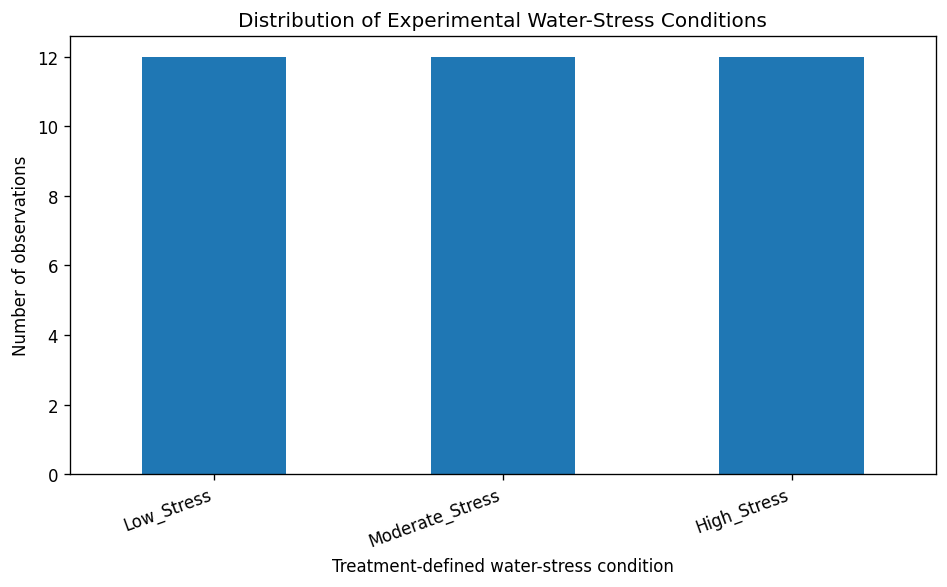

<Figure size 960x600 with 0 Axes>

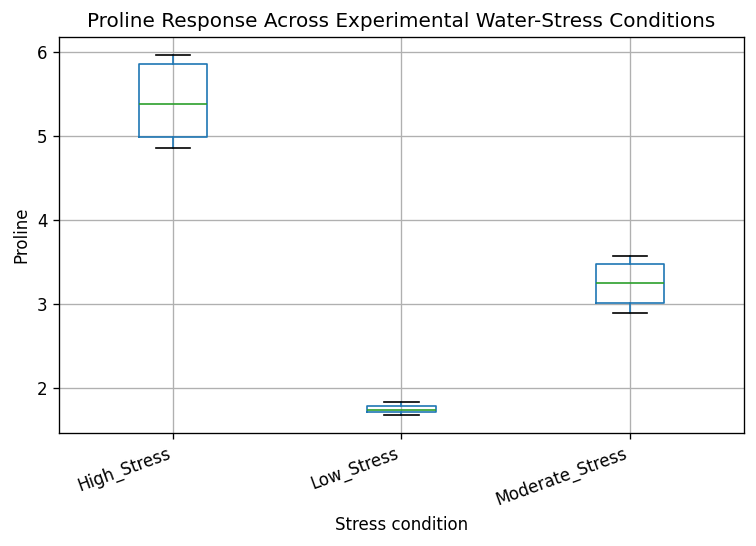


CELL 12 COMPLETED

Dataset: (36, 23)
Target: stress_condition
Target classes: 3
Early-stress features: 7
Full biological features: 15

EARLY_STRESS_FEATURES:
  01. Proline
  02. Leaf_Potassium
  03. TCSA
  04. Trunk_Girth
  05. Initial_Bloom
  06. Final_Bloom
  07. Bloom_Intensity

Output files:
kiwifruit_research_outputs/10_water_stress_target_validation.xlsx
kiwifruit_research_outputs/10_early_stress_ml_dataset.csv
kiwifruit_research_outputs/10_full_biological_ml_dataset.csv
kiwifruit_research_outputs/10_stress_biological_association.csv


SCIENTIFIC NOTE:

The target is derived from the experimentally imposed irrigation
condition and is therefore termed:

    "Treatment-defined water-stress condition"

It should NOT be described as an independently validated
physiological stress label unless an independent stress measurement
or validated threshold is available.

The biological association analysis is exploratory validation of
whether measured variables respond along the experimenta

In [17]:
# ====================================================================================================
# CELL 12 — WATER-STRESS TARGET CONSTRUCTION & VALIDATION
# ====================================================================================================
#
# Scientific definition:
#
#   The available experiment directly provides irrigation conditions (I1, I2, I3),
#   but does not provide an independently validated physiological stress label.
#
#   Therefore, the primary target is defined as:
#
#       Treatment-defined water-stress condition
#
#   NOT:
#
#       Independently validated physiological water-stress severity
#
# This distinction will be maintained throughout ML/XAI analysis.
# ====================================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 110)
print("CELL 12 — WATER-STRESS TARGET CONSTRUCTION & VALIDATION")
print("=" * 110)


# ----------------------------------------------------------------------------------------------------
# 1. Check required dataset
# ----------------------------------------------------------------------------------------------------

if "biological_df" not in globals():

    raise RuntimeError(
        "biological_df was not found. Run CELL 11C first."
    )

df_ml = biological_df.copy()

print("\nInput dataset shape:")
print(df_ml.shape)


# ----------------------------------------------------------------------------------------------------
# 2. Verify irrigation blocks
# ----------------------------------------------------------------------------------------------------

required_blocks = ["I1", "I2", "I3"]

observed_blocks = sorted(
    df_ml["irrigation_block"]
    .dropna()
    .unique()
    .tolist()
)

print("\nObserved irrigation blocks:")
print(observed_blocks)

missing_blocks = [
    x for x in required_blocks
    if x not in observed_blocks
]

if missing_blocks:

    raise ValueError(
        f"Missing irrigation blocks: {missing_blocks}"
    )


# ----------------------------------------------------------------------------------------------------
# 3. IMPORTANT: irrigation-level mapping
# ----------------------------------------------------------------------------------------------------
#
# DO NOT silently assume I1/I2/I3 percentages unless the experimental documentation
# confirms the mapping.
#
# If your experimental protocol confirms:
#
#       I1 = 80% field capacity
#       I2 = 65% field capacity
#       I3 = 50% field capacity
#
# then use the mapping below.
#
# If your original protocol uses a different mapping, CHANGE ONLY this dictionary.
# ----------------------------------------------------------------------------------------------------

IRRIGATION_PERCENT_FC = {

    "I1": 80,
    "I2": 65,
    "I3": 50
}


# ----------------------------------------------------------------------------------------------------
# 4. Verify mapping
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("IRRIGATION CONDITION MAPPING")
print("=" * 110)

for block in required_blocks:

    print(
        f"  {block} → {IRRIGATION_PERCENT_FC[block]}% FC"
    )


# ----------------------------------------------------------------------------------------------------
# 5. Create treatment-defined stress severity
# ----------------------------------------------------------------------------------------------------
#
# Higher water availability = lower water stress.
#
# 80% FC → Low stress
# 65% FC → Moderate stress
# 50% FC → High stress
#
# These are EXPERIMENTAL STRESS CONDITIONS, not independently measured
# physiological stress categories.
# ----------------------------------------------------------------------------------------------------

stress_class_map = {

    "I1": "Low_Stress",
    "I2": "Moderate_Stress",
    "I3": "High_Stress"
}

stress_level_map = {

    "I1": 0,
    "I2": 1,
    "I3": 2
}


df_ml["irrigation_fc"] = (
    df_ml["irrigation_block"]
    .map(IRRIGATION_PERCENT_FC)
)

df_ml["stress_condition"] = (
    df_ml["irrigation_block"]
    .map(stress_class_map)
)

df_ml["stress_severity"] = (
    df_ml["irrigation_block"]
    .map(stress_level_map)
)


# ----------------------------------------------------------------------------------------------------
# 6. Validate target construction
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("TARGET DISTRIBUTION")
print("=" * 110)

target_summary = (

    df_ml
    .groupby(
        [
            "irrigation_block",
            "irrigation_fc",
            "stress_condition",
            "stress_severity"
        ]
    )
    .size()
    .reset_index(
        name="n"
    )
)

display(target_summary)


# ----------------------------------------------------------------------------------------------------
# 7. Check class balance
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("CLASS BALANCE")
print("=" * 110)

class_counts = (
    df_ml["stress_condition"]
    .value_counts()
    .reindex(
        [
            "Low_Stress",
            "Moderate_Stress",
            "High_Stress"
        ]
    )
)

class_percent = (
    class_counts /
    len(df_ml) *
    100
)

class_balance = pd.DataFrame({

    "Stress_Class":
        class_counts.index,

    "Count":
        class_counts.values,

    "Percentage":
        class_percent.round(2).values
})

display(class_balance)


# ----------------------------------------------------------------------------------------------------
# 8. Verify stage × stress structure
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("STRESS CONDITION × PHENOLOGICAL STAGE")
print("=" * 110)

stage_stress_table = pd.crosstab(

    df_ml["phenological_stage"],

    df_ml["stress_condition"]

)

display(
    stage_stress_table
)


# ----------------------------------------------------------------------------------------------------
# 9. Verify replication structure
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("STRESS CONDITION × REPLICATION")
print("=" * 110)

rep_stress_table = pd.crosstab(

    df_ml["replication"],

    df_ml["stress_condition"]

)

display(
    rep_stress_table
)


# ----------------------------------------------------------------------------------------------------
# 10. Biological feature groups
# ----------------------------------------------------------------------------------------------------

physiological_features = [

    "Proline",
    "Leaf_Potassium"
]


growth_features = [

    "TCSA",
    "Trunk_Girth",
    "Initial_Bloom",
    "Final_Bloom",
    "Bloom_Intensity"
]


fruit_yield_features = [

    "Fruit_Weight",
    "Fruit_Length",
    "Fruit_Diameter",
    "Fruit_Shape_LD_Ratio",
    "Yield",
    "Fruit_Count_per_Vine",
    "Yield_Efficiency",
    "Fruit_Volume"
]


# Check which features actually exist
physiological_features = [
    x for x in physiological_features
    if x in df_ml.columns
]

growth_features = [
    x for x in growth_features
    if x in df_ml.columns
]

fruit_yield_features = [
    x for x in fruit_yield_features
    if x in df_ml.columns
]


print("\n" + "=" * 110)
print("BIOLOGICAL FEATURE GROUPS")
print("=" * 110)

print("\nPhysiological / stress-related:")
print(physiological_features)

print("\nGrowth / developmental:")
print(growth_features)

print("\nFruit / yield response:")
print(fruit_yield_features)


# ----------------------------------------------------------------------------------------------------
# 11. Create ML feature sets
# ----------------------------------------------------------------------------------------------------
#
# IMPORTANT:
#
# We create TWO feature sets.
#
# A. EARLY_STRESS_FEATURES
#    Physiological + developmental variables that are more defensible
#    for stress-response modeling.
#
# B. FULL_BIOLOGICAL_FEATURES
#    Includes fruit/yield outcomes and is useful for retrospective
#    treatment-response classification.
#
# The final paper should clearly distinguish these analyses.
# ----------------------------------------------------------------------------------------------------

EARLY_STRESS_FEATURES = (
    physiological_features +
    growth_features
)

FULL_BIOLOGICAL_FEATURES = (
    physiological_features +
    growth_features +
    fruit_yield_features
)


print("\n" + "=" * 110)
print("ML FEATURE SETS")
print("=" * 110)

print(
    "\nEARLY_STRESS_FEATURES:",
    EARLY_STRESS_FEATURES
)

print(
    "\nFULL_BIOLOGICAL_FEATURES:",
    FULL_BIOLOGICAL_FEATURES
)


# ----------------------------------------------------------------------------------------------------
# 12. Explicitly exclude experimental metadata
# ----------------------------------------------------------------------------------------------------

EXCLUDED_METADATA = [

    "irrigation_block",
    "irrigation_fc",
    "phenological_stage",
    "replication",
    "experimental_condition",
    "stress_condition",
    "stress_severity"
]


print("\n" + "=" * 110)
print("TARGET / METADATA SEPARATION")
print("=" * 110)

print("\nTarget:")
print("  stress_condition")

print("\nTarget severity:")
print("  stress_severity")

print("\nExcluded from X:")
for c in EXCLUDED_METADATA:
    print(f"  ✗ {c}")


# ----------------------------------------------------------------------------------------------------
# 13. Build ML datasets
# ----------------------------------------------------------------------------------------------------

X_early = df_ml[
    EARLY_STRESS_FEATURES
].copy()

X_full = df_ml[
    FULL_BIOLOGICAL_FEATURES
].copy()

y_stress = df_ml[
    "stress_condition"
].copy()

y_severity = df_ml[
    "stress_severity"
].copy()


# ----------------------------------------------------------------------------------------------------
# 14. Check missing values
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("ML DATA QUALITY")
print("=" * 110)

print(
    "\nEarly-stress feature missing values:",
    int(X_early.isna().sum().sum())
)

print(
    "Full biological feature missing values:",
    int(X_full.isna().sum().sum())
)

print(
    "Target missing values:",
    int(y_stress.isna().sum())
)


# ----------------------------------------------------------------------------------------------------
# 15. Examine physiological response by stress condition
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("PHYSIOLOGICAL RESPONSE BY STRESS CONDITION")
print("=" * 110)

if len(physiological_features) > 0:

    physiological_summary = (

        df_ml
        .groupby("stress_condition")[
            physiological_features
        ]
        .agg(
            ["mean", "std"]
        )
        .round(4)
    )

    display(
        physiological_summary
    )

else:

    print(
        "No physiological variables available."
    )


# ----------------------------------------------------------------------------------------------------
# 16. Spearman association with ordered stress severity
# ----------------------------------------------------------------------------------------------------
#
# This is exploratory validation only.
#
# It does NOT create the target.
# It checks whether biological variables show monotonic association
# with the experimentally imposed stress gradient.
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("EXPLORATORY BIOLOGICAL VALIDATION")
print("=" * 110)

association_results = []

for feature in FULL_BIOLOGICAL_FEATURES:

    temp = df_ml[
        [
            feature,
            "stress_severity"
        ]
    ].dropna()

    if len(temp) >= 3:

        rho = temp[feature].corr(
            temp["stress_severity"],
            method="spearman"
        )

        association_results.append({

            "Feature":
                feature,

            "Spearman_Rho":
                round(rho, 4),

            "Absolute_Rho":
                round(abs(rho), 4),

            "N":
                len(temp)
        })


association_df = pd.DataFrame(
    association_results
).sort_values(
    "Absolute_Rho",
    ascending=False
)


display(
    association_df
)


# ----------------------------------------------------------------------------------------------------
# 17. Plot stress-condition distribution
# ----------------------------------------------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

class_counts.plot(
    kind="bar"
)

plt.xlabel(
    "Treatment-defined water-stress condition"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    "Distribution of Experimental Water-Stress Conditions"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()


# ----------------------------------------------------------------------------------------------------
# 18. Plot Proline response if available
# ----------------------------------------------------------------------------------------------------

if "Proline" in df_ml.columns:

    plt.figure(
        figsize=(8, 5)
    )

    df_ml.boxplot(
        column="Proline",
        by="stress_condition"
    )

    plt.suptitle("")

    plt.title(
        "Proline Response Across Experimental Water-Stress Conditions"
    )

    plt.xlabel(
        "Stress condition"
    )

    plt.ylabel(
        "Proline"
    )

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.tight_layout()

    plt.show()


# ----------------------------------------------------------------------------------------------------
# 19. Create final ML dataframe
# ----------------------------------------------------------------------------------------------------

ml_stress_df = X_early.copy()

ml_stress_df["stress_condition"] = y_stress.values

ml_stress_df["stress_severity"] = y_severity.values

ml_stress_df["irrigation_block"] = (
    df_ml["irrigation_block"].values
)

ml_stress_df["irrigation_fc"] = (
    df_ml["irrigation_fc"].values
)

ml_stress_df["phenological_stage"] = (
    df_ml["phenological_stage"].values
)

ml_stress_df["replication"] = (
    df_ml["replication"].values
)


# ----------------------------------------------------------------------------------------------------
# 20. Save outputs
# ----------------------------------------------------------------------------------------------------

output_dir = (
    "kiwifruit_research_outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


target_output = os.path.join(
    output_dir,
    "10_water_stress_target_validation.xlsx"
)

early_output = os.path.join(
    output_dir,
    "10_early_stress_ml_dataset.csv"
)

full_output = os.path.join(
    output_dir,
    "10_full_biological_ml_dataset.csv"
)

association_output = os.path.join(
    output_dir,
    "10_stress_biological_association.csv"
)


with pd.ExcelWriter(
    target_output,
    engine="openpyxl"
) as writer:

    target_summary.to_excel(
        writer,
        sheet_name="Target_Summary",
        index=False
    )

    class_balance.to_excel(
        writer,
        sheet_name="Class_Balance",
        index=False
    )

    stage_stress_table.to_excel(
        writer,
        sheet_name="Stage_Stress"
    )

    rep_stress_table.to_excel(
        writer,
        sheet_name="Replication_Stress"
    )

    association_df.to_excel(
        writer,
        sheet_name="Biological_Association",
        index=False
    )

    df_ml.to_excel(
        writer,
        sheet_name="Complete_Targeted_Data",
        index=False
    )


ml_stress_df.to_csv(
    early_output,
    index=False
)

X_full.assign(
    stress_condition=y_stress.values,
    stress_severity=y_severity.values,
    irrigation_block=df_ml["irrigation_block"].values,
    phenological_stage=df_ml["phenological_stage"].values,
    replication=df_ml["replication"].values
).to_csv(
    full_output,
    index=False
)

association_df.to_csv(
    association_output,
    index=False
)


# ----------------------------------------------------------------------------------------------------
# 21. Final report
# ----------------------------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("CELL 12 COMPLETED")
print("=" * 110)

print(
    "\nDataset:",
    df_ml.shape
)

print(
    "Target:",
    "stress_condition"
)

print(
    "Target classes:",
    y_stress.nunique()
)

print(
    "Early-stress features:",
    len(EARLY_STRESS_FEATURES)
)

print(
    "Full biological features:",
    len(FULL_BIOLOGICAL_FEATURES)
)

print(
    "\nEARLY_STRESS_FEATURES:"
)

for i, feature in enumerate(
    EARLY_STRESS_FEATURES,
    1
):

    print(
        f"  {i:02d}. {feature}"
    )


print("\nOutput files:")

print(
    target_output
)

print(
    early_output
)

print(
    full_output
)

print(
    association_output
)

print("\n" + "=" * 110)

print("""
SCIENTIFIC NOTE:

The target is derived from the experimentally imposed irrigation
condition and is therefore termed:

    "Treatment-defined water-stress condition"

It should NOT be described as an independently validated
physiological stress label unless an independent stress measurement
or validated threshold is available.

The biological association analysis is exploratory validation of
whether measured variables respond along the experimental
irrigation gradient.

NEXT:
    CELL 13 — ML MODEL TRAINING & BASELINE EVALUATION
""")

print("=" * 110)

CELL 13 — ML MODEL TRAINING & BASELINE EVALUATION

Using existing early_ml_df from Cell 12.

Input dataset shape:
(36, 13)

Input columns:
  01. Proline
  02. Leaf_Potassium
  03. TCSA
  04. Trunk_Girth
  05. Initial_Bloom
  06. Final_Bloom
  07. Bloom_Intensity
  08. stress_condition
  09. stress_severity
  10. irrigation_block
  11. irrigation_fc
  12. phenological_stage
  13. replication

TARGET DEFINITION

Target variable: stress_condition

FEATURE SETS

PRIMARY PHYSIOLOGICAL FEATURE SET:
  01. Proline
  02. Leaf_Potassium

EXPANDED EARLY BIOLOGICAL FEATURE SET:
  01. Proline
  02. Leaf_Potassium
  03. TCSA
  04. Trunk_Girth
  05. Initial_Bloom
  06. Final_Bloom
  07. Bloom_Intensity

TARGET DISTRIBUTION


,Stress_Class,Count,Percentage
0,Low_Stress,12,33.33
1,Moderate_Stress,12,33.33
2,High_Stress,12,33.33



DATA QUALITY CHECK

Dataset observations: 36
Physiological feature missing values: 0
Expanded feature missing values: 0
Target missing values: 0

PHYSIOLOGICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
Proline,36.0,3.4714,1.5498,1.68,1.7975,3.245,4.9750,5.96
Leaf_Potassium,36.0,2.3619,0.0640,2.25,2.3050,2.360,2.4225,2.46



CROSS-VALIDATION DESIGN

PERFORMANCE ESTIMATION
  • 5-fold Stratified Cross-Validation
  • 10 repeats
  • 50 validation evaluations
  • Random state = 42

OOF PREDICTIONS
  • Separate 5-fold Stratified partition
  • Random state = 42

MODEL EVALUATION — Physiological

Running: Logistic Regression
  Repeated CV Balanced Accuracy: 1.0000 ± 0.0000
  Repeated CV Macro-F1: 1.0000 ± 0.0000
  Repeated CV MCC: 1.0000 ± 0.0000
  5-fold OOF Balanced Accuracy: 1.0000
  5-fold OOF Macro-F1: 1.0000
  5-fold OOF MCC: 1.0000

Running: LDA
  Repeated CV Balanced Accuracy: 1.0000 ± 0.0000
  Repeated CV Macro-F1: 1.0000 ± 0.0000
  Repeated CV MCC: 1.0000 ± 0.0000
  5-fold OOF Balanced Accuracy: 1.0000
  5-fold OOF Macro-F1: 1.0000
  5-fold OOF MCC: 1.0000

Running: Random Forest
  Repeated CV Balanced Accuracy: 1.0000 ± 0.0000
  Repeated CV Macro-F1: 1.0000 ± 0.0000
  Repeated CV MCC: 1.0000 ± 0.0000
  5-fold OOF Balanced Accuracy: 1.0000
  5-fold OOF Macro-F1: 1.0000
  5-fold OOF MCC: 1.0000

Running:

...


PHYSIOLOGICAL FEATURES — MODEL RANKING


,Dataset,Model,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,Macro_F1_Mean,Macro_F1_SD,MCC_Mean,MCC_SD
0,Physiological,Logistic Regression,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,Physiological,LDA,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,Physiological,Random Forest,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,Physiological,Extra Trees,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,Physiological,SVM-RBF,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0



EXPANDED EARLY BIOLOGICAL FEATURES — MODEL RANKING


,Dataset,Model,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,Macro_F1_Mean,Macro_F1_SD,MCC_Mean,MCC_SD
0,Expanded_Early_Biological,Logistic Regression,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,Expanded_Early_Biological,LDA,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,Expanded_Early_Biological,Random Forest,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,Expanded_Early_Biological,Extra Trees,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,Expanded_Early_Biological,SVM-RBF,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0



DUMMY / CHANCE BASELINE
Dummy Balanced Accuracy: 0.2556 ± 0.2347
Dummy Macro-F1: 0.2533
Dummy MCC: -0.1467

BEST CROSS-VALIDATED MODEL
Dataset: Physiological
Model: Logistic Regression
Balanced Accuracy: 1.0000 ± 0.0000
Macro-F1: 1.0000 ± 0.0000
MCC: 1.0000 ± 0.0000

BEST PHYSIOLOGICAL MODEL — 5-FOLD OOF CLASSIFICATION REPORT

Model: Logistic Regression
                 precision    recall  f1-score   support

     Low_Stress       1.00      1.00      1.00        12
Moderate_Stress       1.00      1.00      1.00        12
    High_Stress       1.00      1.00      1.00        12

       accuracy                           1.00        36
      macro avg       1.00      1.00      1.00        36
   weighted avg       1.00      1.00      1.00        36


PHYSIOLOGICAL MODEL CONFUSION MATRICES


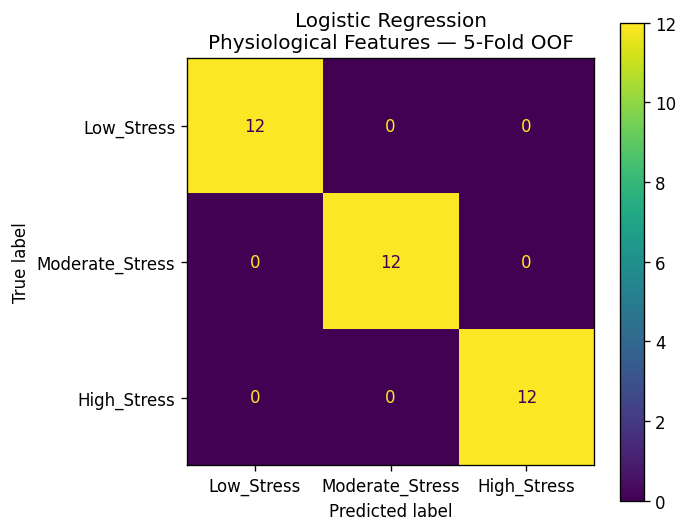

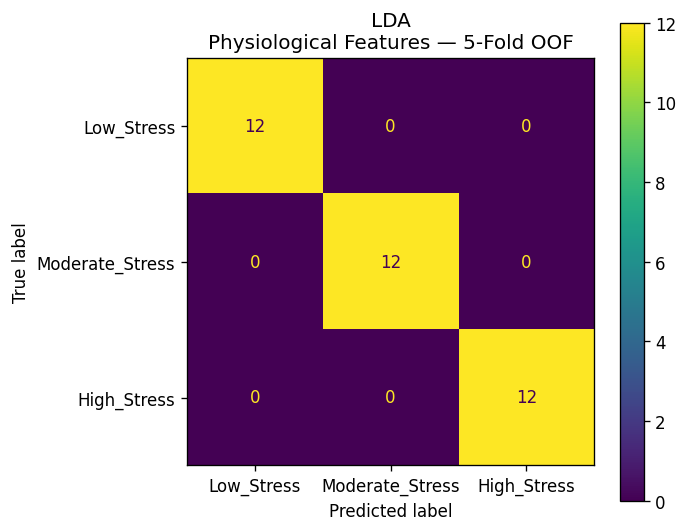

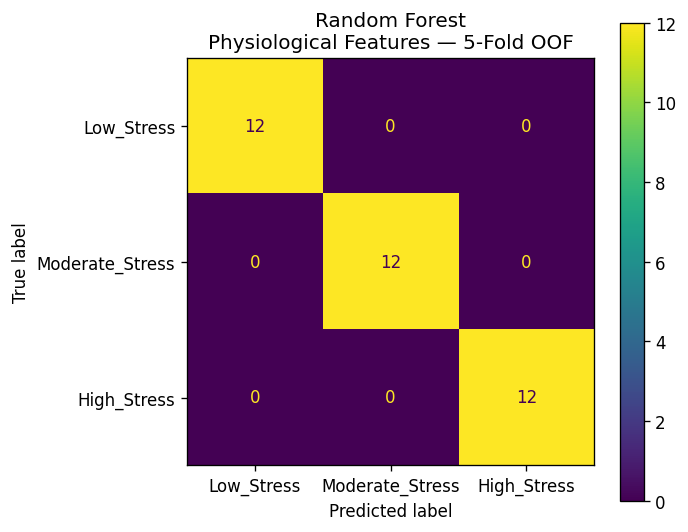

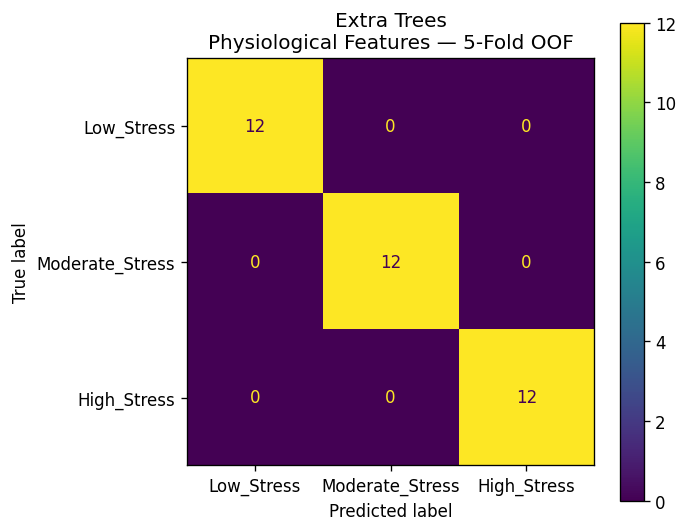

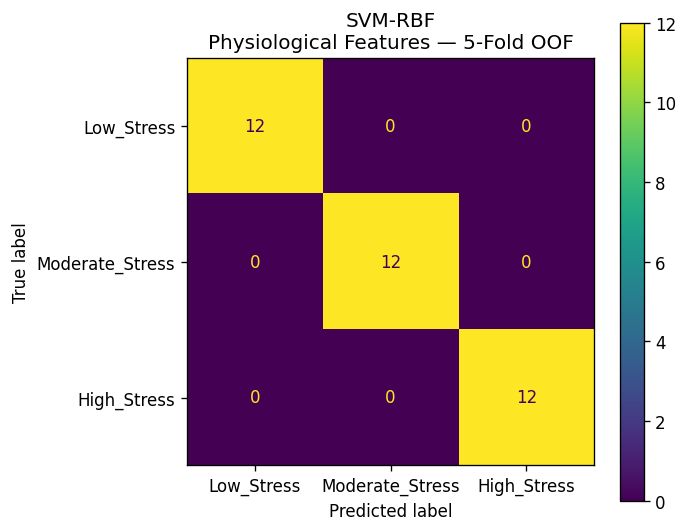


BEST PHYSIOLOGICAL MODEL — CONFUSION MATRIX


,Predicted_Low_Stress,Predicted_Moderate_Stress,Predicted_High_Stress
Actual_Low_Stress,12,0,0
Actual_Moderate_Stress,0,12,0
Actual_High_Stress,0,0,12



CELL 13 COMPLETED

Dataset size: 36
Number of classes: 3

Target:
  • Treatment-defined water-stress condition

Class distribution:
  • Low_Stress: 12 observations
  • Moderate_Stress: 12 observations
  • High_Stress: 12 observations

Primary physiological features:
  • Proline
  • Leaf_Potassium

Expanded early biological features:
  • Proline
  • Leaf_Potassium
  • TCSA
  • Trunk_Girth
  • Initial_Bloom
  • Final_Bloom
  • Bloom_Intensity

Performance estimation:
  • 5-fold Stratified CV
  • 10 repeats
  • 50 validation evaluations

OOF prediction strategy:
  • Separate 5-fold Stratified partition

BEST OVERALL MODEL:
  • Dataset: Physiological
  • Model: Logistic Regression
  • Balanced Accuracy: 1.0000 ± 0.0000
  • Macro-F1: 1.0000 ± 0.0000
  • MCC: 1.0000 ± 0.0000

BEST PHYSIOLOGICAL MODEL:
  • Logistic Regression

Output files:
  • kiwifruit_research_outputs/11_cell13_ml_model_comparison.xlsx
  • kiwifruit_research_outputs/11_cell13_best_physiological_oof_predictions.csv
  • kiw

In [23]:
# ==================================================================================================
# CELL 13 — ML MODEL TRAINING & BASELINE EVALUATION
# ==================================================================================================
# Purpose:
#   1. Train multiple ML models for treatment-defined water-stress classification
#   2. Compare physiological-only vs expanded early biological features
#   3. Use repeated stratified cross-validation for robust performance estimation
#   4. Generate independent 5-fold out-of-fold (OOF) predictions
#   5. Compare models using Accuracy, Balanced Accuracy, Macro-F1 and MCC
#   6. Generate confusion matrices
#   7. Save all results for Cell 14 and Cell 15
#
# IMPORTANT SCIENTIFIC NOTE:
#   Target = experimentally imposed / treatment-defined water-stress condition.
#   It is NOT an independently validated physiological stress diagnosis.
#
# Dataset:
#   n = 36 observations
#   3 classes
#   12 observations per class
# ==================================================================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.dummy import DummyClassifier


# ==================================================================================================
# 1. OUTPUT DIRECTORY
# ==================================================================================================

if "OUTPUT_DIR" not in globals():

    OUTPUT_DIR = "kiwifruit_research_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ==================================================================================================
# 2. HEADER
# ==================================================================================================

print("=" * 100)
print("CELL 13 — ML MODEL TRAINING & BASELINE EVALUATION")
print("=" * 100)


# ==================================================================================================
# 3. LOAD CELL 12 DATASET
# ==================================================================================================

if "early_ml_df" in globals():

    print("\nUsing existing early_ml_df from Cell 12.")

else:

    early_csv = os.path.join(
        OUTPUT_DIR,
        "10_early_stress_ml_dataset.csv"
    )

    if not os.path.exists(early_csv):

        raise FileNotFoundError(
            "\nCell 12 dataset was not found.\n\n"
            f"Expected file:\n{early_csv}\n\n"
            "Please run Cell 12 again."
        )

    early_ml_df = pd.read_csv(
        early_csv
    )

    print(
        "\nCell 12 dataset loaded automatically:"
    )

    print(
        early_csv
    )


print("\nInput dataset shape:")
print(
    early_ml_df.shape
)


print("\nInput columns:")

for i, col in enumerate(
    early_ml_df.columns,
    1
):

    print(
        f"  {i:02d}. {col}"
    )


# ==================================================================================================
# 4. TARGET DEFINITION
# ==================================================================================================

TARGET = "stress_condition"


if TARGET not in early_ml_df.columns:

    raise ValueError(
        f"\nTarget column '{TARGET}' was not found."
    )


print("\n" + "=" * 100)
print("TARGET DEFINITION")
print("=" * 100)

print(
    f"\nTarget variable: {TARGET}"
)


# ==================================================================================================
# 5. FEATURE GROUPS
# ==================================================================================================

# ------------------------------------------------------------------
# Primary physiological variables
# ------------------------------------------------------------------

PHYSIOLOGICAL_STRESS_FEATURES = [

    "Proline",

    "Leaf_Potassium"

]


# ------------------------------------------------------------------
# Expanded early biological variables
# ------------------------------------------------------------------

EARLY_FEATURES = [

    "Proline",

    "Leaf_Potassium",

    "TCSA",

    "Trunk_Girth",

    "Initial_Bloom",

    "Final_Bloom",

    "Bloom_Intensity"

]


# ==================================================================================================
# 6. FEATURE VALIDATION
# ==================================================================================================

all_required_features = list(
    dict.fromkeys(
        PHYSIOLOGICAL_STRESS_FEATURES
        +
        EARLY_FEATURES
    )
)


missing_features = [

    feature

    for feature in all_required_features

    if feature not in early_ml_df.columns

]


if missing_features:

    raise ValueError(
        "\nThe following required features are missing:\n"
        +
        "\n".join(
            f"  • {x}"
            for x in missing_features
        )
    )


# ==================================================================================================
# 7. CREATE X AND y
# ==================================================================================================

X_physiological = (

    early_ml_df[
        PHYSIOLOGICAL_STRESS_FEATURES
    ]

    .copy()

)


X_early = (

    early_ml_df[
        EARLY_FEATURES
    ]

    .copy()

)


y = (

    early_ml_df[
        TARGET
    ]

    .astype(str)

    .copy()

)


# ==================================================================================================
# 8. FEATURE INFORMATION
# ==================================================================================================

print("\n" + "=" * 100)
print("FEATURE SETS")
print("=" * 100)


print("\nPRIMARY PHYSIOLOGICAL FEATURE SET:")

for i, feature in enumerate(
    PHYSIOLOGICAL_STRESS_FEATURES,
    1
):

    print(
        f"  {i:02d}. {feature}"
    )


print("\nEXPANDED EARLY BIOLOGICAL FEATURE SET:")

for i, feature in enumerate(
    EARLY_FEATURES,
    1
):

    print(
        f"  {i:02d}. {feature}"
    )


# ==================================================================================================
# 9. TARGET CLASS ORDER
# ==================================================================================================

class_order = [

    "Low_Stress",

    "Moderate_Stress",

    "High_Stress"

]


unknown_classes = (

    set(
        y.unique()
    )

    -

    set(
        class_order
    )

)


if unknown_classes:

    raise ValueError(
        f"Unexpected target classes: {unknown_classes}"
    )


# ==================================================================================================
# 10. TARGET DISTRIBUTION
# ==================================================================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)


target_distribution = (

    y

    .value_counts()

    .reindex(
        class_order,
        fill_value=0
    )

)


target_percentage = (

    target_distribution

    /

    len(y)

    *

    100

)


target_summary = pd.DataFrame({

    "Stress_Class":
        class_order,

    "Count":
        target_distribution.values,

    "Percentage":
        target_percentage.values

})


display(
    target_summary.round(2)
)


# ==================================================================================================
# 11. DATA QUALITY
# ==================================================================================================

print("\n" + "=" * 100)
print("DATA QUALITY CHECK")
print("=" * 100)


print(
    "\nDataset observations:",
    len(early_ml_df)
)


print(
    "Physiological feature missing values:",
    X_physiological.isna().sum().sum()
)


print(
    "Expanded feature missing values:",
    X_early.isna().sum().sum()
)


print(
    "Target missing values:",
    y.isna().sum()
)


# ==================================================================================================
# 12. BASIC FEATURE STATISTICS
# ==================================================================================================

print("\n" + "=" * 100)
print("PHYSIOLOGICAL FEATURE SUMMARY")
print("=" * 100)


display(
    X_physiological.describe().T.round(4)
)


# ==================================================================================================
# 13. REPEATED STRATIFIED CROSS-VALIDATION
# ==================================================================================================

# Main performance evaluation
#
# 5 folds × 10 repeats = 50 validation evaluations.
#
# This is suitable for estimating performance with the small
# dataset, while avoiding dependence on a single train/test split.

REPEATED_CV = RepeatedStratifiedKFold(

    n_splits=5,

    n_repeats=10,

    random_state=42

)


# ==================================================================================================
# 14. SEPARATE OOF PARTITION
# ==================================================================================================

# cross_val_predict requires the validation indices to form
# one complete partition.
#
# Therefore we DO NOT use RepeatedStratifiedKFold for OOF
# predictions.

OOF_CV = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


print("\n" + "=" * 100)
print("CROSS-VALIDATION DESIGN")
print("=" * 100)


print("\nPERFORMANCE ESTIMATION")

print(
    "  • 5-fold Stratified Cross-Validation"
)

print(
    "  • 10 repeats"
)

print(
    "  • 50 validation evaluations"
)

print(
    "  • Random state = 42"
)


print("\nOOF PREDICTIONS")

print(
    "  • Separate 5-fold Stratified partition"
)

print(
    "  • Random state = 42"
)


# ==================================================================================================
# 15. MODEL DEFINITIONS
# ==================================================================================================

models = {


    # ==============================================================================================
    # LOGISTIC REGRESSION
    # ==============================================================================================

    "Logistic Regression":

    Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()
        ),

        (
            "model",

            LogisticRegression(

                max_iter=5000,

                multi_class="multinomial",

                C=1.0,

                random_state=42

            )

        )

    ]),


    # ==============================================================================================
    # LINEAR DISCRIMINANT ANALYSIS
    # ==============================================================================================

    "LDA":

    Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()
        ),

        (
            "model",

            LinearDiscriminantAnalysis()

        )

    ]),


    # ==============================================================================================
    # RANDOM FOREST
    # ==============================================================================================

    "Random Forest":

    Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "model",

            RandomForestClassifier(

                n_estimators=300,

                max_depth=3,

                min_samples_leaf=2,

                class_weight="balanced",

                random_state=42,

                n_jobs=-1

            )

        )

    ]),


    # ==============================================================================================
    # EXTRA TREES
    # ==============================================================================================

    "Extra Trees":

    Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "model",

            ExtraTreesClassifier(

                n_estimators=300,

                max_depth=3,

                min_samples_leaf=2,

                class_weight="balanced",

                random_state=42,

                n_jobs=-1

            )

        )

    ]),


    # ==============================================================================================
    # SUPPORT VECTOR MACHINE
    # ==============================================================================================

    "SVM-RBF":

    Pipeline([

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()
        ),

        (
            "model",

            SVC(

                C=1.0,

                kernel="rbf",

                probability=True,

                class_weight="balanced",

                random_state=42

            )

        )

    ])

}


# ==================================================================================================
# 16. SCORING METRICS
# ==================================================================================================

SCORING = {

    "accuracy":
        "accuracy",

    "balanced_accuracy":
        "balanced_accuracy",

    "macro_f1":
        "f1_macro",

    "mcc":
        "matthews_corrcoef"

}


# ==================================================================================================
# 17. MODEL EVALUATION FUNCTION
# ==================================================================================================

def evaluate_models(
    X,
    y,
    dataset_name
):

    results = []

    predictions = {}


    print("\n" + "=" * 100)

    print(
        f"MODEL EVALUATION — {dataset_name}"
    )

    print("=" * 100)


    for model_name, model in models.items():

        print(
            f"\nRunning: {model_name}"
        )


        # ==========================================================================================
        # A. REPEATED CROSS-VALIDATION
        # ==========================================================================================

        cv_scores = cross_validate(

            model,

            X,

            y,

            cv=REPEATED_CV,

            scoring=SCORING,

            n_jobs=-1,

            return_train_score=False

        )


        # ==========================================================================================
        # B. CALCULATE SUMMARY STATISTICS
        # ==========================================================================================

        result = {

            "Dataset":

                dataset_name,


            "Model":

                model_name,


            "Accuracy_Mean":

                np.mean(
                    cv_scores[
                        "test_accuracy"
                    ]
                ),


            "Accuracy_SD":

                np.std(
                    cv_scores[
                        "test_accuracy"
                    ]
                ),


            "Balanced_Accuracy_Mean":

                np.mean(
                    cv_scores[
                        "test_balanced_accuracy"
                    ]
                ),


            "Balanced_Accuracy_SD":

                np.std(
                    cv_scores[
                        "test_balanced_accuracy"
                    ]
                ),


            "Macro_F1_Mean":

                np.mean(
                    cv_scores[
                        "test_macro_f1"
                    ]
                ),


            "Macro_F1_SD":

                np.std(
                    cv_scores[
                        "test_macro_f1"
                    ]
                ),


            "MCC_Mean":

                np.mean(
                    cv_scores[
                        "test_mcc"
                    ]
                ),


            "MCC_SD":

                np.std(
                    cv_scores[
                        "test_mcc"
                    ]
                )

        }


        results.append(
            result
        )


        # ==========================================================================================
        # C. SINGLE 5-FOLD OOF PREDICTIONS
        # ==========================================================================================

        oof_pred = cross_val_predict(

            model,

            X,

            y,

            cv=OOF_CV,

            method="predict",

            n_jobs=-1

        )


        predictions[
            model_name
        ] = oof_pred


        # ==========================================================================================
        # D. OOF PERFORMANCE
        # ==========================================================================================

        oof_balanced_accuracy = (

            balanced_accuracy_score(

                y,

                oof_pred

            )

        )


        oof_macro_f1 = (

            f1_score(

                y,

                oof_pred,

                average="macro"

            )

        )


        oof_mcc = (

            matthews_corrcoef(

                y,

                oof_pred

            )

        )


        print(

            "  Repeated CV Balanced Accuracy: "

            f"{result['Balanced_Accuracy_Mean']:.4f}"

            " ± "

            f"{result['Balanced_Accuracy_SD']:.4f}"

        )


        print(

            "  Repeated CV Macro-F1: "

            f"{result['Macro_F1_Mean']:.4f}"

            " ± "

            f"{result['Macro_F1_SD']:.4f}"

        )


        print(

            "  Repeated CV MCC: "

            f"{result['MCC_Mean']:.4f}"

            " ± "

            f"{result['MCC_SD']:.4f}"

        )


        print(

            "  5-fold OOF Balanced Accuracy: "

            f"{oof_balanced_accuracy:.4f}"

        )


        print(

            "  5-fold OOF Macro-F1: "

            f"{oof_macro_f1:.4f}"

        )


        print(

            "  5-fold OOF MCC: "

            f"{oof_mcc:.4f}"

        )


    return (

        pd.DataFrame(
            results
        ),

        predictions

    )


# ==================================================================================================
# 18. PRIMARY PHYSIOLOGICAL MODELS
# ==================================================================================================

phys_results, phys_predictions = evaluate_models(

    X_physiological,

    y,

    "Physiological"

)


# ==================================================================================================
# 19. EXPANDED EARLY BIOLOGICAL MODELS
# ==================================================================================================

early_results, early_predictions = evaluate_models(

    X_early,

    y,

    "Expanded_Early_Biological"

)


# ==================================================================================================
# 20. COMBINE MODEL RESULTS
# ==================================================================================================

model_results = pd.concat(

    [

        phys_results,

        early_results

    ],

    ignore_index=True

)


model_results = (

    model_results

    .sort_values(

        by="Balanced_Accuracy_Mean",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 100)


display(
    model_results.round(4)
)


# ==================================================================================================
# 21. PHYSIOLOGICAL MODEL SUMMARY
# ==================================================================================================

print("\n" + "=" * 100)
print("PHYSIOLOGICAL FEATURES — MODEL RANKING")
print("=" * 100)


phys_ranking = (

    phys_results

    .sort_values(

        "Balanced_Accuracy_Mean",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


display(
    phys_ranking.round(4)
)


# ==================================================================================================
# 22. EXPANDED MODEL SUMMARY
# ==================================================================================================

print("\n" + "=" * 100)
print("EXPANDED EARLY BIOLOGICAL FEATURES — MODEL RANKING")
print("=" * 100)


early_ranking = (

    early_results

    .sort_values(

        "Balanced_Accuracy_Mean",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


display(
    early_ranking.round(4)
)


# ==================================================================================================
# 23. DUMMY BASELINE
# ==================================================================================================

print("\n" + "=" * 100)
print("DUMMY / CHANCE BASELINE")
print("=" * 100)


dummy = DummyClassifier(

    strategy="stratified",

    random_state=42

)


dummy_scores = cross_validate(

    dummy,

    X_physiological,

    y,

    cv=REPEATED_CV,

    scoring=SCORING,

    n_jobs=-1

)


dummy_balanced_accuracy = np.mean(

    dummy_scores[
        "test_balanced_accuracy"
    ]

)


dummy_balanced_accuracy_sd = np.std(

    dummy_scores[
        "test_balanced_accuracy"
    ]

)


dummy_macro_f1 = np.mean(

    dummy_scores[
        "test_macro_f1"
    ]

)


dummy_mcc = np.mean(

    dummy_scores[
        "test_mcc"
    ]

)


print(

    "Dummy Balanced Accuracy: "

    f"{dummy_balanced_accuracy:.4f}"

    " ± "

    f"{dummy_balanced_accuracy_sd:.4f}"

)


print(

    "Dummy Macro-F1: "

    f"{dummy_macro_f1:.4f}"

)


print(

    "Dummy MCC: "

    f"{dummy_mcc:.4f}"

)


# ==================================================================================================
# 24. BEST OVERALL MODEL
# ==================================================================================================

best_row = (

    model_results

    .iloc[0]

)


BEST_MODEL_NAME = (

    best_row[
        "Model"
    ]

)


BEST_DATASET = (

    best_row[
        "Dataset"
    ]

)


print("\n" + "=" * 100)
print("BEST CROSS-VALIDATED MODEL")
print("=" * 100)


print(
    f"Dataset: {BEST_DATASET}"
)


print(
    f"Model: {BEST_MODEL_NAME}"
)


print(

    "Balanced Accuracy: "

    f"{best_row['Balanced_Accuracy_Mean']:.4f}"

    " ± "

    f"{best_row['Balanced_Accuracy_SD']:.4f}"

)


print(

    "Macro-F1: "

    f"{best_row['Macro_F1_Mean']:.4f}"

    " ± "

    f"{best_row['Macro_F1_SD']:.4f}"

)


print(

    "MCC: "

    f"{best_row['MCC_Mean']:.4f}"

    " ± "

    f"{best_row['MCC_SD']:.4f}"

)


# ==================================================================================================
# 25. BEST PHYSIOLOGICAL MODEL
# ==================================================================================================

best_phys_row = (

    phys_results

    .sort_values(

        "Balanced_Accuracy_Mean",

        ascending=False

    )

    .iloc[0]

)


BEST_PHYSIOLOGICAL_MODEL = (

    best_phys_row[
        "Model"
    ]

)


best_phys_pred = (

    phys_predictions[
        BEST_PHYSIOLOGICAL_MODEL
    ]

)


# ==================================================================================================
# 26. BEST PHYSIOLOGICAL MODEL — OOF REPORT
# ==================================================================================================

print("\n" + "=" * 100)
print("BEST PHYSIOLOGICAL MODEL — 5-FOLD OOF CLASSIFICATION REPORT")
print("=" * 100)


print(
    f"\nModel: {BEST_PHYSIOLOGICAL_MODEL}"
)


print(

    classification_report(

        y,

        best_phys_pred,

        labels=class_order,

        zero_division=0

    )

)


# ==================================================================================================
# 27. CONFUSION MATRICES — PHYSIOLOGICAL MODELS
# ==================================================================================================

figures_dir = os.path.join(

    OUTPUT_DIR,

    "cell13_figures"

)


os.makedirs(

    figures_dir,

    exist_ok=True

)


print("\n" + "=" * 100)
print("PHYSIOLOGICAL MODEL CONFUSION MATRICES")
print("=" * 100)


for model_name, y_pred in phys_predictions.items():


    cm = confusion_matrix(

        y,

        y_pred,

        labels=class_order

    )


    fig, ax = plt.subplots(

        figsize=(6, 5)

    )


    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=class_order

    )


    disp.plot(

        ax=ax,

        values_format="d"

    )


    ax.set_title(

        f"{model_name}\n"
        "Physiological Features — 5-Fold OOF"

    )


    plt.tight_layout()


    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_"
        )

        .replace(
            "-",
            "_"
        )

    )


    figure_path = os.path.join(

        figures_dir,

        f"confusion_matrix_{safe_name}_physiological.png"

    )


    fig.savefig(

        figure_path,

        dpi=300,

        bbox_inches="tight"

    )


    plt.show()


# ==================================================================================================
# 28. OOF PREDICTION DATASET
# ==================================================================================================

metadata_columns = [

    "record_id",

    "irrigation_block",

    "irrigation_fc",

    "phenological_stage",

    "replication",

    TARGET

]


metadata_columns = [

    column

    for column in metadata_columns

    if column in early_ml_df.columns

]


oof_physiological_df = (

    early_ml_df[
        metadata_columns
    ]

    .copy()

)


oof_physiological_df[
    "Predicted_Stress"
] = best_phys_pred


oof_physiological_df[
    "Correct"
] = (

    oof_physiological_df[
        TARGET
    ].astype(str)

    ==

    oof_physiological_df[
        "Predicted_Stress"
    ].astype(str)

)


# ==================================================================================================
# 29. ADD ALL PHYSIOLOGICAL OOF PREDICTIONS
# ==================================================================================================

phys_pred_df = (

    early_ml_df.copy()

)


for model_name, pred in phys_predictions.items():

    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_"
        )

        .replace(
            "-",
            "_"
        )

    )


    phys_pred_df[
        f"OOF_{safe_name}"
    ] = pred


# ==================================================================================================
# 30. OOF CONFUSION MATRIX TABLE
# ==================================================================================================

best_phys_cm = confusion_matrix(

    y,

    best_phys_pred,

    labels=class_order

)


best_phys_cm_df = pd.DataFrame(

    best_phys_cm,

    index=[
        f"Actual_{x}"
        for x in class_order
    ],

    columns=[
        f"Predicted_{x}"
        for x in class_order
    ]

)


print("\n" + "=" * 100)
print("BEST PHYSIOLOGICAL MODEL — CONFUSION MATRIX")
print("=" * 100)


display(
    best_phys_cm_df
)


# ==================================================================================================
# 31. SAVE MODEL RESULTS
# ==================================================================================================

results_path = os.path.join(

    OUTPUT_DIR,

    "11_cell13_ml_model_comparison.xlsx"

)


oof_path = os.path.join(

    OUTPUT_DIR,

    "11_cell13_best_physiological_oof_predictions.csv"

)


all_oof_path = os.path.join(

    OUTPUT_DIR,

    "11_cell13_all_physiological_oof_predictions.csv"

)


confusion_path = os.path.join(

    OUTPUT_DIR,

    "11_cell13_best_physiological_confusion_matrix.csv"

)


# ------------------------------------------------------------------
# Excel workbook
# ------------------------------------------------------------------

with pd.ExcelWriter(
    results_path,
    engine="openpyxl"
) as writer:

    model_results.to_excel(

        writer,

        sheet_name="All_Model_Results",

        index=False

    )


    phys_ranking.to_excel(

        writer,

        sheet_name="Physiological_Models",

        index=False

    )


    early_ranking.to_excel(

        writer,

        sheet_name="Expanded_Early_Models",

        index=False

    )


    target_summary.to_excel(

        writer,

        sheet_name="Target_Distribution",

        index=False

    )


    best_phys_cm_df.to_excel(

        writer,

        sheet_name="Best_Confusion_Matrix"

    )


# ------------------------------------------------------------------
# CSV files
# ------------------------------------------------------------------

oof_physiological_df.to_csv(

    oof_path,

    index=False

)


phys_pred_df.to_csv(

    all_oof_path,

    index=False

)


best_phys_cm_df.to_csv(

    confusion_path

)


# ==================================================================================================
# 32. BEST MODEL FEATURE SET
# ==================================================================================================

if BEST_DATASET == "Physiological":

    BEST_FEATURES = (
        PHYSIOLOGICAL_STRESS_FEATURES.copy()
    )

else:

    BEST_FEATURES = (
        EARLY_FEATURES.copy()
    )


# ==================================================================================================
# 33. FINAL SUMMARY
# ==================================================================================================

print("\n" + "=" * 100)
print("CELL 13 COMPLETED")
print("=" * 100)


print(
    f"\nDataset size: {len(y)}"
)


print(
    f"Number of classes: {len(class_order)}"
)


print(
    "\nTarget:"
)

print(
    "  • Treatment-defined water-stress condition"
)


print(
    "\nClass distribution:"
)

for cls in class_order:

    print(
        f"  • {cls}: "
        f"{target_distribution[cls]} observations"
    )


print(
    "\nPrimary physiological features:"
)

for feature in PHYSIOLOGICAL_STRESS_FEATURES:

    print(
        f"  • {feature}"
    )


print(
    "\nExpanded early biological features:"
)

for feature in EARLY_FEATURES:

    print(
        f"  • {feature}"
    )


print(
    "\nPerformance estimation:"
)

print(
    "  • 5-fold Stratified CV"
)

print(
    "  • 10 repeats"
)

print(
    "  • 50 validation evaluations"
)


print(
    "\nOOF prediction strategy:"
)

print(
    "  • Separate 5-fold Stratified partition"
)


print(
    "\nBEST OVERALL MODEL:"
)

print(
    f"  • Dataset: {BEST_DATASET}"
)

print(
    f"  • Model: {BEST_MODEL_NAME}"
)

print(

    "  • Balanced Accuracy: "

    f"{best_row['Balanced_Accuracy_Mean']:.4f}"

    " ± "

    f"{best_row['Balanced_Accuracy_SD']:.4f}"

)


print(

    "  • Macro-F1: "

    f"{best_row['Macro_F1_Mean']:.4f}"

    " ± "

    f"{best_row['Macro_F1_SD']:.4f}"

)


print(

    "  • MCC: "

    f"{best_row['MCC_Mean']:.4f}"

    " ± "

    f"{best_row['MCC_SD']:.4f}"

)


print(
    "\nBEST PHYSIOLOGICAL MODEL:"
)

print(
    f"  • {BEST_PHYSIOLOGICAL_MODEL}"
)


print(
    "\nOutput files:"
)

print(
    f"  • {results_path}"
)

print(
    f"  • {oof_path}"
)

print(
    f"  • {all_oof_path}"
)

print(
    f"  • {confusion_path}"
)

print(
    f"  • {figures_dir}/"
)


print("\n" + "=" * 100)
print("SCIENTIFIC INTERPRETATION")
print("=" * 100)


print(
    """
The target represents the experimentally imposed,
treatment-defined water-stress condition.

Therefore, model performance represents classification
of the experimental irrigation condition.

It should NOT yet be described as an independently
validated physiological stress diagnosis.

The physiological-only model is particularly important
because it evaluates whether Proline and Leaf_Potassium
contain predictive information without using downstream
fruit/yield variables.
"""
)


print("\nNEXT:")
print(
    "CELL 14 — MODEL OPTIMIZATION & ROBUSTNESS ANALYSIS"
)


print("=" * 100)

Using early_ml_df already loaded in memory.

Dataset shape: (36, 13)

Available biological features:
['Proline', 'Leaf_Potassium', 'TCSA', 'Trunk_Girth', 'Initial_Bloom', 'Final_Bloom', 'Bloom_Intensity']

Target distribution:
stress_condition
Low_Stress         12
Moderate_Stress    12
High_Stress        12
Name: count, dtype: int64

Missing values:
Proline            0
Leaf_Potassium     0
TCSA               0
Trunk_Girth        0
Initial_Bloom      0
Final_Bloom        0
Bloom_Intensity    0
dtype: int64

Duplicate rows: 0

FEATURE-SET ROBUSTNESS


,Feature_Set,N_Features,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,Macro_F1_Mean,Macro_F1_SD,MCC_Mean,MCC_SD
0,Proline_only,1,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,Leaf_K_only,1,0.9454,0.0769,0.9467,0.0765,0.9422,0.0808,0.9253,0.1077
2,Proline_Leaf_K,2,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
3,All_early_features,7,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000



LEAVE-ONE-STAGE-OUT VALIDATION


,Held_Out_Stage,N_Test,Accuracy,Balanced_Accuracy,Macro_F1,MCC
0,S1,9,1.0,1.0,1.0,1.0
1,S2,9,1.0,1.0,1.0,1.0
2,S3,9,1.0,1.0,1.0,1.0
3,S4,9,1.0,1.0,1.0,1.0



LEAVE-ONE-REPLICATION-OUT VALIDATION


...


EFFECT SIZE


,Feature,Eta_Squared
0,Proline,0.9654
1,Leaf_Potassium,0.9110



CORRELATION WITH EXPERIMENTAL STRESS SEVERITY


,Feature,Spearman_Rho
0,Proline,0.9432
1,Leaf_Potassium,-0.9390



PERMUTATION LABEL TEST
Observed 5-fold balanced accuracy: 1.0000
Permutation p-value: 0.000999
Permutation mean: 0.3450
Permutation SD: 0.0868


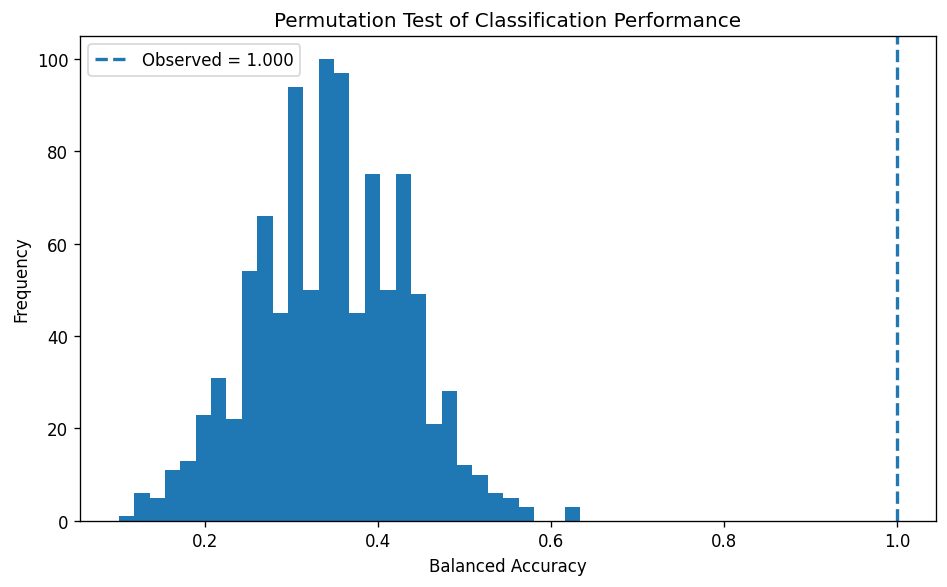


CELL 14 FINAL SUMMARY

Observed physiological model performance:
Balanced Accuracy = 1.0000
Permutation p-value = 0.000999

Leave-one-stage-out:
Balanced_Accuracy    1.0
Macro_F1             1.0
MCC                  1.0
dtype: float64

Leave-one-replication-out:
Balanced_Accuracy    1.0
Macro_F1             1.0
MCC                  1.0
dtype: float64

Saved:
kiwifruit_research_outputs/12_cell14_robustness_validation.xlsx
kiwifruit_research_outputs/12_cell14_permutation_scores.csv
kiwifruit_research_outputs/cell14_permutation_test.png

CELL 14 completed successfully.


In [24]:
# ============================================================
# CELL 14 — ROBUSTNESS, STRUCTURE ASSESSMENT & PERMUTATION TEST
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    LeaveOneGroupOut
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)
from sklearn.inspection import permutation_importance
from scipy.stats import kruskal
from itertools import combinations

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

OUTPUT_DIR = "kiwifruit_research_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

data_path = os.path.join(
    OUTPUT_DIR,
    "10_early_stress_ml_dataset.csv"
)

if "early_ml_df" in globals():
    df14 = early_ml_df.copy()
    print("Using early_ml_df already loaded in memory.")
else:
    df14 = pd.read_csv(data_path)
    print(f"Loaded: {data_path}")

print("\nDataset shape:", df14.shape)

# ------------------------------------------------------------
# 2. DEFINE VARIABLES
# ------------------------------------------------------------

TARGET = "stress_condition"

PHYSIO_FEATURES = [
    "Proline",
    "Leaf_Potassium"
]

EARLY_FEATURES = [
    "Proline",
    "Leaf_Potassium",
    "TCSA",
    "Trunk_Girth",
    "Initial_Bloom",
    "Final_Bloom",
    "Bloom_Intensity"
]

available_features = [
    f for f in EARLY_FEATURES
    if f in df14.columns
]

print("\nAvailable biological features:")
print(available_features)

X = df14[available_features].copy()
y = df14[TARGET].astype(str).copy()

print("\nTarget distribution:")
print(y.value_counts())

# ------------------------------------------------------------
# 3. BASIC DATA CHECK
# ------------------------------------------------------------

print("\nMissing values:")
print(X.isna().sum())

print("\nDuplicate rows:", df14.duplicated().sum())

# ------------------------------------------------------------
# 4. DEFINE ROBUST BASE MODEL
# ------------------------------------------------------------

def make_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                multi_class="multinomial",
                C=1.0,
                random_state=42
            )
        )
    ])

# ------------------------------------------------------------
# 5. FEATURE-SET ROBUSTNESS
# ------------------------------------------------------------

feature_sets = {
    "Proline_only": ["Proline"],
    "Leaf_K_only": ["Leaf_Potassium"],
    "Proline_Leaf_K": ["Proline", "Leaf_Potassium"],
    "All_early_features": available_features
}

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

feature_results = []

for set_name, features in feature_sets.items():

    features = [
        f for f in features
        if f in df14.columns
    ]

    X_set = df14[features]

    model = make_model()

    scores_acc = cross_val_score(
        model,
        X_set,
        y,
        cv=cv,
        scoring="accuracy"
    )

    scores_bacc = cross_val_score(
        model,
        X_set,
        y,
        cv=cv,
        scoring="balanced_accuracy"
    )

    scores_f1 = cross_val_score(
        model,
        X_set,
        y,
        cv=cv,
        scoring="f1_macro"
    )

    scores_mcc = []

    # MCC needs manual calculation
    for train_idx, test_idx in cv.split(X_set, y):

        model_fold = clone(model)

        model_fold.fit(
            X_set.iloc[train_idx],
            y.iloc[train_idx]
        )

        pred = model_fold.predict(
            X_set.iloc[test_idx]
        )

        scores_mcc.append(
            matthews_corrcoef(
                y.iloc[test_idx],
                pred
            )
        )

    feature_results.append({
        "Feature_Set": set_name,
        "N_Features": len(features),
        "Accuracy_Mean": scores_acc.mean(),
        "Accuracy_SD": scores_acc.std(),
        "Balanced_Accuracy_Mean": scores_bacc.mean(),
        "Balanced_Accuracy_SD": scores_bacc.std(),
        "Macro_F1_Mean": scores_f1.mean(),
        "Macro_F1_SD": scores_f1.std(),
        "MCC_Mean": np.mean(scores_mcc),
        "MCC_SD": np.std(scores_mcc)
    })

feature_results_df = pd.DataFrame(feature_results)

print("\n================================================")
print("FEATURE-SET ROBUSTNESS")
print("================================================")

display(
    feature_results_df.round(4)
)

# ------------------------------------------------------------
# 6. LEAVE-ONE-PHENOLOGICAL-STAGE-OUT VALIDATION
# ------------------------------------------------------------

print("\n================================================")
print("LEAVE-ONE-STAGE-OUT VALIDATION")
print("================================================")

stage_results = []

for stage in sorted(df14["phenological_stage"].unique()):

    train_mask = df14["phenological_stage"] != stage
    test_mask = df14["phenological_stage"] == stage

    X_train = df14.loc[train_mask, PHYSIO_FEATURES]
    y_train = y.loc[train_mask]

    X_test = df14.loc[test_mask, PHYSIO_FEATURES]
    y_test = y.loc[test_mask]

    model = make_model()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    stage_results.append({
        "Held_Out_Stage": stage,
        "N_Test": len(y_test),
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, pred),
        "Macro_F1": f1_score(
            y_test,
            pred,
            average="macro"
        ),
        "MCC": matthews_corrcoef(
            y_test,
            pred
        )
    })

stage_results_df = pd.DataFrame(stage_results)

display(
    stage_results_df.round(4)
)

# ------------------------------------------------------------
# 7. LEAVE-ONE-REPLICATION-OUT VALIDATION
# ------------------------------------------------------------

print("\n================================================")
print("LEAVE-ONE-REPLICATION-OUT VALIDATION")
print("================================================")

rep_results = []

for rep in sorted(df14["replication"].unique()):

    train_mask = df14["replication"] != rep
    test_mask = df14["replication"] == rep

    X_train = df14.loc[train_mask, PHYSIO_FEATURES]
    y_train = y.loc[train_mask]

    X_test = df14.loc[test_mask, PHYSIO_FEATURES]
    y_test = y.loc[test_mask]

    model = make_model()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rep_results.append({
        "Held_Out_Replication": rep,
        "N_Test": len(y_test),
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_test,
            pred
        ),
        "Macro_F1": f1_score(
            y_test,
            pred,
            average="macro"
        ),
        "MCC": matthews_corrcoef(
            y_test,
            pred
        )
    })

rep_results_df = pd.DataFrame(rep_results)

display(
    rep_results_df.round(4)
)

# ------------------------------------------------------------
# 8. CLASS SEPARATION — KRUSKAL-WALLIS
# ------------------------------------------------------------

print("\n================================================")
print("CLASS SEPARATION — KRUSKAL-WALLIS TEST")
print("================================================")

kw_results = []

classes = sorted(y.unique())

for feature in PHYSIO_FEATURES:

    groups = [
        df14.loc[
            df14[TARGET] == cls,
            feature
        ].values
        for cls in classes
    ]

    stat, p = kruskal(*groups)

    kw_results.append({
        "Feature": feature,
        "Kruskal_Wallis_H": stat,
        "P_Value": p
    })

kw_results_df = pd.DataFrame(kw_results)

display(
    kw_results_df.round(6)
)

# ------------------------------------------------------------
# 9. EFFECT SIZE — ETA SQUARED
# ------------------------------------------------------------

print("\n================================================")
print("EFFECT SIZE")
print("================================================")

effect_results = []

for feature in PHYSIO_FEATURES:

    values = df14[feature].values

    grand_mean = np.mean(values)

    ss_between = 0
    ss_total = np.sum(
        (values - grand_mean) ** 2
    )

    for cls in classes:

        group = df14.loc[
            df14[TARGET] == cls,
            feature
        ].values

        ss_between += (
            len(group)
            * (np.mean(group) - grand_mean) ** 2
        )

    eta_squared = (
        ss_between / ss_total
        if ss_total > 0
        else np.nan
    )

    effect_results.append({
        "Feature": feature,
        "Eta_Squared": eta_squared
    })

effect_results_df = pd.DataFrame(effect_results)

display(
    effect_results_df.round(4)
)

# ------------------------------------------------------------
# 10. SIMPLE FEATURE CORRELATION WITH STRESS SEVERITY
# ------------------------------------------------------------

print("\n================================================")
print("CORRELATION WITH EXPERIMENTAL STRESS SEVERITY")
print("================================================")

if "stress_severity" in df14.columns:

    corr_results = []

    for feature in PHYSIO_FEATURES:

        rho = df14[
            [feature, "stress_severity"]
        ].corr(
            method="spearman"
        ).iloc[0, 1]

        corr_results.append({
            "Feature": feature,
            "Spearman_Rho": rho
        })

    corr_results_df = pd.DataFrame(
        corr_results
    )

    display(
        corr_results_df.round(4)
    )

else:

    corr_results_df = pd.DataFrame()

# ------------------------------------------------------------
# 11. PERMUTATION LABEL TEST
# ------------------------------------------------------------

print("\n================================================")
print("PERMUTATION LABEL TEST")
print("================================================")

# Use Proline + Leaf K because this was the
# strongest physiological feature set.

X_perm = df14[PHYSIO_FEATURES]

# Standard 5-fold CV for computational stability
perm_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Observed score
observed_model = make_model()

observed_scores = cross_val_score(
    observed_model,
    X_perm,
    y,
    cv=perm_cv,
    scoring="balanced_accuracy"
)

observed_score = observed_scores.mean()

print(
    f"Observed 5-fold balanced accuracy: "
    f"{observed_score:.4f}"
)

# Number of permutations
N_PERMUTATIONS = 1000

rng = np.random.default_rng(42)

permutation_scores = []

for i in range(N_PERMUTATIONS):

    y_perm = pd.Series(
        rng.permutation(y.values),
        index=y.index
    )

    model_perm = make_model()

    scores = cross_val_score(
        model_perm,
        X_perm,
        y_perm,
        cv=perm_cv,
        scoring="balanced_accuracy"
    )

    permutation_scores.append(
        scores.mean()
    )

permutation_scores = np.array(
    permutation_scores
)

# Empirical p-value
p_perm = (
    np.sum(
        permutation_scores >= observed_score
    ) + 1
) / (
    N_PERMUTATIONS + 1
)

print(
    f"Permutation p-value: {p_perm:.6f}"
)

print(
    f"Permutation mean: "
    f"{permutation_scores.mean():.4f}"
)

print(
    f"Permutation SD: "
    f"{permutation_scores.std():.4f}"
)

# ------------------------------------------------------------
# 12. PERMUTATION DISTRIBUTION PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    permutation_scores,
    bins=30
)

plt.axvline(
    observed_score,
    linewidth=2,
    linestyle="--",
    label=f"Observed = {observed_score:.3f}"
)

plt.xlabel(
    "Balanced Accuracy"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Permutation Test of Classification Performance"
)

plt.legend()

plt.tight_layout()

perm_fig = os.path.join(
    OUTPUT_DIR,
    "cell14_permutation_test.png"
)

plt.savefig(
    perm_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 13. FINAL ROBUSTNESS SUMMARY
# ------------------------------------------------------------

print("\n================================================")
print("CELL 14 FINAL SUMMARY")
print("================================================")

print(
    "\nObserved physiological model performance:"
)

print(
    f"Balanced Accuracy = "
    f"{observed_score:.4f}"
)

print(
    f"Permutation p-value = "
    f"{p_perm:.6f}"
)

print(
    "\nLeave-one-stage-out:"
)

print(
    stage_results_df[
        ["Balanced_Accuracy", "Macro_F1", "MCC"]
    ].mean().round(4)
)

print(
    "\nLeave-one-replication-out:"
)

print(
    rep_results_df[
        ["Balanced_Accuracy", "Macro_F1", "MCC"]
    ].mean().round(4)
)

# ------------------------------------------------------------
# 14. SAVE RESULTS
# ------------------------------------------------------------

cell14_xlsx = os.path.join(
    OUTPUT_DIR,
    "12_cell14_robustness_validation.xlsx"
)

with pd.ExcelWriter(
    cell14_xlsx,
    engine="openpyxl"
) as writer:

    feature_results_df.to_excel(
        writer,
        sheet_name="Feature_Robustness",
        index=False
    )

    stage_results_df.to_excel(
        writer,
        sheet_name="Leave_One_Stage_Out",
        index=False
    )

    rep_results_df.to_excel(
        writer,
        sheet_name="Leave_One_Replication_Out",
        index=False
    )

    kw_results_df.to_excel(
        writer,
        sheet_name="Kruskal_Wallis",
        index=False
    )

    effect_results_df.to_excel(
        writer,
        sheet_name="Effect_Size",
        index=False
    )

    if not corr_results_df.empty:
        corr_results_df.to_excel(
            writer,
            sheet_name="Stress_Correlation",
            index=False
        )

    pd.DataFrame({
        "Observed_Balanced_Accuracy":
            [observed_score],
        "Permutation_Mean":
            [permutation_scores.mean()],
        "Permutation_SD":
            [permutation_scores.std()],
        "Permutation_P_Value":
            [p_perm],
        "N_Permutations":
            [N_PERMUTATIONS]
    }).to_excel(
        writer,
        sheet_name="Permutation_Test",
        index=False
    )

permutation_df = pd.DataFrame({
    "Permutation_Balanced_Accuracy":
        permutation_scores
})

permutation_csv = os.path.join(
    OUTPUT_DIR,
    "12_cell14_permutation_scores.csv"
)

permutation_df.to_csv(
    permutation_csv,
    index=False
)

print("\nSaved:")
print(cell14_xlsx)
print(permutation_csv)
print(perm_fig)

print("\nCELL 14 completed successfully.")

Using early_ml_df already loaded in memory.

Dataset shape: (36, 13)

Features:
['Proline', 'Leaf_Potassium']

Target classes:
['Low_Stress', 'Moderate_Stress', 'High_Stress']

Target distribution:
stress_condition
Low_Stress         12
Moderate_Stress    12
High_Stress        12
Name: count, dtype: int64

Final explanatory model fitted.

Apparent training balanced accuracy: 1.0000

NOTE:
SHAP explanations describe the fitted model. They should not be interpreted as independent causal biological effects.

SHAP explanation generated.
SHAP object shape: (36, 2, 3)

SHAP dimensions:
Samples: 36
Features: 2
Classes: 3

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP,Median_Absolute_SHAP
0,Proline,1.052046,0.491055
1,Leaf_Potassium,0.943999,0.579339



CLASS-SPECIFIC SHAP IMPORTANCE


,Stress_Class,Feature,Mean_Absolute_SHAP
0,Low_Stress,Proline,1.578069
1,Low_Stress,Leaf_Potassium,1.076990
2,Moderate_Stress,Proline,1.325181
3,Moderate_Stress,Leaf_Potassium,1.415999
4,High_Stress,Proline,0.252887
5,High_Stress,Leaf_Potassium,0.339008


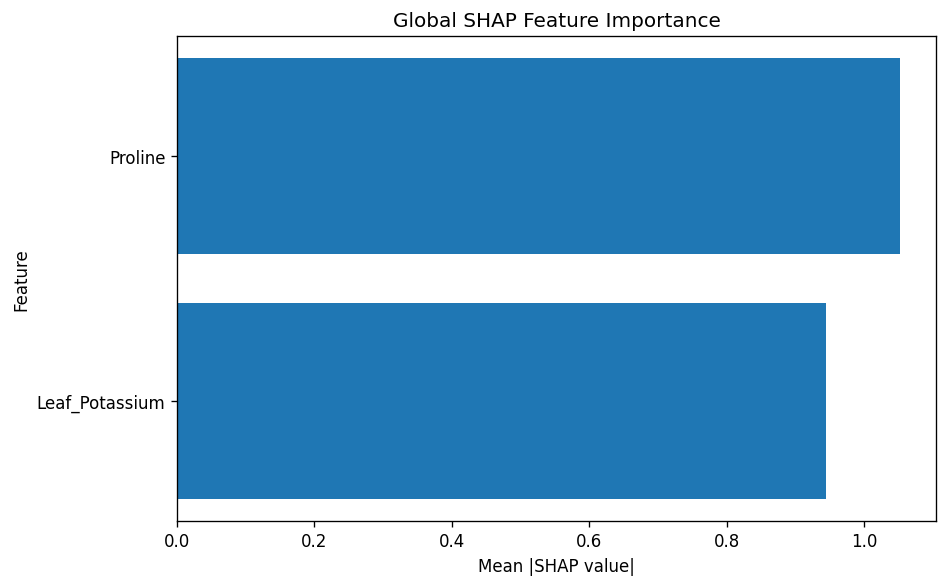

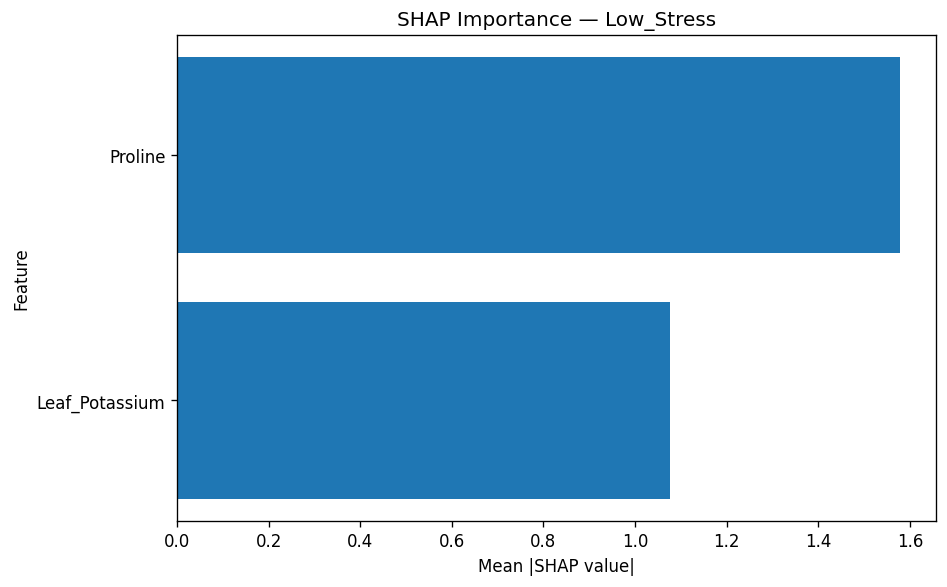

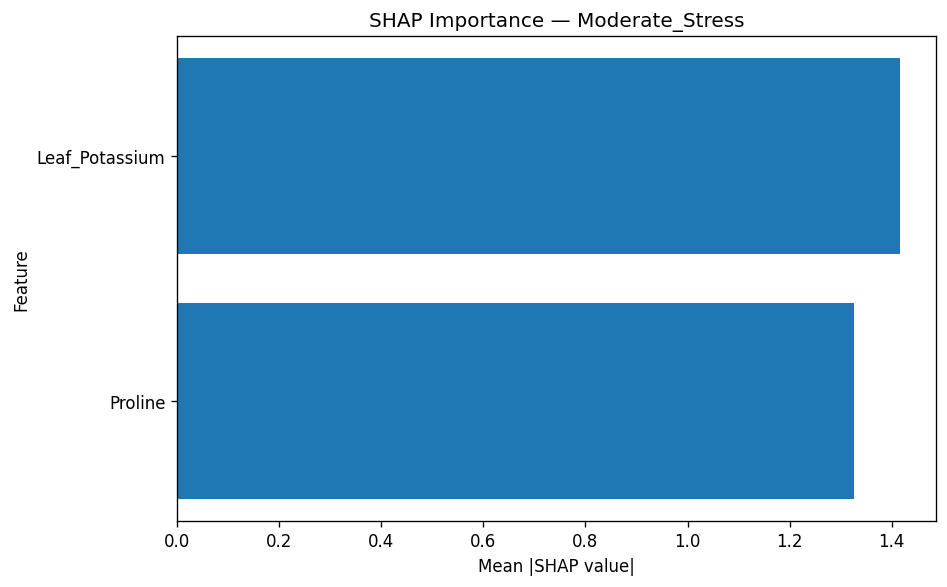

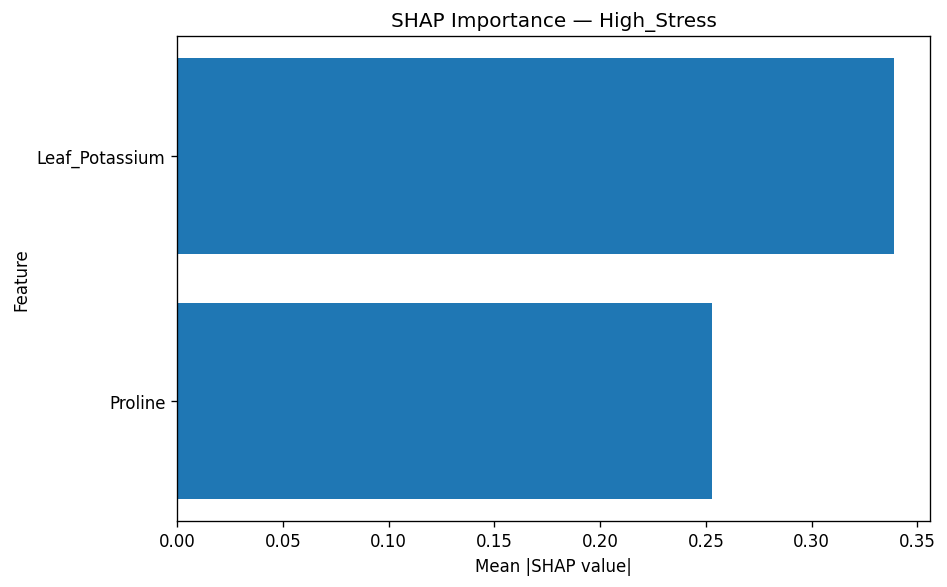

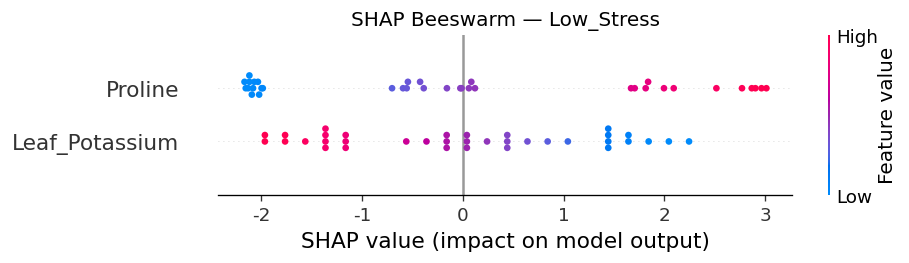

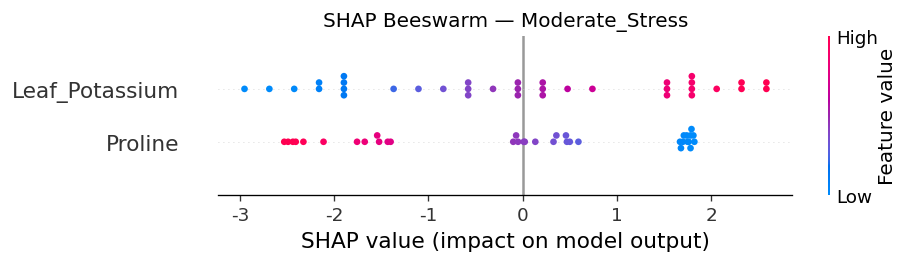

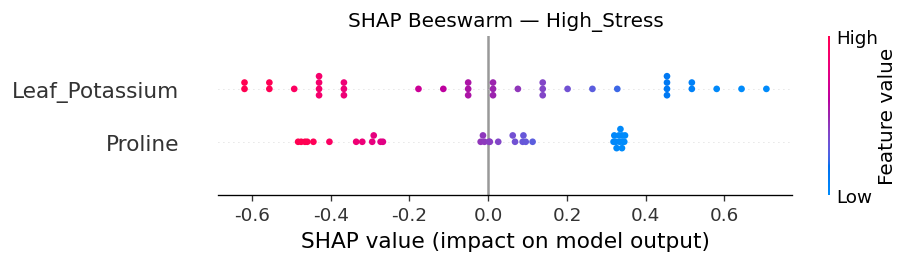


SHAP long-format dataset:
(216, 6)


,Sample_Index,Stress_Class,Feature,Feature_Value,Standardized_Value,SHAP_Value
0,0,Low_Stress,Proline,1.69,-1.165760,-2.156053
1,0,Low_Stress,Leaf_Potassium,2.45,1.395366,-1.765386
2,0,Moderate_Stress,Proline,1.69,-1.165760,1.810543
3,0,Moderate_Stress,Leaf_Potassium,2.45,1.395366,2.321083
4,0,High_Stress,Proline,1.69,-1.165760,0.345510
5,0,High_Stress,Leaf_Potassium,2.45,1.395366,-0.555697
6,1,Low_Stress,Proline,1.74,-1.133039,-2.095537
7,1,Low_Stress,Leaf_Potassium,2.43,1.078437,-1.364415
8,1,Moderate_Stress,Proline,1.74,-1.133039,1.759725
9,1,Moderate_Stress,Leaf_Potassium,2.43,1.078437,1.793897



REPRESENTATIVE INDIVIDUAL SHAP EXPLANATIONS


,Sample_Index,Actual_Class,Predicted_Class,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,6,Low_Stress,Low_Stress,Proline,1.80,1.698743,1.698743
1,6,Low_Stress,Low_Stress,Leaf_Potassium,2.42,1.530304,1.530304
2,18,Moderate_Stress,Moderate_Stress,Proline,3.45,0.004148,0.004148
3,18,Moderate_Stress,Moderate_Stress,Leaf_Potassium,2.36,0.012271,0.012271
4,30,High_Stress,High_Stress,Proline,5.55,2.515787,2.515787
5,30,High_Stress,High_Stress,Leaf_Potassium,2.26,2.043838,2.043838



SHAP DIRECTION SUMMARY


,Stress_Class,Feature,Mean_SHAP,Mean_Absolute_SHAP,Positive_SHAP_Count,Negative_SHAP_Count
0,Low_Stress,Proline,0.0,1.578069,15,21
1,Low_Stress,Leaf_Potassium,0.0,1.076990,19,17
2,Moderate_Stress,Proline,-0.0,1.325181,21,15
3,Moderate_Stress,Leaf_Potassium,0.0,1.415999,17,19
4,High_Stress,Proline,0.0,0.252887,21,15
5,High_Stress,Leaf_Potassium,0.0,0.339008,19,17


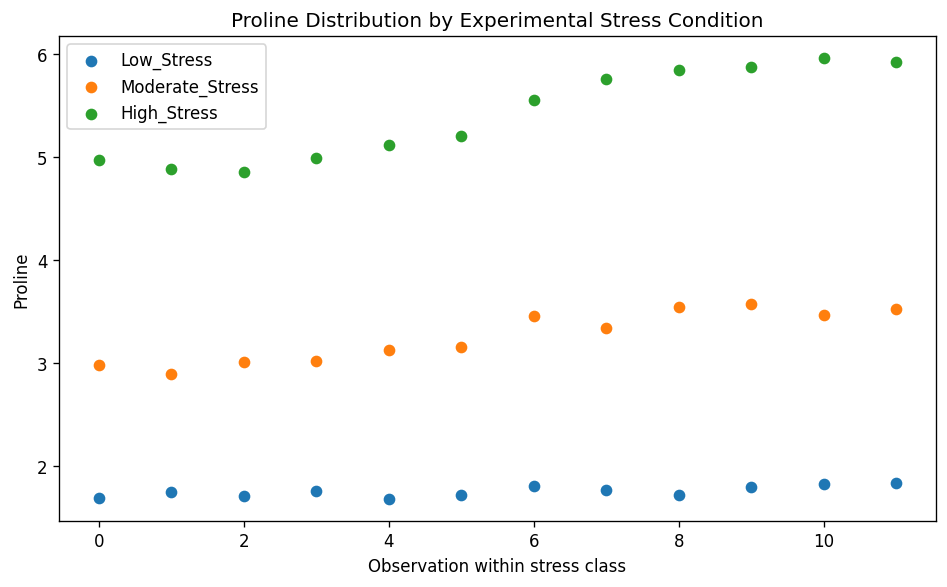

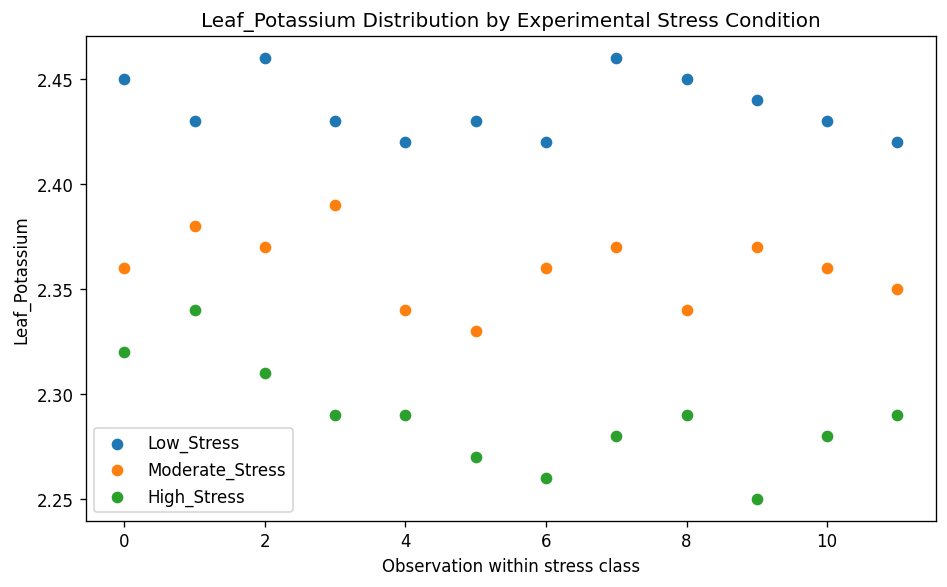



CELL 15 COMPLETED — SHAP / XAI

Global feature ranking:


,Feature,Mean_Absolute_SHAP,Median_Absolute_SHAP
0,Proline,1.052046,0.491055
1,Leaf_Potassium,0.943999,0.579339



Class-specific SHAP importance:


,Stress_Class,Feature,Mean_Absolute_SHAP
0,Low_Stress,Proline,1.578069
1,Low_Stress,Leaf_Potassium,1.076990
2,Moderate_Stress,Proline,1.325181
3,Moderate_Stress,Leaf_Potassium,1.415999
4,High_Stress,Proline,0.252887
5,High_Stress,Leaf_Potassium,0.339008



Files saved:
kiwifruit_research_outputs/13_cell15_shap_xai_analysis.xlsx
kiwifruit_research_outputs/13_cell15_global_shap_importance.csv
kiwifruit_research_outputs/13_cell15_class_shap_importance.csv
kiwifruit_research_outputs/13_cell15_individual_shap_values.csv
kiwifruit_research_outputs/cell15_shap_figures

CELL 15 completed successfully.


In [25]:
# ============================================================
# CELL 15 — SHAP / EXPLAINABLE AI ANALYSIS
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

OUTPUT_DIR = "kiwifruit_research_outputs"
SHAP_DIR = os.path.join(
    OUTPUT_DIR,
    "cell15_shap_figures"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

DATA_PATH = os.path.join(
    OUTPUT_DIR,
    "10_early_stress_ml_dataset.csv"
)

# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------

if "early_ml_df" in globals():

    df15 = early_ml_df.copy()

    print(
        "Using early_ml_df already loaded in memory."
    )

else:

    df15 = pd.read_csv(DATA_PATH)

    print(
        f"Loaded: {DATA_PATH}"
    )

print(
    "\nDataset shape:",
    df15.shape
)

# ------------------------------------------------------------
# 3. DEFINE TARGET AND FEATURES
# ------------------------------------------------------------

TARGET = "stress_condition"

PHYSIO_FEATURES = [
    "Proline",
    "Leaf_Potassium"
]

X = df15[PHYSIO_FEATURES].copy()

y = df15[TARGET].astype(str).copy()

class_order = [
    "Low_Stress",
    "Moderate_Stress",
    "High_Stress"
]

# Make sure class ordering is consistent
class_order = [
    c for c in class_order
    if c in y.unique()
]

print(
    "\nFeatures:"
)

print(
    PHYSIO_FEATURES
)

print(
    "\nTarget classes:"
)

print(
    class_order
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts()
)

# ------------------------------------------------------------
# 4. FIT FINAL EXPLANATORY MODEL
# ------------------------------------------------------------

final_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            multi_class="multinomial",
            C=1.0,
            random_state=42
        )
    )
])

final_model.fit(
    X,
    y
)

print(
    "\nFinal explanatory model fitted."
)

# ------------------------------------------------------------
# 5. VERIFY TRAINING PERFORMANCE
# ------------------------------------------------------------

train_pred = final_model.predict(X)

train_bacc = balanced_accuracy_score(
    y,
    train_pred
)

print(
    f"\nApparent training balanced accuracy: "
    f"{train_bacc:.4f}"
)

print(
    "\nNOTE:"
)

print(
    "SHAP explanations describe the fitted model. "
    "They should not be interpreted as independent "
    "causal biological effects."
)

# ------------------------------------------------------------
# 6. EXTRACT STANDARDIZED FEATURE MATRIX
# ------------------------------------------------------------

scaler = final_model.named_steps["scaler"]
classifier = final_model.named_steps["model"]

X_scaled = scaler.transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=PHYSIO_FEATURES,
    index=X.index
)

# ------------------------------------------------------------
# 7. SHAP EXPLAINER
# ------------------------------------------------------------

explainer = shap.LinearExplainer(
    classifier,
    X_scaled_df
)

shap_values = explainer(
    X_scaled_df
)

print(
    "\nSHAP explanation generated."
)

print(
    "SHAP object shape:",
    shap_values.values.shape
)

# ------------------------------------------------------------
# 8. HANDLE MULTICLASS SHAP STRUCTURE
# ------------------------------------------------------------

# SHAP versions can return either:
# (samples, features, classes)
# or
# (samples, features)

values = shap_values.values

if values.ndim == 3:

    # samples × features × classes

    shap_array = values

elif values.ndim == 2:

    # Binary / single-output fallback

    shap_array = values[:, :, np.newaxis]

else:

    raise ValueError(
        f"Unexpected SHAP shape: {values.shape}"
    )

n_samples, n_features, n_classes = (
    shap_array.shape
)

print(
    "\nSHAP dimensions:"
)

print(
    "Samples:",
    n_samples
)

print(
    "Features:",
    n_features
)

print(
    "Classes:",
    n_classes
)

# ------------------------------------------------------------
# 9. GLOBAL SHAP IMPORTANCE
# ------------------------------------------------------------

global_rows = []

for feature_idx, feature in enumerate(
    PHYSIO_FEATURES
):

    all_class_values = np.abs(
        shap_array[
            :,
            feature_idx,
            :
        ]
    )

    global_mean = np.mean(
        all_class_values
    )

    global_median = np.median(
        all_class_values
    )

    global_rows.append({
        "Feature": feature,
        "Mean_Absolute_SHAP":
            global_mean,
        "Median_Absolute_SHAP":
            global_median
    })

global_shap_df = pd.DataFrame(
    global_rows
)

global_shap_df = (
    global_shap_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\n================================================"
)

print(
    "GLOBAL SHAP FEATURE IMPORTANCE"
)

print(
    "================================================"
)

display(
    global_shap_df.round(6)
)

# ------------------------------------------------------------
# 10. CLASS-SPECIFIC SHAP IMPORTANCE
# ------------------------------------------------------------

class_importance_rows = []

for class_idx, class_name in enumerate(
    class_order
):

    if class_idx >= n_classes:
        continue

    class_values = np.abs(
        shap_array[
            :,
            :,
            class_idx
        ]
    )

    mean_abs = class_values.mean(
        axis=0
    )

    for feature_idx, feature in enumerate(
        PHYSIO_FEATURES
    ):

        class_importance_rows.append({
            "Stress_Class": class_name,
            "Feature": feature,
            "Mean_Absolute_SHAP":
                mean_abs[feature_idx]
        })

class_shap_df = pd.DataFrame(
    class_importance_rows
)

print(
    "\n================================================"
)

print(
    "CLASS-SPECIFIC SHAP IMPORTANCE"
)

print(
    "================================================"
)

display(
    class_shap_df.round(6)
)

# ------------------------------------------------------------
# 11. GLOBAL BAR PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plot_df = global_shap_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

plt.barh(
    plot_df["Feature"],
    plot_df["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

global_fig = os.path.join(
    SHAP_DIR,
    "cell15_global_shap_importance.png"
)

plt.savefig(
    global_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 12. CLASS-SPECIFIC BAR PLOTS
# ------------------------------------------------------------

for class_name in class_order:

    temp = class_shap_df[
        class_shap_df["Stress_Class"]
        == class_name
    ].copy()

    temp = temp.sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        temp["Feature"],
        temp["Mean_Absolute_SHAP"]
    )

    plt.xlabel(
        "Mean |SHAP value|"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"SHAP Importance — {class_name}"
    )

    plt.tight_layout()

    safe_name = (
        class_name
        .replace(" ", "_")
    )

    fig_path = os.path.join(
        SHAP_DIR,
        f"cell15_shap_{safe_name}.png"
    )

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ------------------------------------------------------------
# 13. SHAP BEESWARM
# ------------------------------------------------------------

# For multiclass models, generate one beeswarm
# per stress class.

for class_idx, class_name in enumerate(
    class_order
):

    if class_idx >= n_classes:
        continue

    class_explanation = shap.Explanation(
        values=shap_array[
            :,
            :,
            class_idx
        ],
        base_values=np.repeat(
            shap_values.base_values[:, class_idx]
            if np.asarray(
                shap_values.base_values
            ).ndim > 1
            else shap_values.base_values,
            1
        ),
        data=X_scaled_df.values,
        feature_names=PHYSIO_FEATURES
    )

    plt.figure()

    shap.plots.beeswarm(
        class_explanation,
        max_display=len(PHYSIO_FEATURES),
        show=False
    )

    plt.title(
        f"SHAP Beeswarm — {class_name}"
    )

    plt.tight_layout()

    safe_name = (
        class_name
        .replace(" ", "_")
    )

    fig_path = os.path.join(
        SHAP_DIR,
        f"cell15_beeswarm_{safe_name}.png"
    )

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

# ------------------------------------------------------------
# 14. SHAP VALUES DATAFRAME
# ------------------------------------------------------------

shap_long_rows = []

for sample_idx in range(
    n_samples
):

    for class_idx, class_name in enumerate(
        class_order
    ):

        if class_idx >= n_classes:
            continue

        for feature_idx, feature in enumerate(
            PHYSIO_FEATURES
        ):

            shap_long_rows.append({

                "Sample_Index":
                    sample_idx,

                "Stress_Class":
                    class_name,

                "Feature":
                    feature,

                "Feature_Value":
                    X.iloc[
                        sample_idx,
                        feature_idx
                    ],

                "Standardized_Value":
                    X_scaled[
                        sample_idx,
                        feature_idx
                    ],

                "SHAP_Value":
                    shap_array[
                        sample_idx,
                        feature_idx,
                        class_idx
                    ]
            })

shap_long_df = pd.DataFrame(
    shap_long_rows
)

print(
    "\nSHAP long-format dataset:"
)

print(
    shap_long_df.shape
)

display(
    shap_long_df.head(10)
)

# ------------------------------------------------------------
# 15. INDIVIDUAL SAMPLE EXPLANATIONS
# ------------------------------------------------------------

# Select one representative observation
# from each experimentally imposed stress class.

representative_indices = []

for class_name in class_order:

    class_indices = df15.index[
        df15[TARGET] == class_name
    ].tolist()

    if len(class_indices) > 0:

        representative_indices.append(
            class_indices[
                len(class_indices) // 2
            ]
        )

individual_rows = []

for idx in representative_indices:

    pred_class = final_model.predict(
        X.loc[[idx]]
    )[0]

    probabilities = final_model.predict_proba(
        X.loc[[idx]]
    )[0]

    predicted_class_index = list(
        classifier.classes_
    ).index(pred_class)

    for feature_idx, feature in enumerate(
        PHYSIO_FEATURES
    ):

        shap_value = shap_array[
            idx,
            feature_idx,
            predicted_class_index
        ]

        individual_rows.append({

            "Sample_Index":
                idx,

            "Actual_Class":
                y.loc[idx],

            "Predicted_Class":
                pred_class,

            "Feature":
                feature,

            "Feature_Value":
                X.loc[idx, feature],

            "SHAP_Value":
                shap_value,

            "Absolute_SHAP":
                abs(shap_value)

        })

individual_shap_df = pd.DataFrame(
    individual_rows
)

print(
    "\n================================================"
)

print(
    "REPRESENTATIVE INDIVIDUAL SHAP EXPLANATIONS"
)

print(
    "================================================"
)

display(
    individual_shap_df.round(6)
)

# ------------------------------------------------------------
# 16. SHAP DIRECTION SUMMARY
# ------------------------------------------------------------

direction_rows = []

for class_idx, class_name in enumerate(
    class_order
):

    if class_idx >= n_classes:
        continue

    for feature_idx, feature in enumerate(
        PHYSIO_FEATURES
    ):

        vals = shap_array[
            :,
            feature_idx,
            class_idx
        ]

        direction_rows.append({

            "Stress_Class":
                class_name,

            "Feature":
                feature,

            "Mean_SHAP":
                np.mean(vals),

            "Mean_Absolute_SHAP":
                np.mean(np.abs(vals)),

            "Positive_SHAP_Count":
                np.sum(vals > 0),

            "Negative_SHAP_Count":
                np.sum(vals < 0)

        })

shap_direction_df = pd.DataFrame(
    direction_rows
)

print(
    "\n================================================"
)

print(
    "SHAP DIRECTION SUMMARY"
)

print(
    "================================================"
)

display(
    shap_direction_df.round(6)
)

# ------------------------------------------------------------
# 17. FEATURE VALUE DISTRIBUTION BY STRESS CLASS
# ------------------------------------------------------------

for feature in PHYSIO_FEATURES:

    plt.figure(figsize=(8, 5))

    for class_name in class_order:

        values_class = df15.loc[
            df15[TARGET] == class_name,
            feature
        ]

        plt.scatter(
            np.arange(len(values_class)),
            values_class,
            label=class_name
        )

    plt.xlabel(
        "Observation within stress class"
    )

    plt.ylabel(
        feature
    )

    plt.title(
        f"{feature} Distribution by Experimental Stress Condition"
    )

    plt.legend()

    plt.tight_layout()

    safe_name = (
        feature
        .replace(" ", "_")
    )

    fig_path = os.path.join(
        SHAP_DIR,
        f"cell15_distribution_{safe_name}.png"
    )

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ------------------------------------------------------------
# 18. SAVE ALL SHAP RESULTS
# ------------------------------------------------------------

xlsx_path = os.path.join(
    OUTPUT_DIR,
    "13_cell15_shap_xai_analysis.xlsx"
)

with pd.ExcelWriter(
    xlsx_path,
    engine="openpyxl"
) as writer:

    global_shap_df.to_excel(
        writer,
        sheet_name="Global_SHAP",
        index=False
    )

    class_shap_df.to_excel(
        writer,
        sheet_name="Class_SHAP",
        index=False
    )

    shap_direction_df.to_excel(
        writer,
        sheet_name="SHAP_Direction",
        index=False
    )

    individual_shap_df.to_excel(
        writer,
        sheet_name="Individual_SHAP",
        index=False
    )

    shap_long_df.to_excel(
        writer,
        sheet_name="SHAP_Long",
        index=False
    )

    pd.DataFrame({
        "Metric": [
            "Training Balanced Accuracy",
            "Number of Samples",
            "Number of Features",
            "Number of Classes"
        ],
        "Value": [
            train_bacc,
            n_samples,
            n_features,
            n_classes
        ]
    }).to_excel(
        writer,
        sheet_name="Model_Info",
        index=False
    )

# ------------------------------------------------------------
# 19. SAVE CSV FILES
# ------------------------------------------------------------

global_csv = os.path.join(
    OUTPUT_DIR,
    "13_cell15_global_shap_importance.csv"
)

class_csv = os.path.join(
    OUTPUT_DIR,
    "13_cell15_class_shap_importance.csv"
)

individual_csv = os.path.join(
    OUTPUT_DIR,
    "13_cell15_individual_shap_values.csv"
)

global_shap_df.to_csv(
    global_csv,
    index=False
)

class_shap_df.to_csv(
    class_csv,
    index=False
)

individual_shap_df.to_csv(
    individual_csv,
    index=False
)

# ------------------------------------------------------------
# 20. FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("CELL 15 COMPLETED — SHAP / XAI")
print("=" * 65)

print(
    "\nGlobal feature ranking:"
)

display(
    global_shap_df.round(6)
)

print(
    "\nClass-specific SHAP importance:"
)

display(
    class_shap_df.round(6)
)

print(
    "\nFiles saved:"
)

print(
    xlsx_path
)

print(
    global_csv
)

print(
    class_csv
)

print(
    individual_csv
)

print(
    SHAP_DIR
)

print(
    "\nCELL 15 completed successfully."
)